In [7]:
import matplotlib.pyplot as plt
from db_utils import load_config, create_psycopg2_connection
import os
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MaxNLocator
def get_unique_material_orientation_pairs(config_path: str, table_name: str):
    config = load_config(config_path)
    unique_pairs = []
    conn, cur = None, None
    try:
        conn, cur = create_psycopg2_connection(config)
        cur.execute(f'SELECT DISTINCT "Material", "Orientation", "Temperature" FROM {table_name}')
        unique_pairs = cur.fetchall()
    except Exception as e:
        print(f"Ошибка при выполнении SQL-запроса: {e}")
    finally:
        if cur:
            cur.close()
        if conn:
            conn.close()
    return unique_pairs

def get_x_y_values(config_path: str, table_name: str, material: str, orientation: str, temperature: str):
    config = load_config(config_path)
    x_values, y_values = [], []
    conn, cur = None, None
    try:
        conn, cur = create_psycopg2_connection(config)
        cur.execute(
            f'SELECT "Time lapse", "Deformation" FROM {table_name} WHERE "Material" = %s AND "Orientation" = %s AND "Temperature" = %s',
            (material, orientation, temperature)
        )
        rows = cur.fetchall()
        x_values = [row[0] for row in rows]
        y_values = [row[1] for row in rows]
    except Exception as e:
        print(f"Ошибка при выполнении SQL-запроса: {e}")
    finally:
        if cur:
            cur.close()
        if conn:
            conn.close()
    return x_values, y_values
def plot_x_y_values(x_values, y_values, material, orientation, temperature):
    plt.figure(figsize=(22, 30))
    
    # Фильтрация данных
    x_clean = [x for x in x_values if x is not None]
    y_clean = [y for y in y_values if y is not None]
    
    # Проверка на пустые данные
    if not x_clean or not y_clean:
        raise ValueError("Некорректные данные: отсутствуют значения x или y")
    
    plt.plot(x_clean, y_clean, 
             label=f'{material}, {orientation}, {temperature}', 
             linewidth=8, 
             marker='o',
             markersize=15)
             # markerfacecolor='black',
             # markeredgecolor='black',    # Цвет границы маркера
             # markeredgewidth=2)
    
    # Расчет отступов для осей
    x_min = min(x_clean)
    x_max = max(x_clean)
    y_min = min(y_clean)
    y_max = max(y_clean)
    
    # Отступы (10% от диапазона данных)
    x_padding = 0.1 * (x_max - x_min)
    y_padding = 0.1 * (y_max - y_min)
    
    # Установка пределов с отступами
    plt.xlim(x_min - x_padding, x_max + x_padding)
    plt.ylim(y_min - y_padding, y_max + y_padding)
    
    # Динамический расчет шага делений
    ax = plt.gca()
    
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Максимум 15 делений по X и 10 по Y
    x_step = max(1, round(x_range / 15))
    y_step = max(0.5, round(y_range / 10, 1))
    
    ax.xaxis.set_major_locator(plt.MultipleLocator(x_step))
    ax.yaxis.set_major_locator(plt.MultipleLocator(y_step))
    
    # Остальные настройки
    plt.xlabel('Time_lapse, hour', fontsize=30, fontweight='bold', labelpad=25)
    plt.ylabel('Deformation, %', fontsize=30, fontweight='bold', labelpad=25)
    plt.grid(True, which='major', linestyle=':')
    ax.tick_params(axis='both', labelsize=30)
    
    plt.title(f'Материал: {material}\nНаправление: {orientation}\nТемпература: {temperature}', 
             fontsize=30, pad=25, loc='left')
    
    #plt.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close()
    
def all_experiments_main():
    config_path = 'config_to_connection.json'
    table_name = 'experiment_full_table'

    unique_pairs = get_unique_material_orientation_pairs(config_path, table_name)
    #print("Уникальные пары (Material, Orientation):", unique_pairs)

    for material, orientation, temperature in unique_pairs:
        x_values, y_values = get_x_y_values(config_path, table_name, material, orientation, temperature)
        
        x_values_for_graphs = []
        y_values_for_graphs = []
        
        for i in range(len(x_values)):
            if y_values[i] < 1.2:
                x_values_for_graphs.append(x_values[i])
                y_values_for_graphs.append(y_values[i])
               
        plot_x_y_values(x_values_for_graphs, y_values_for_graphs, material, orientation, temperature)

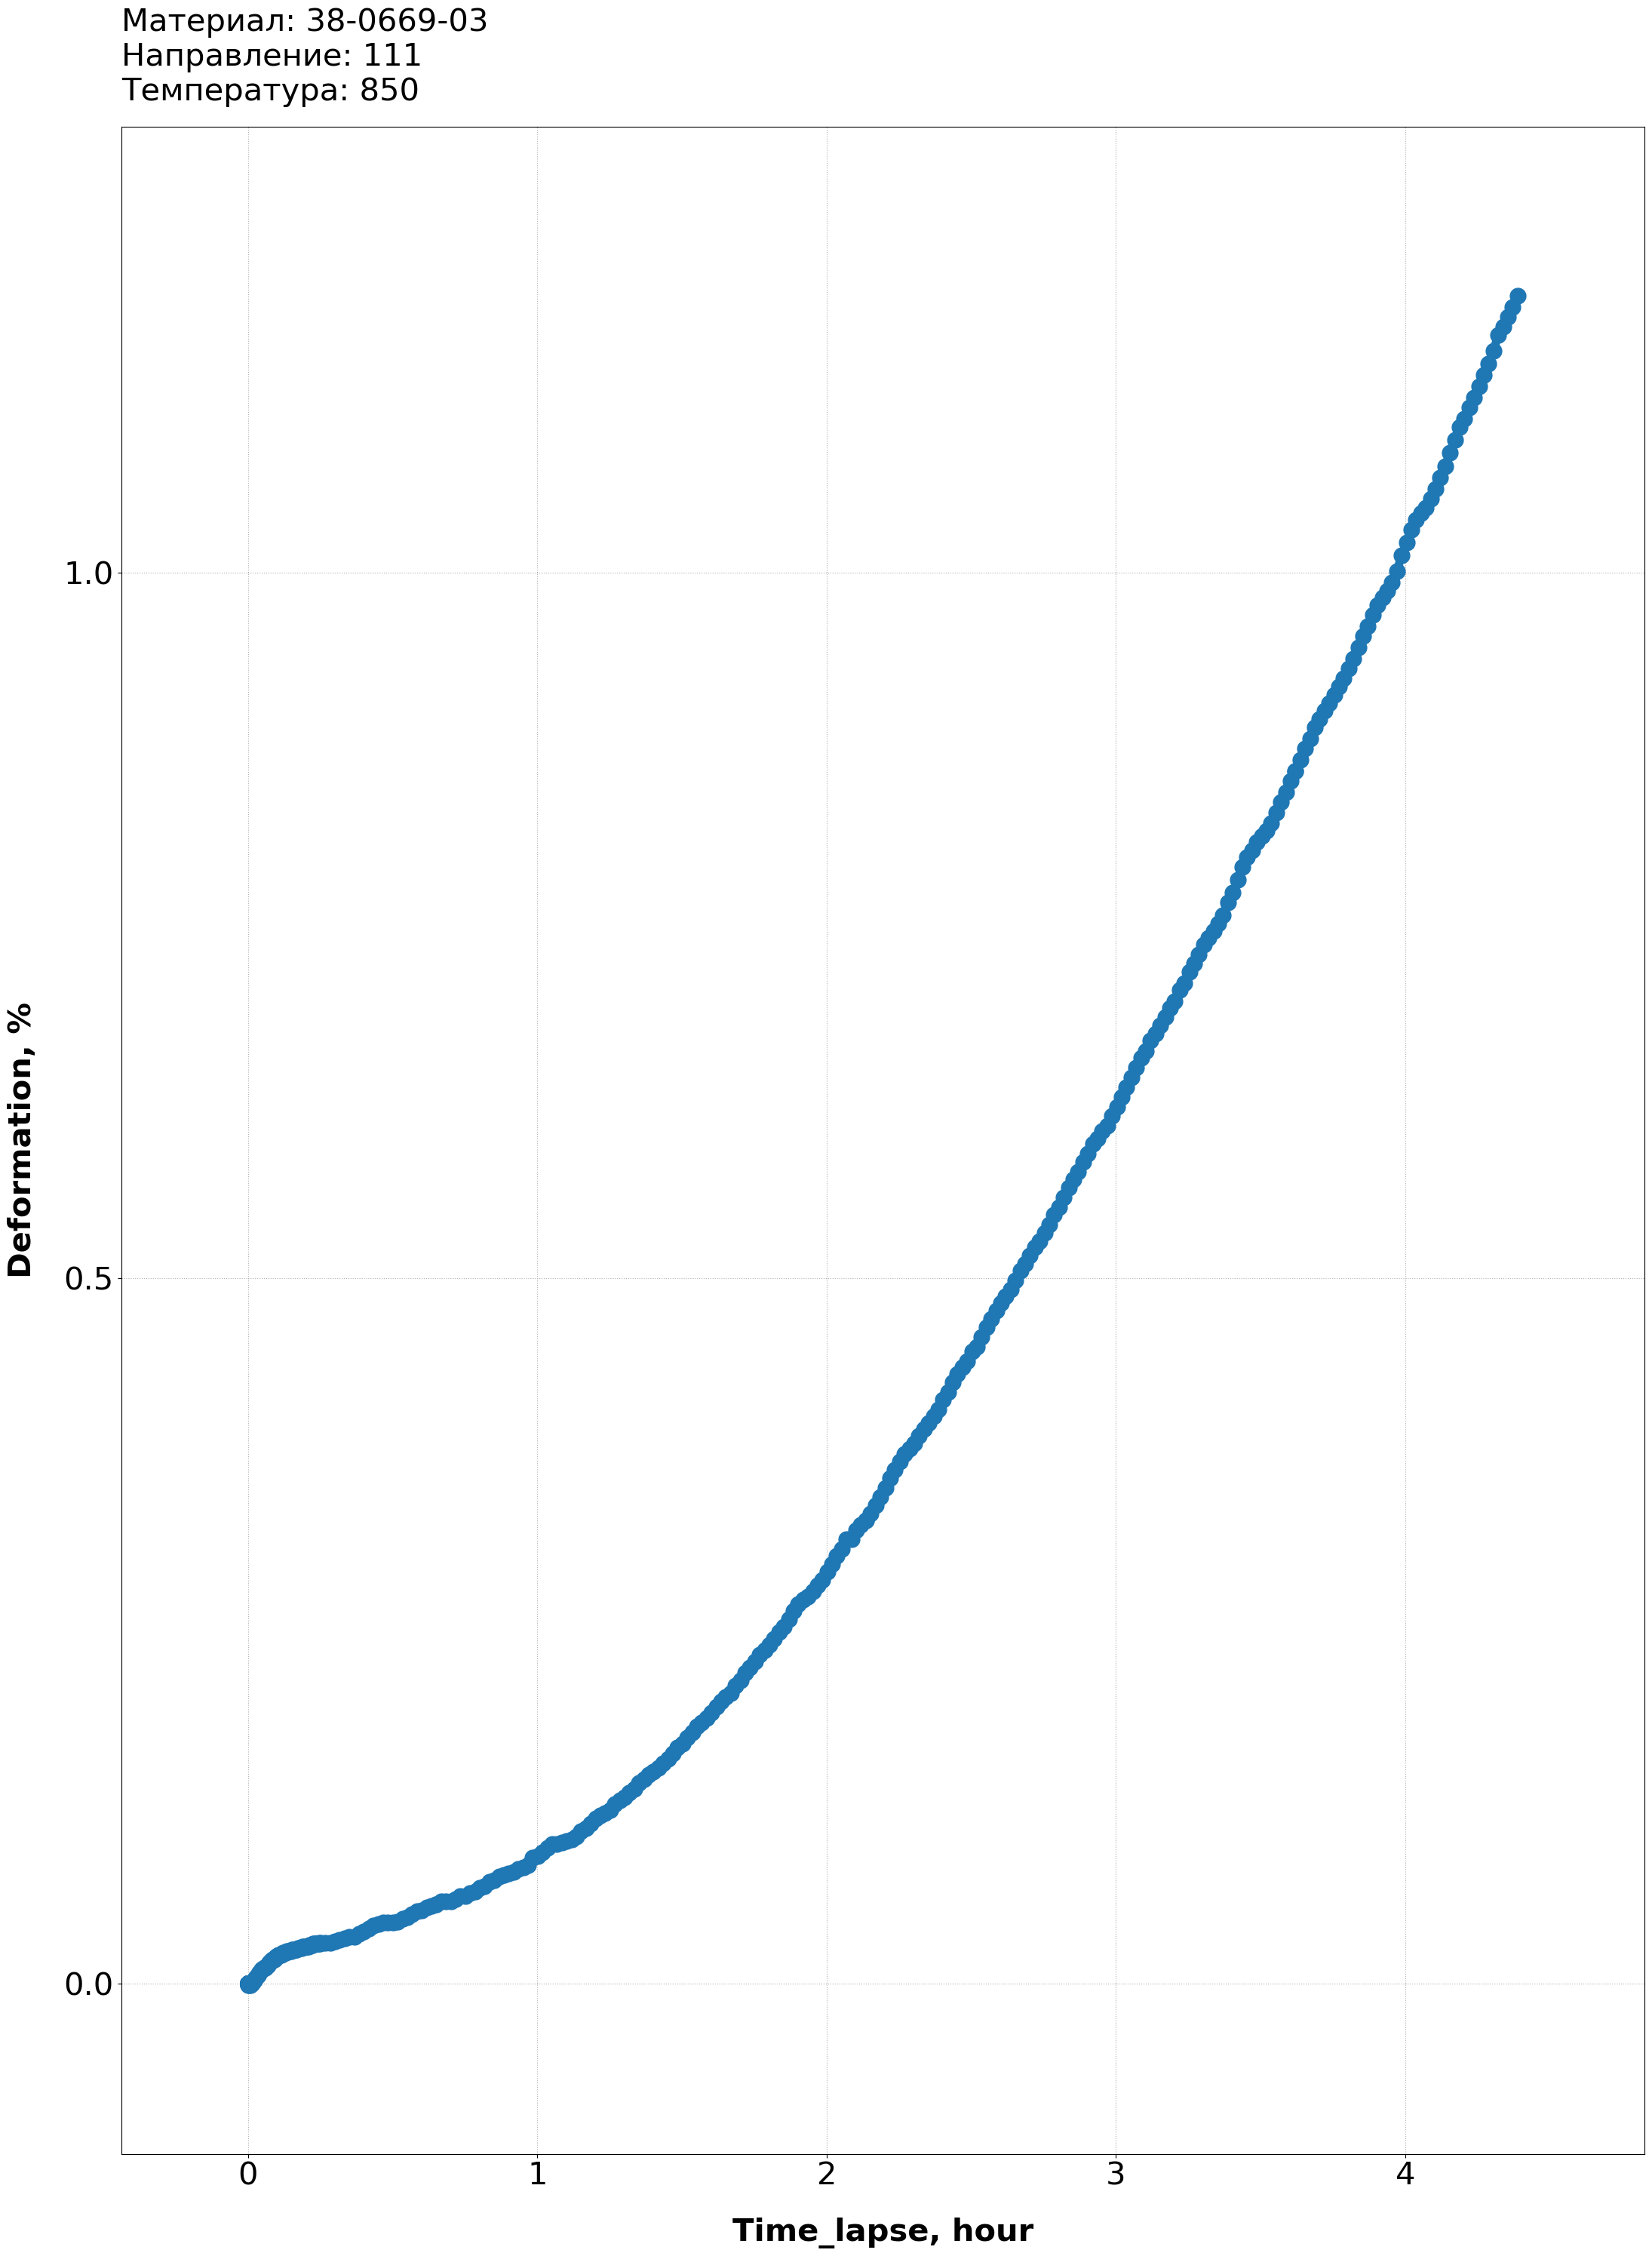

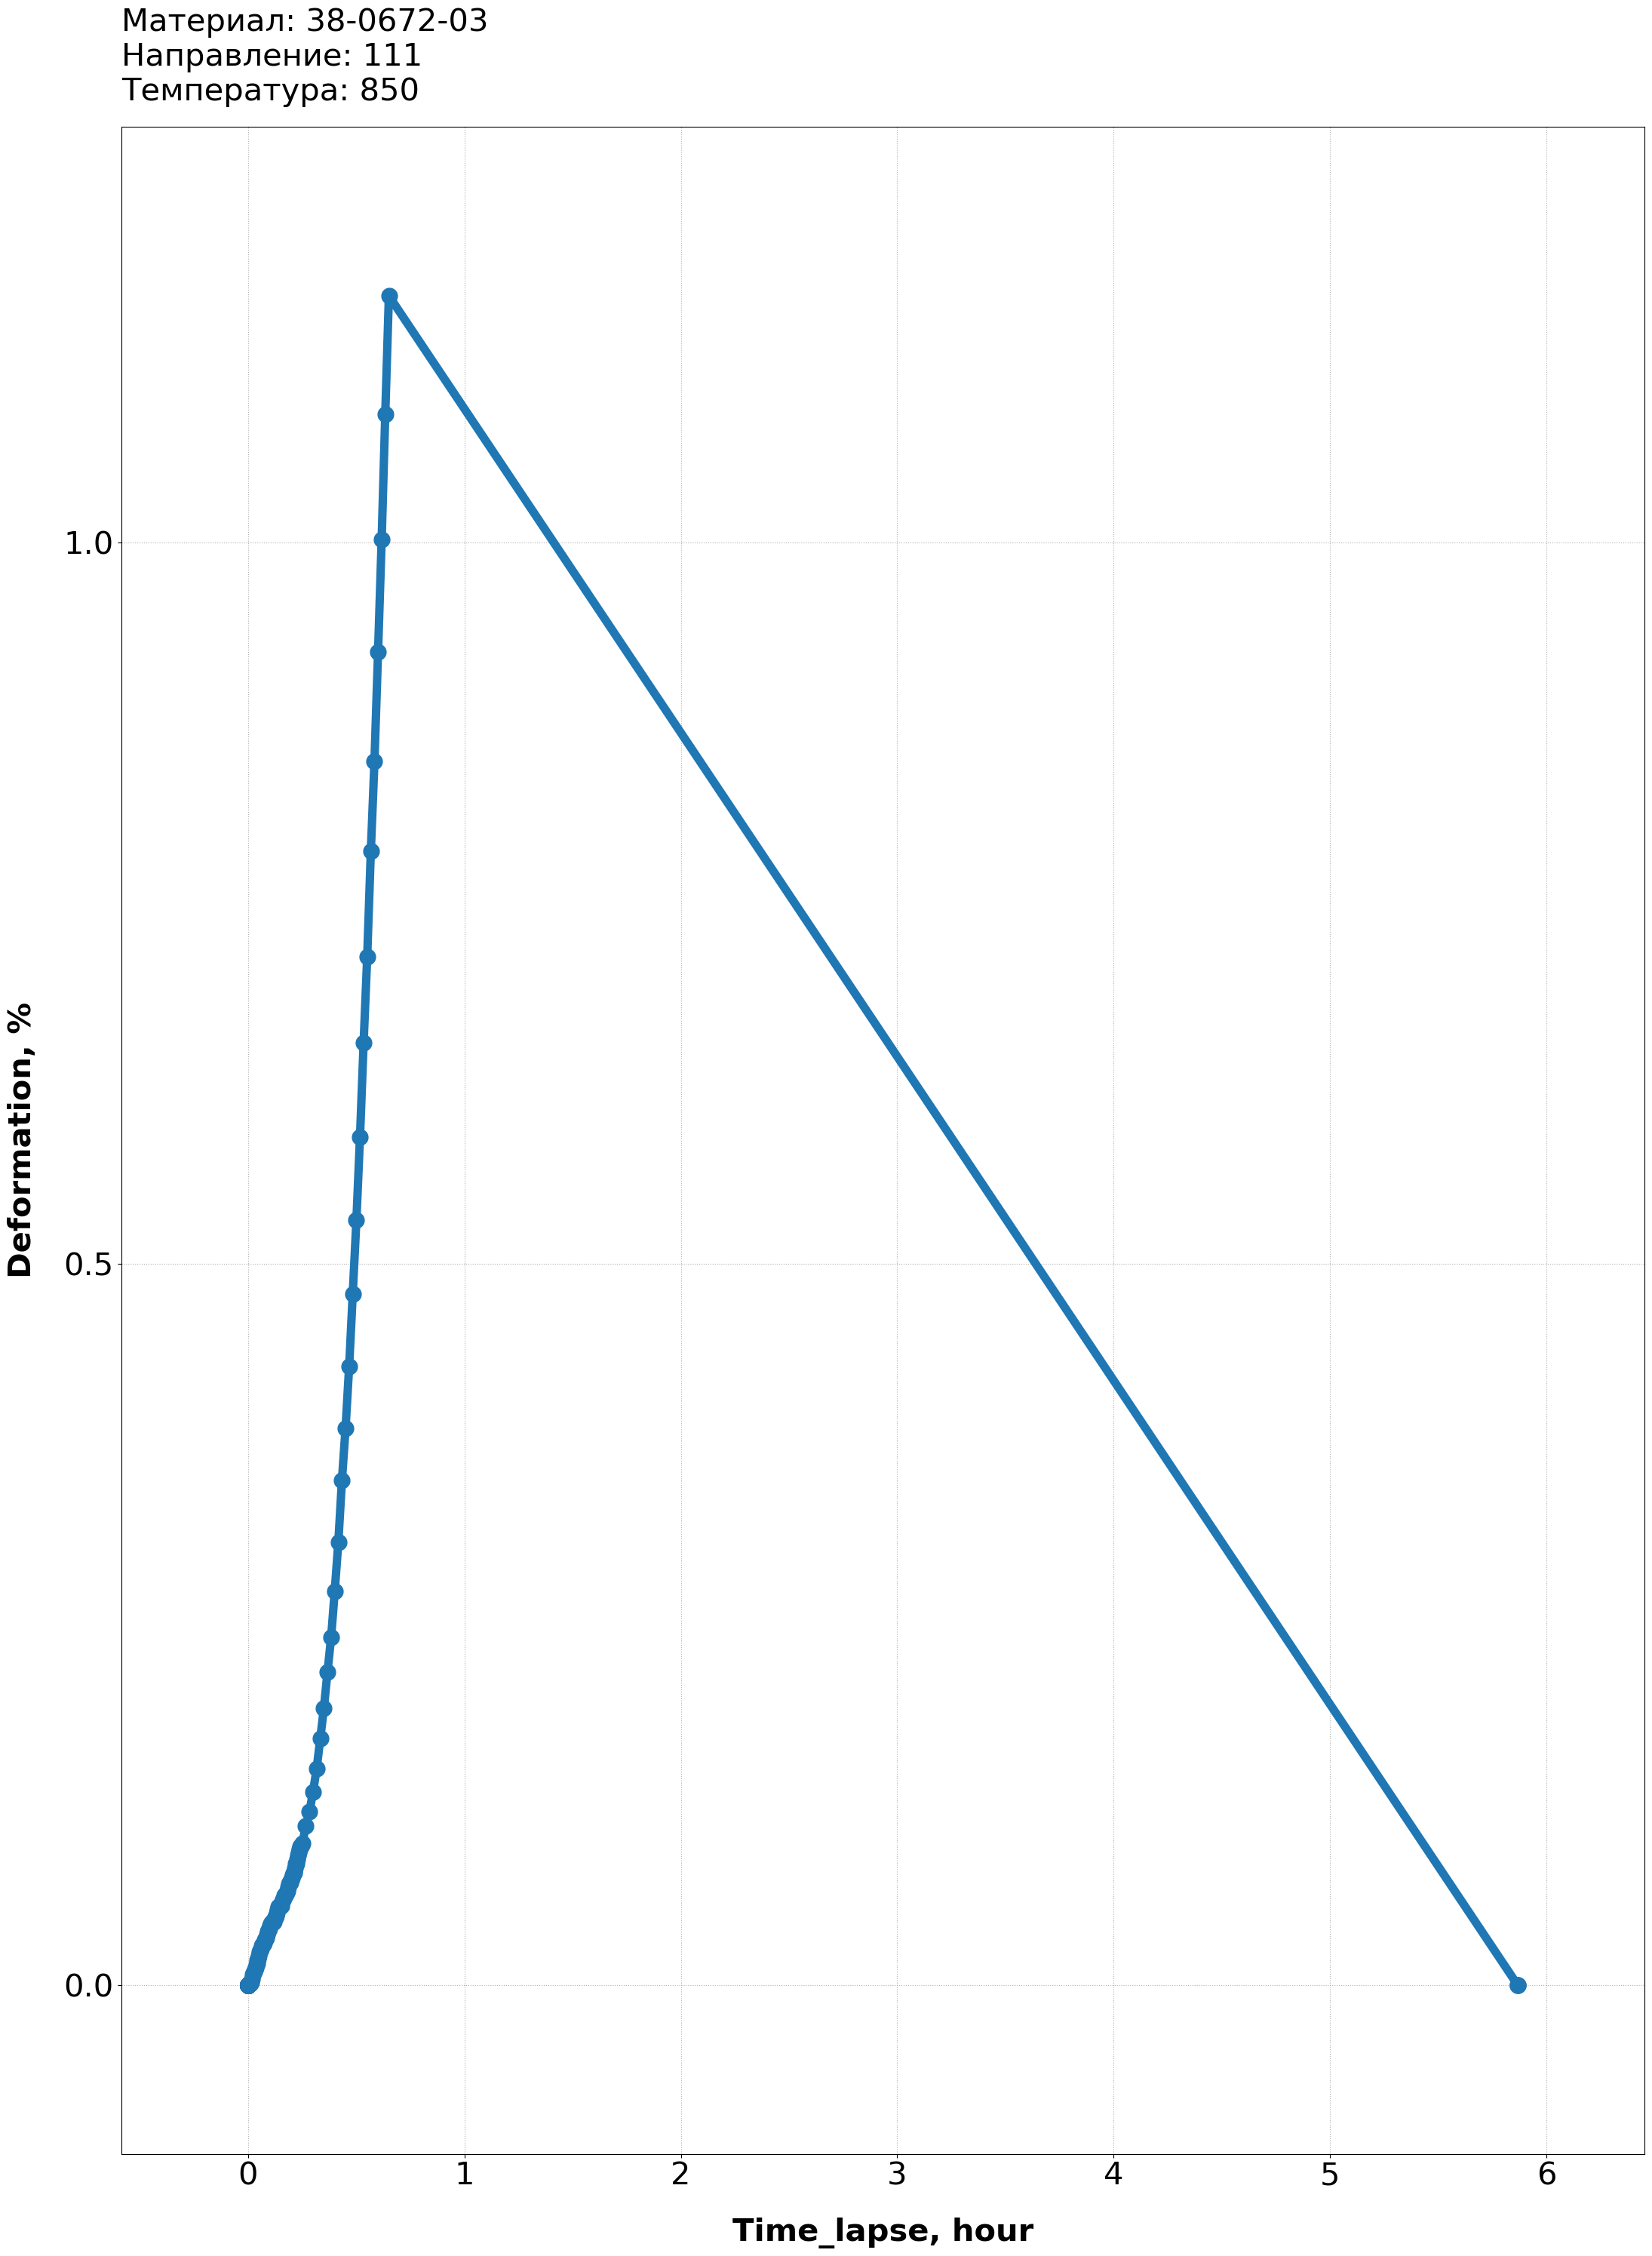

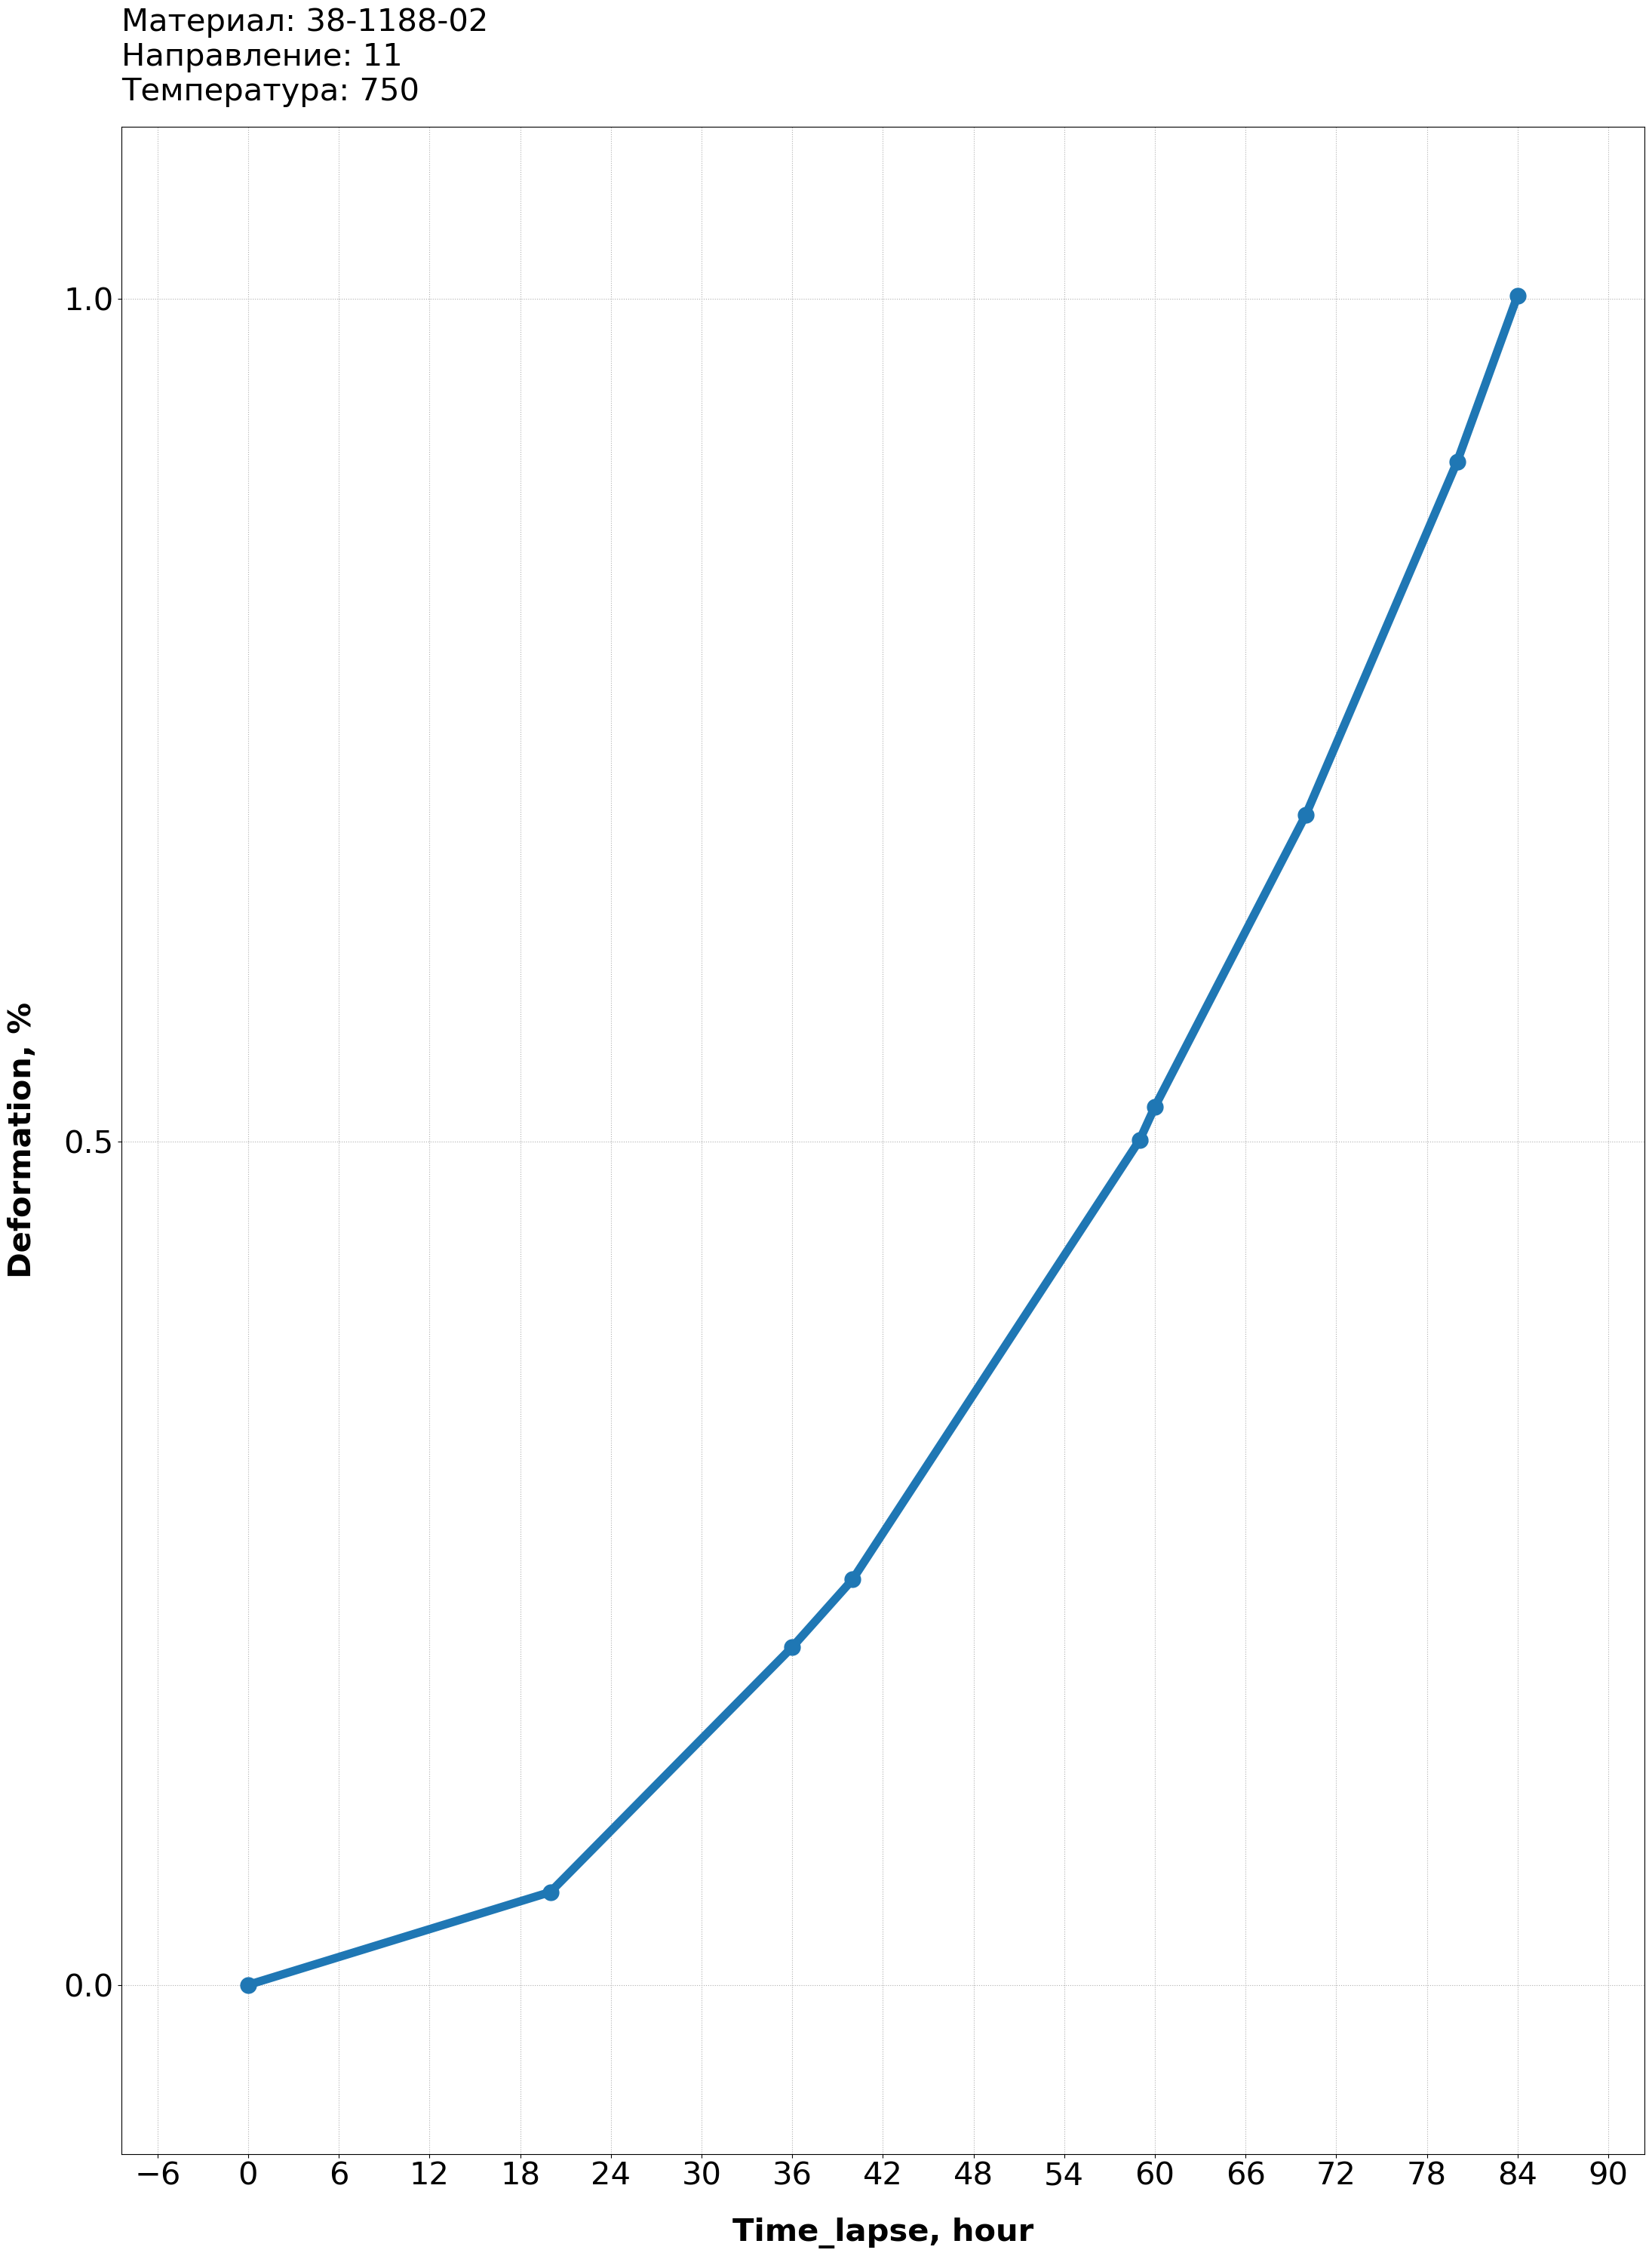

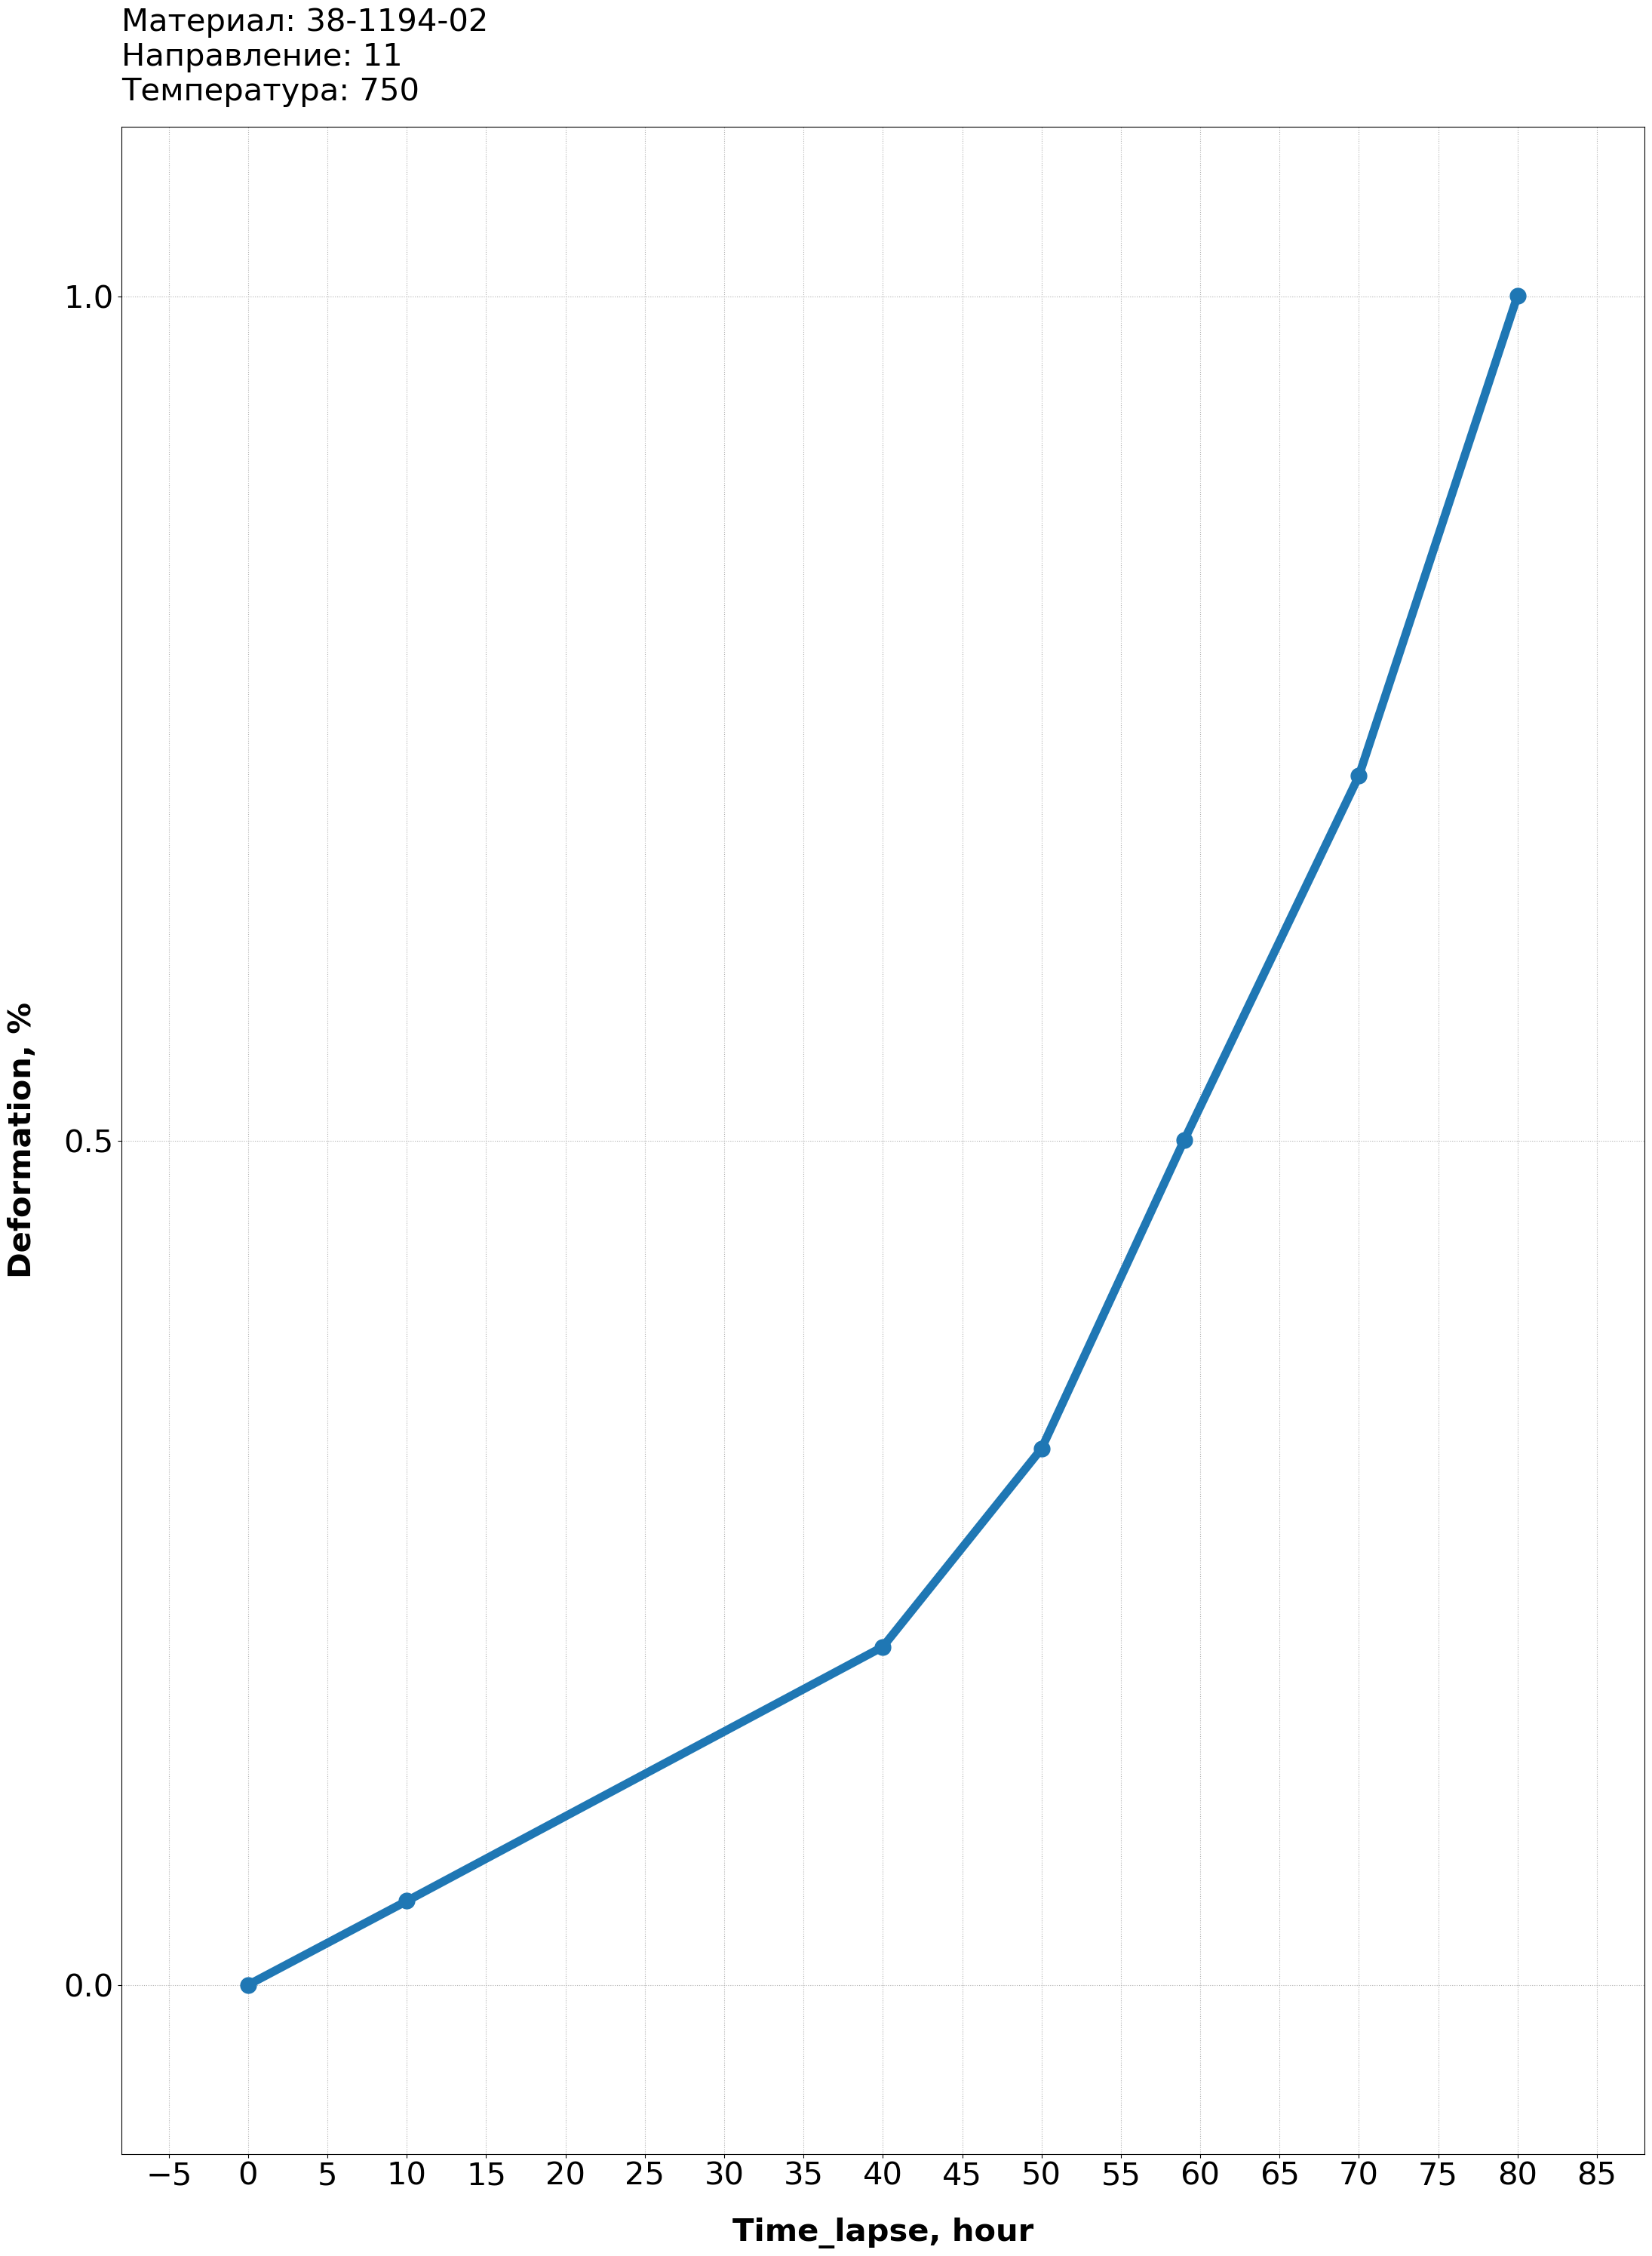

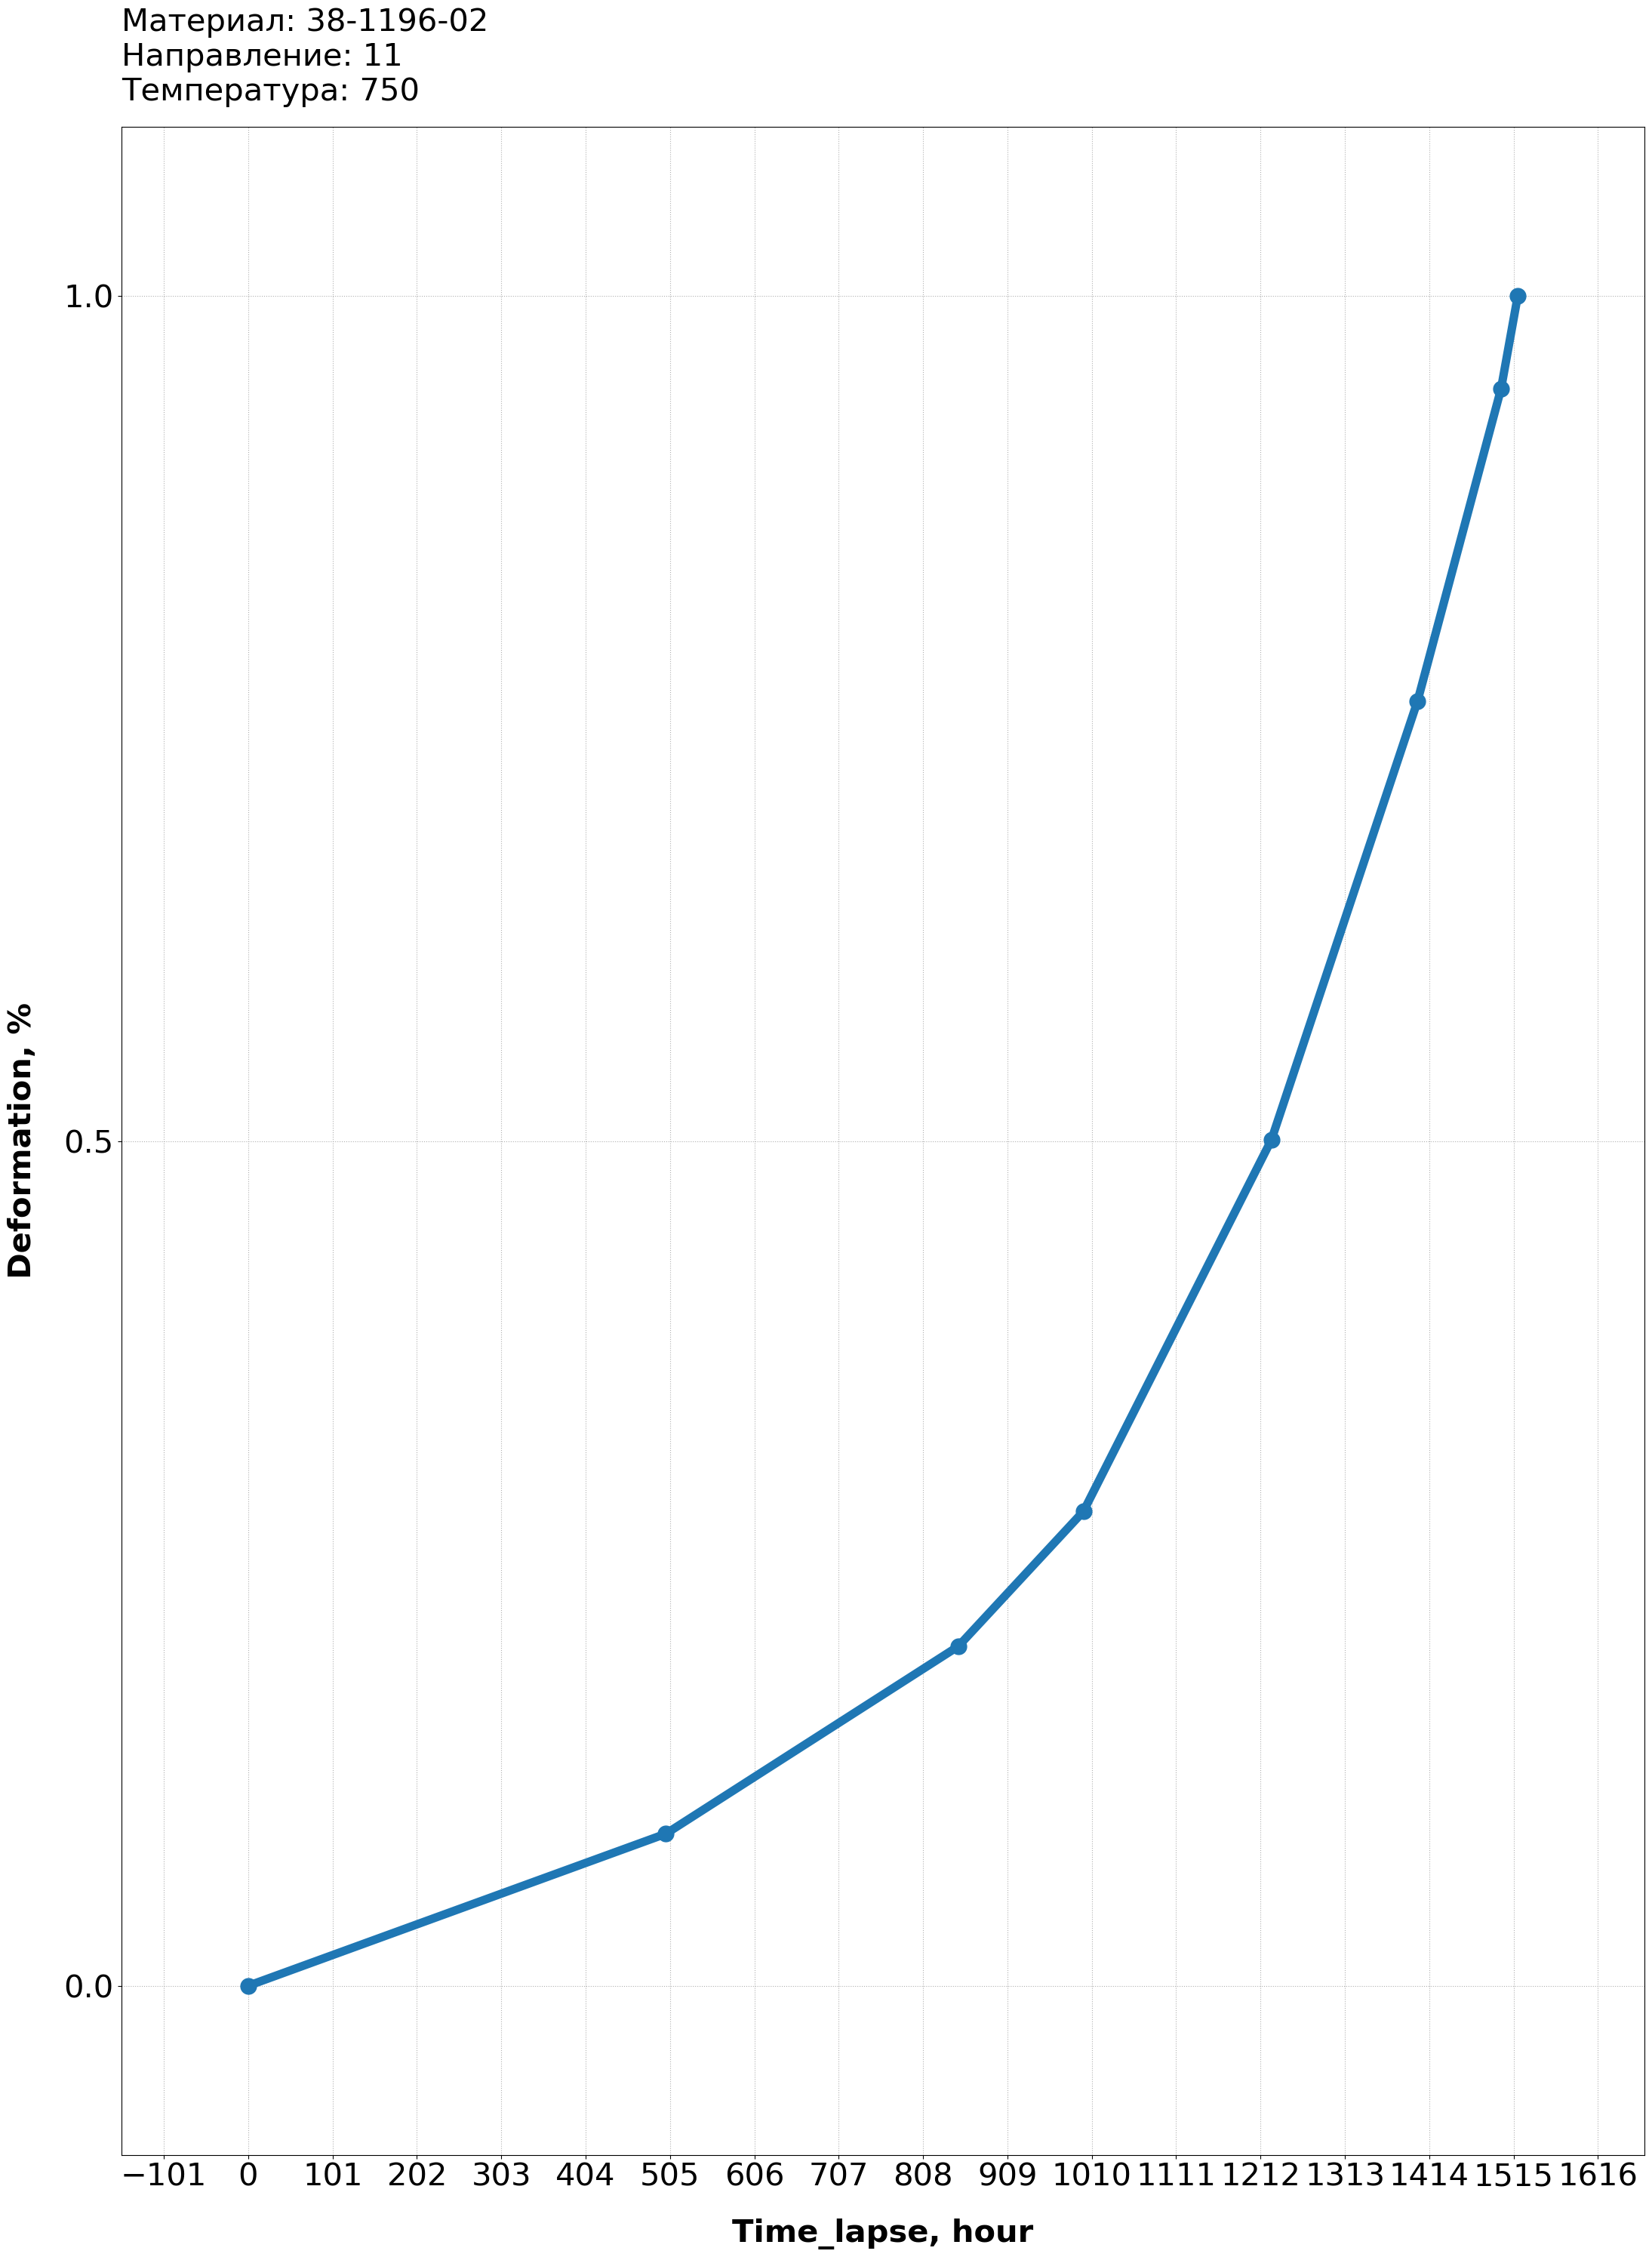

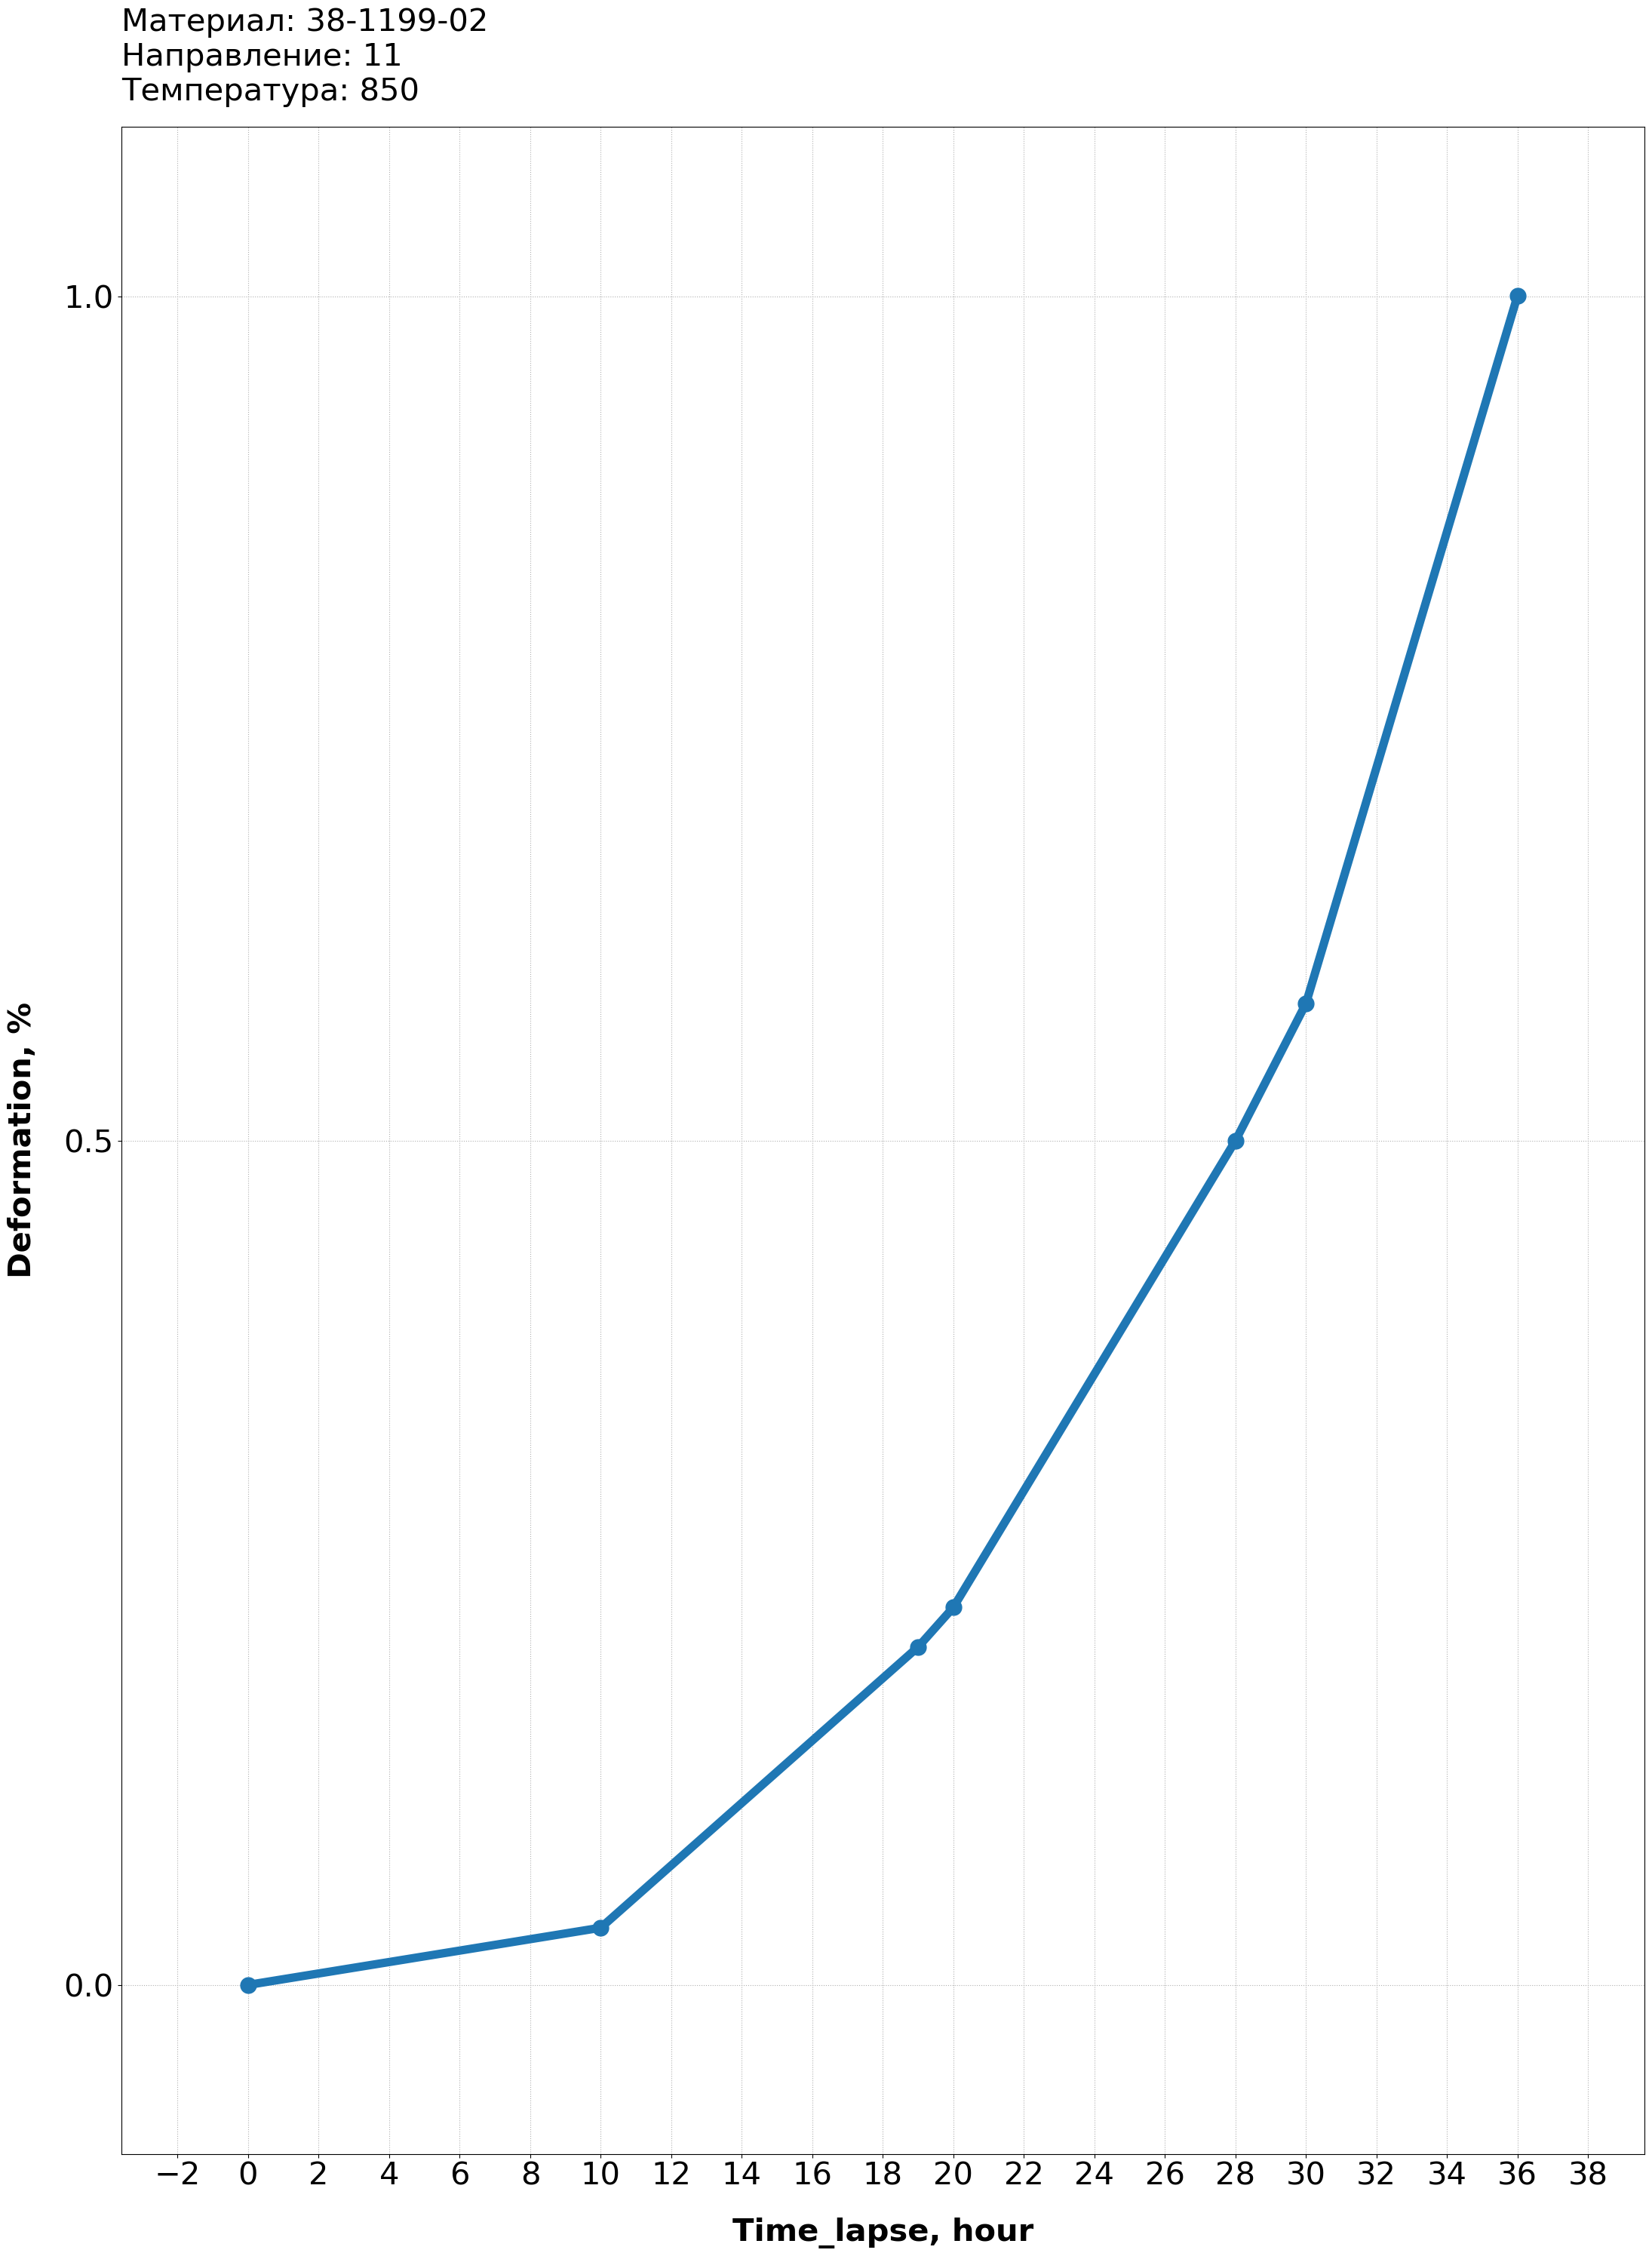

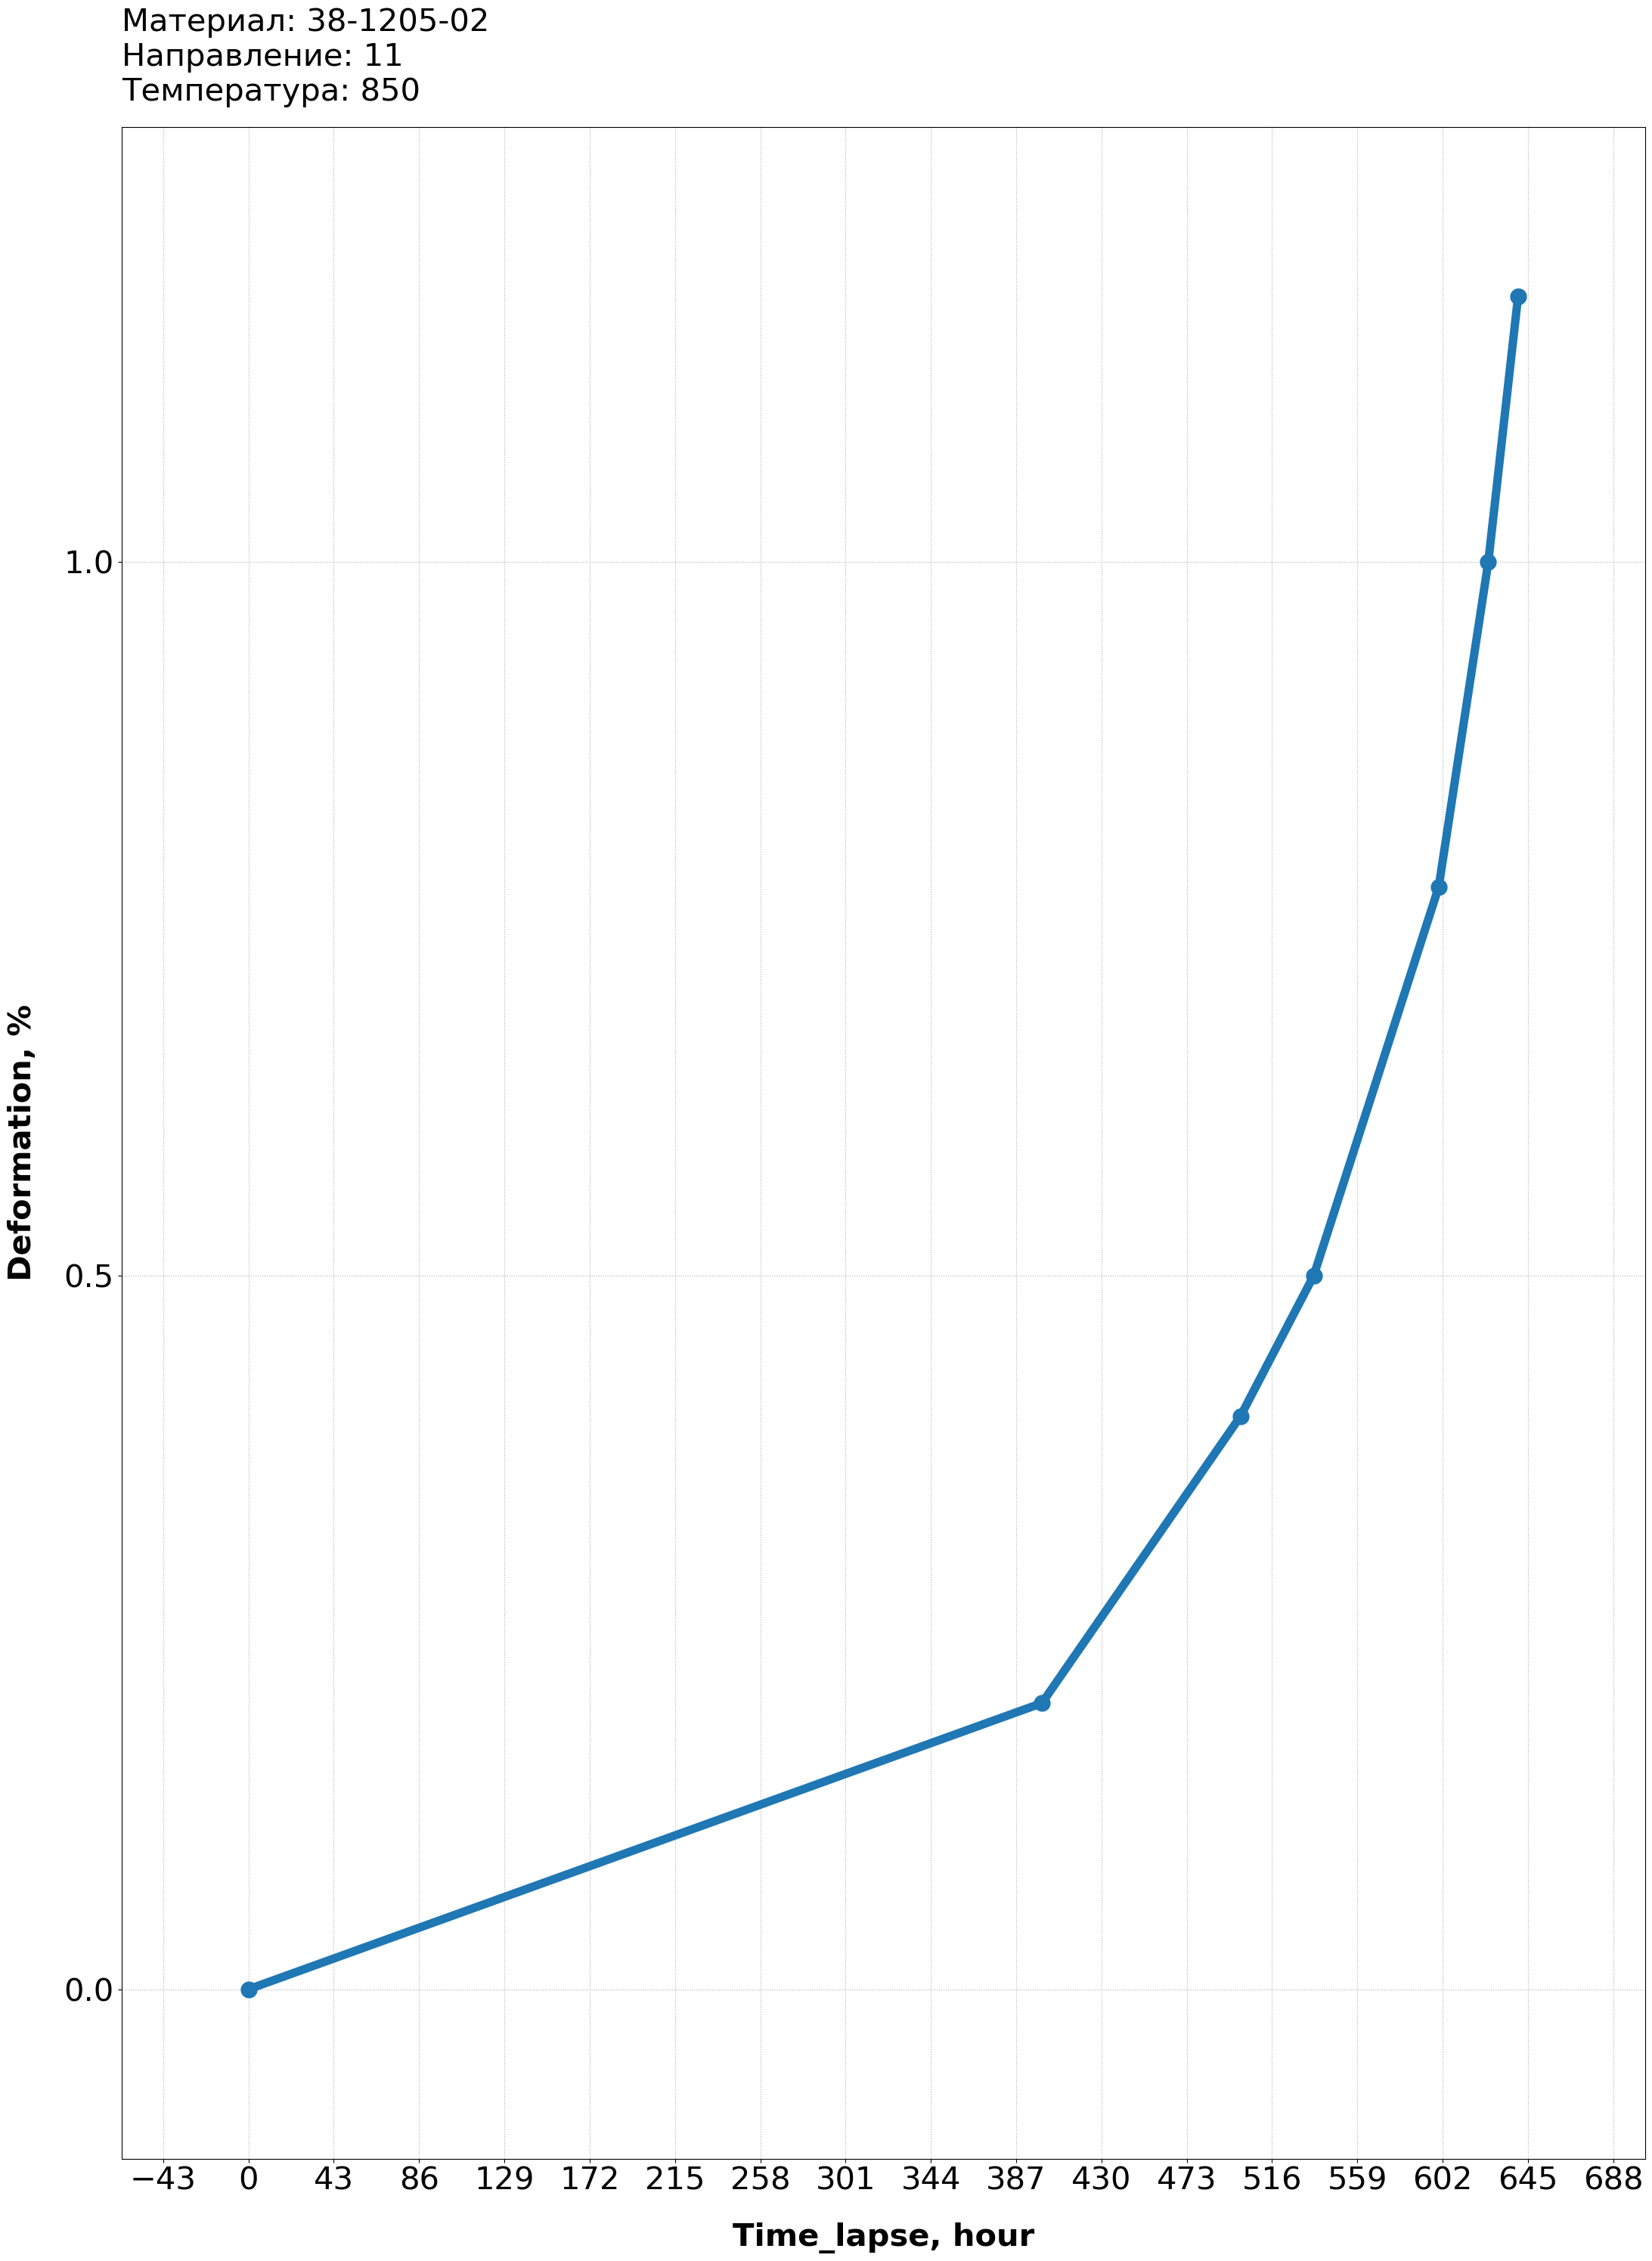

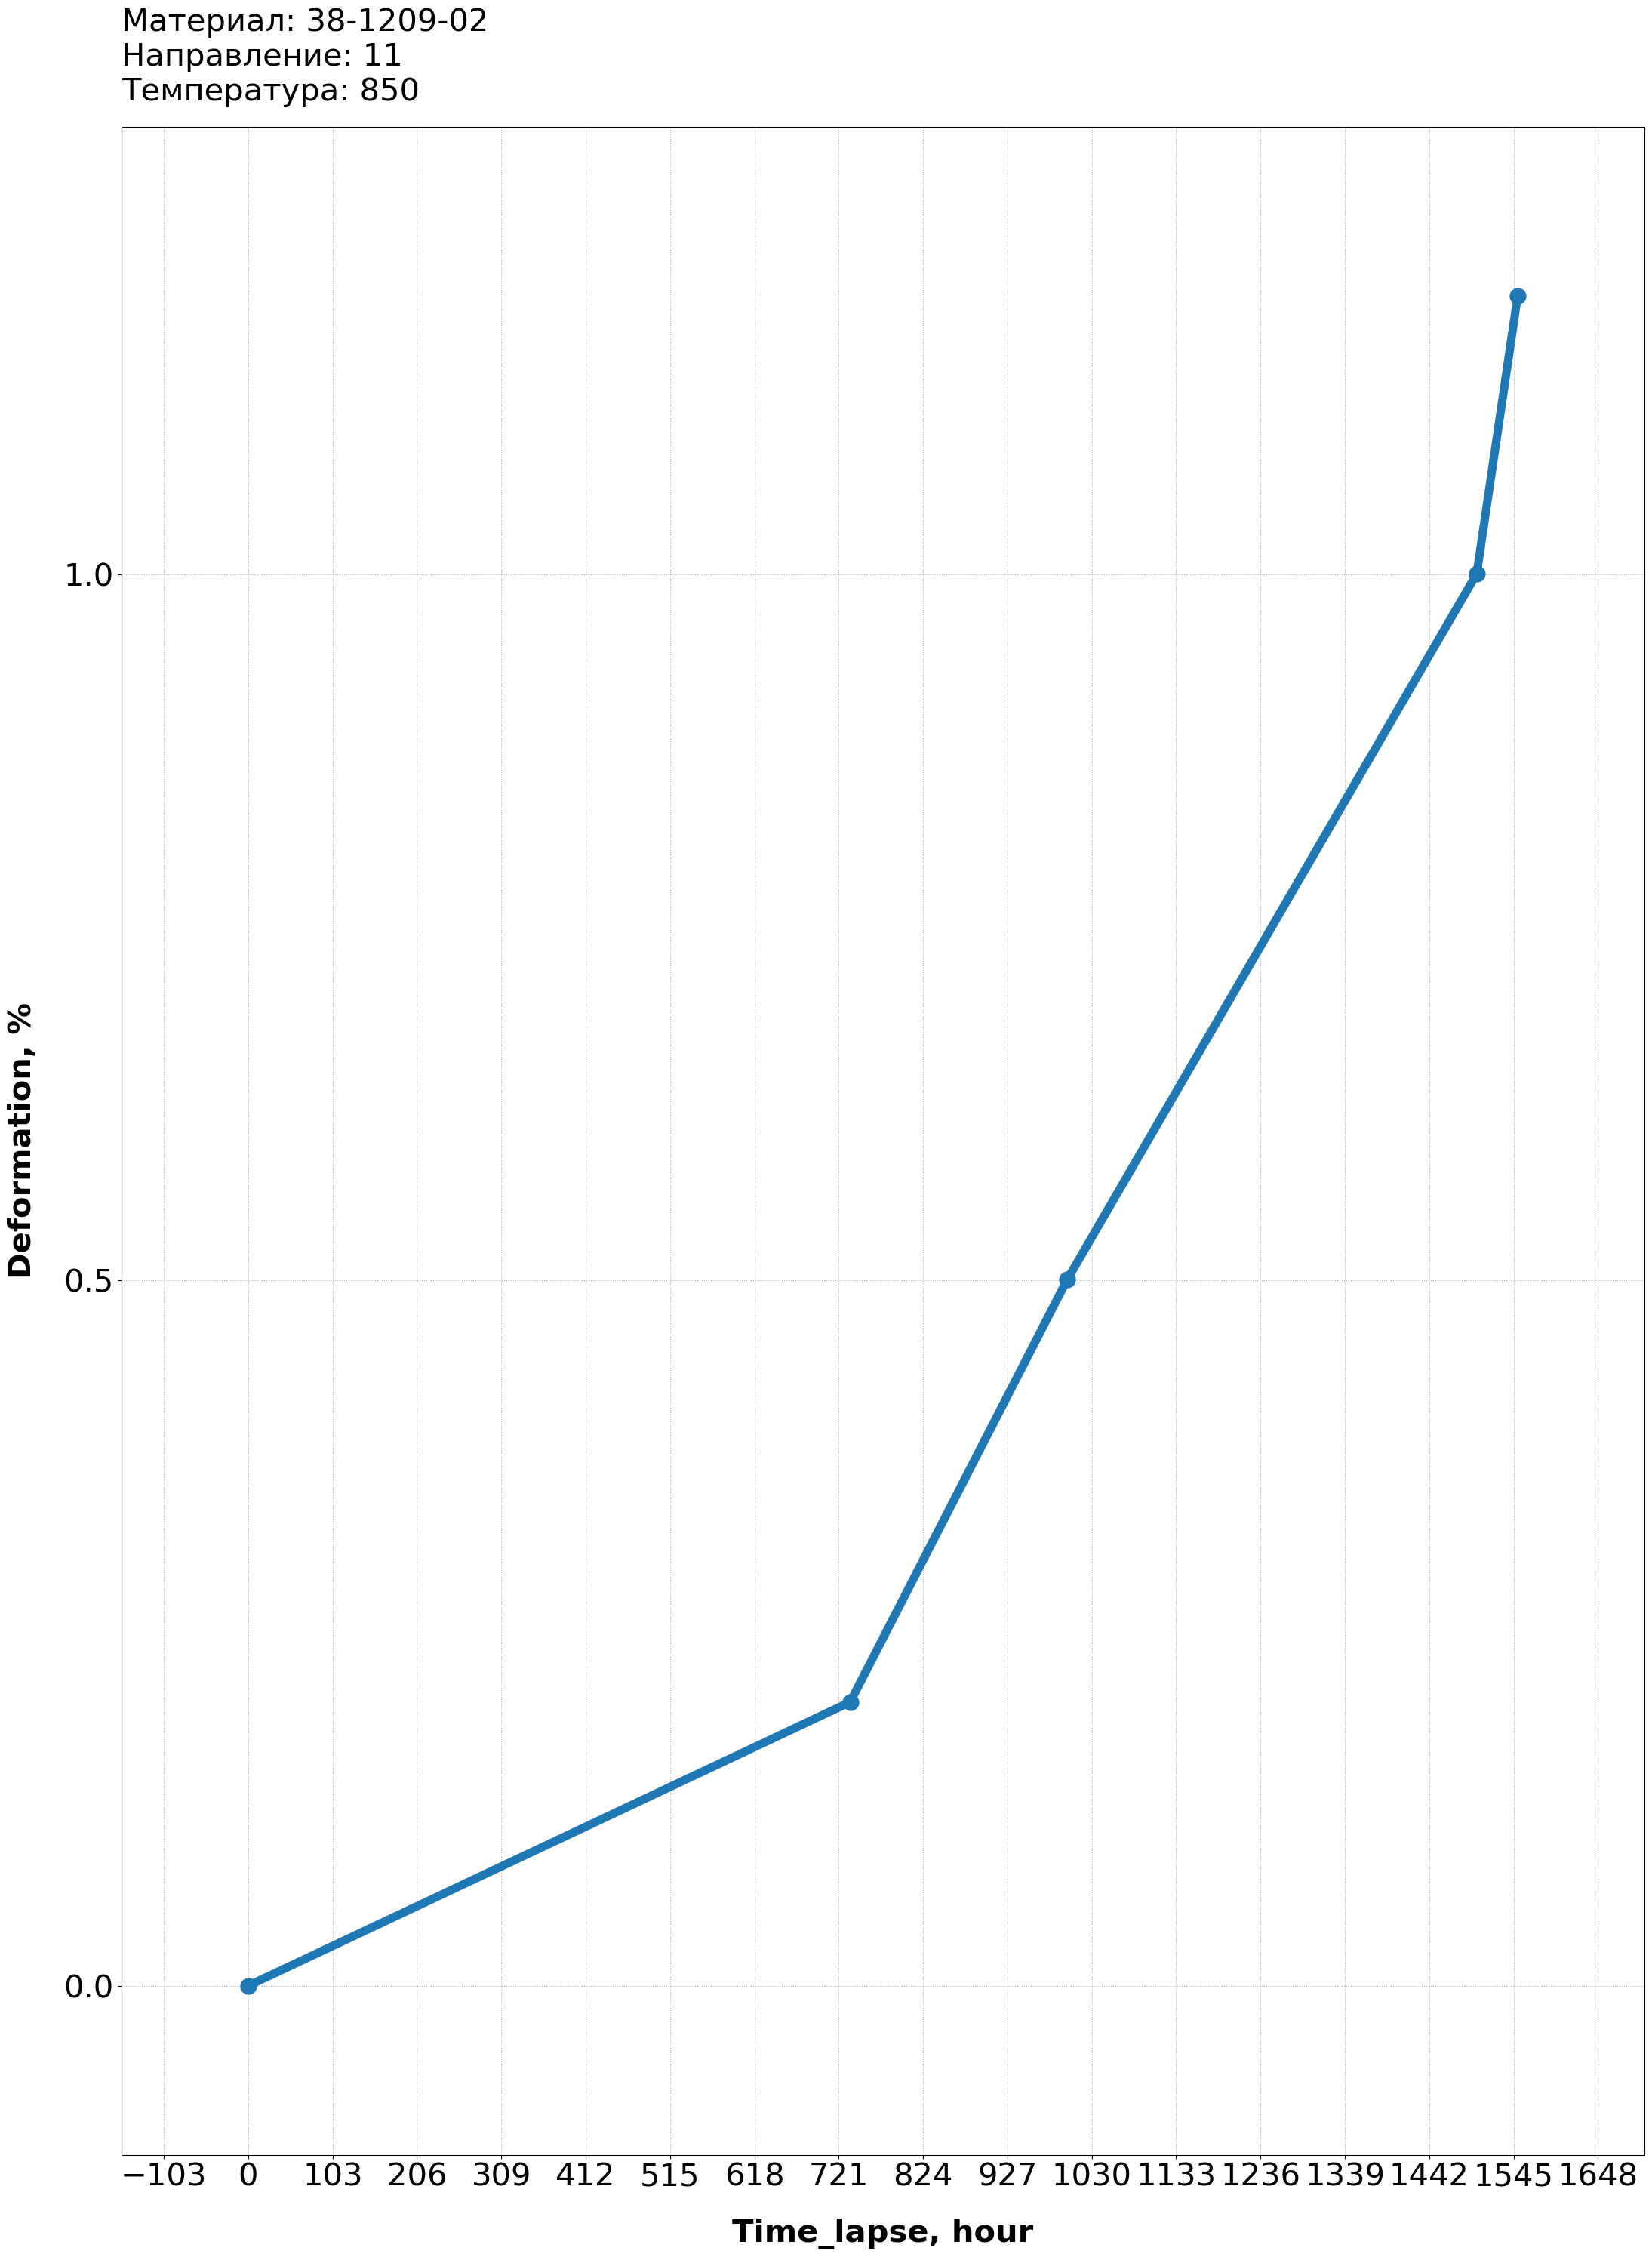

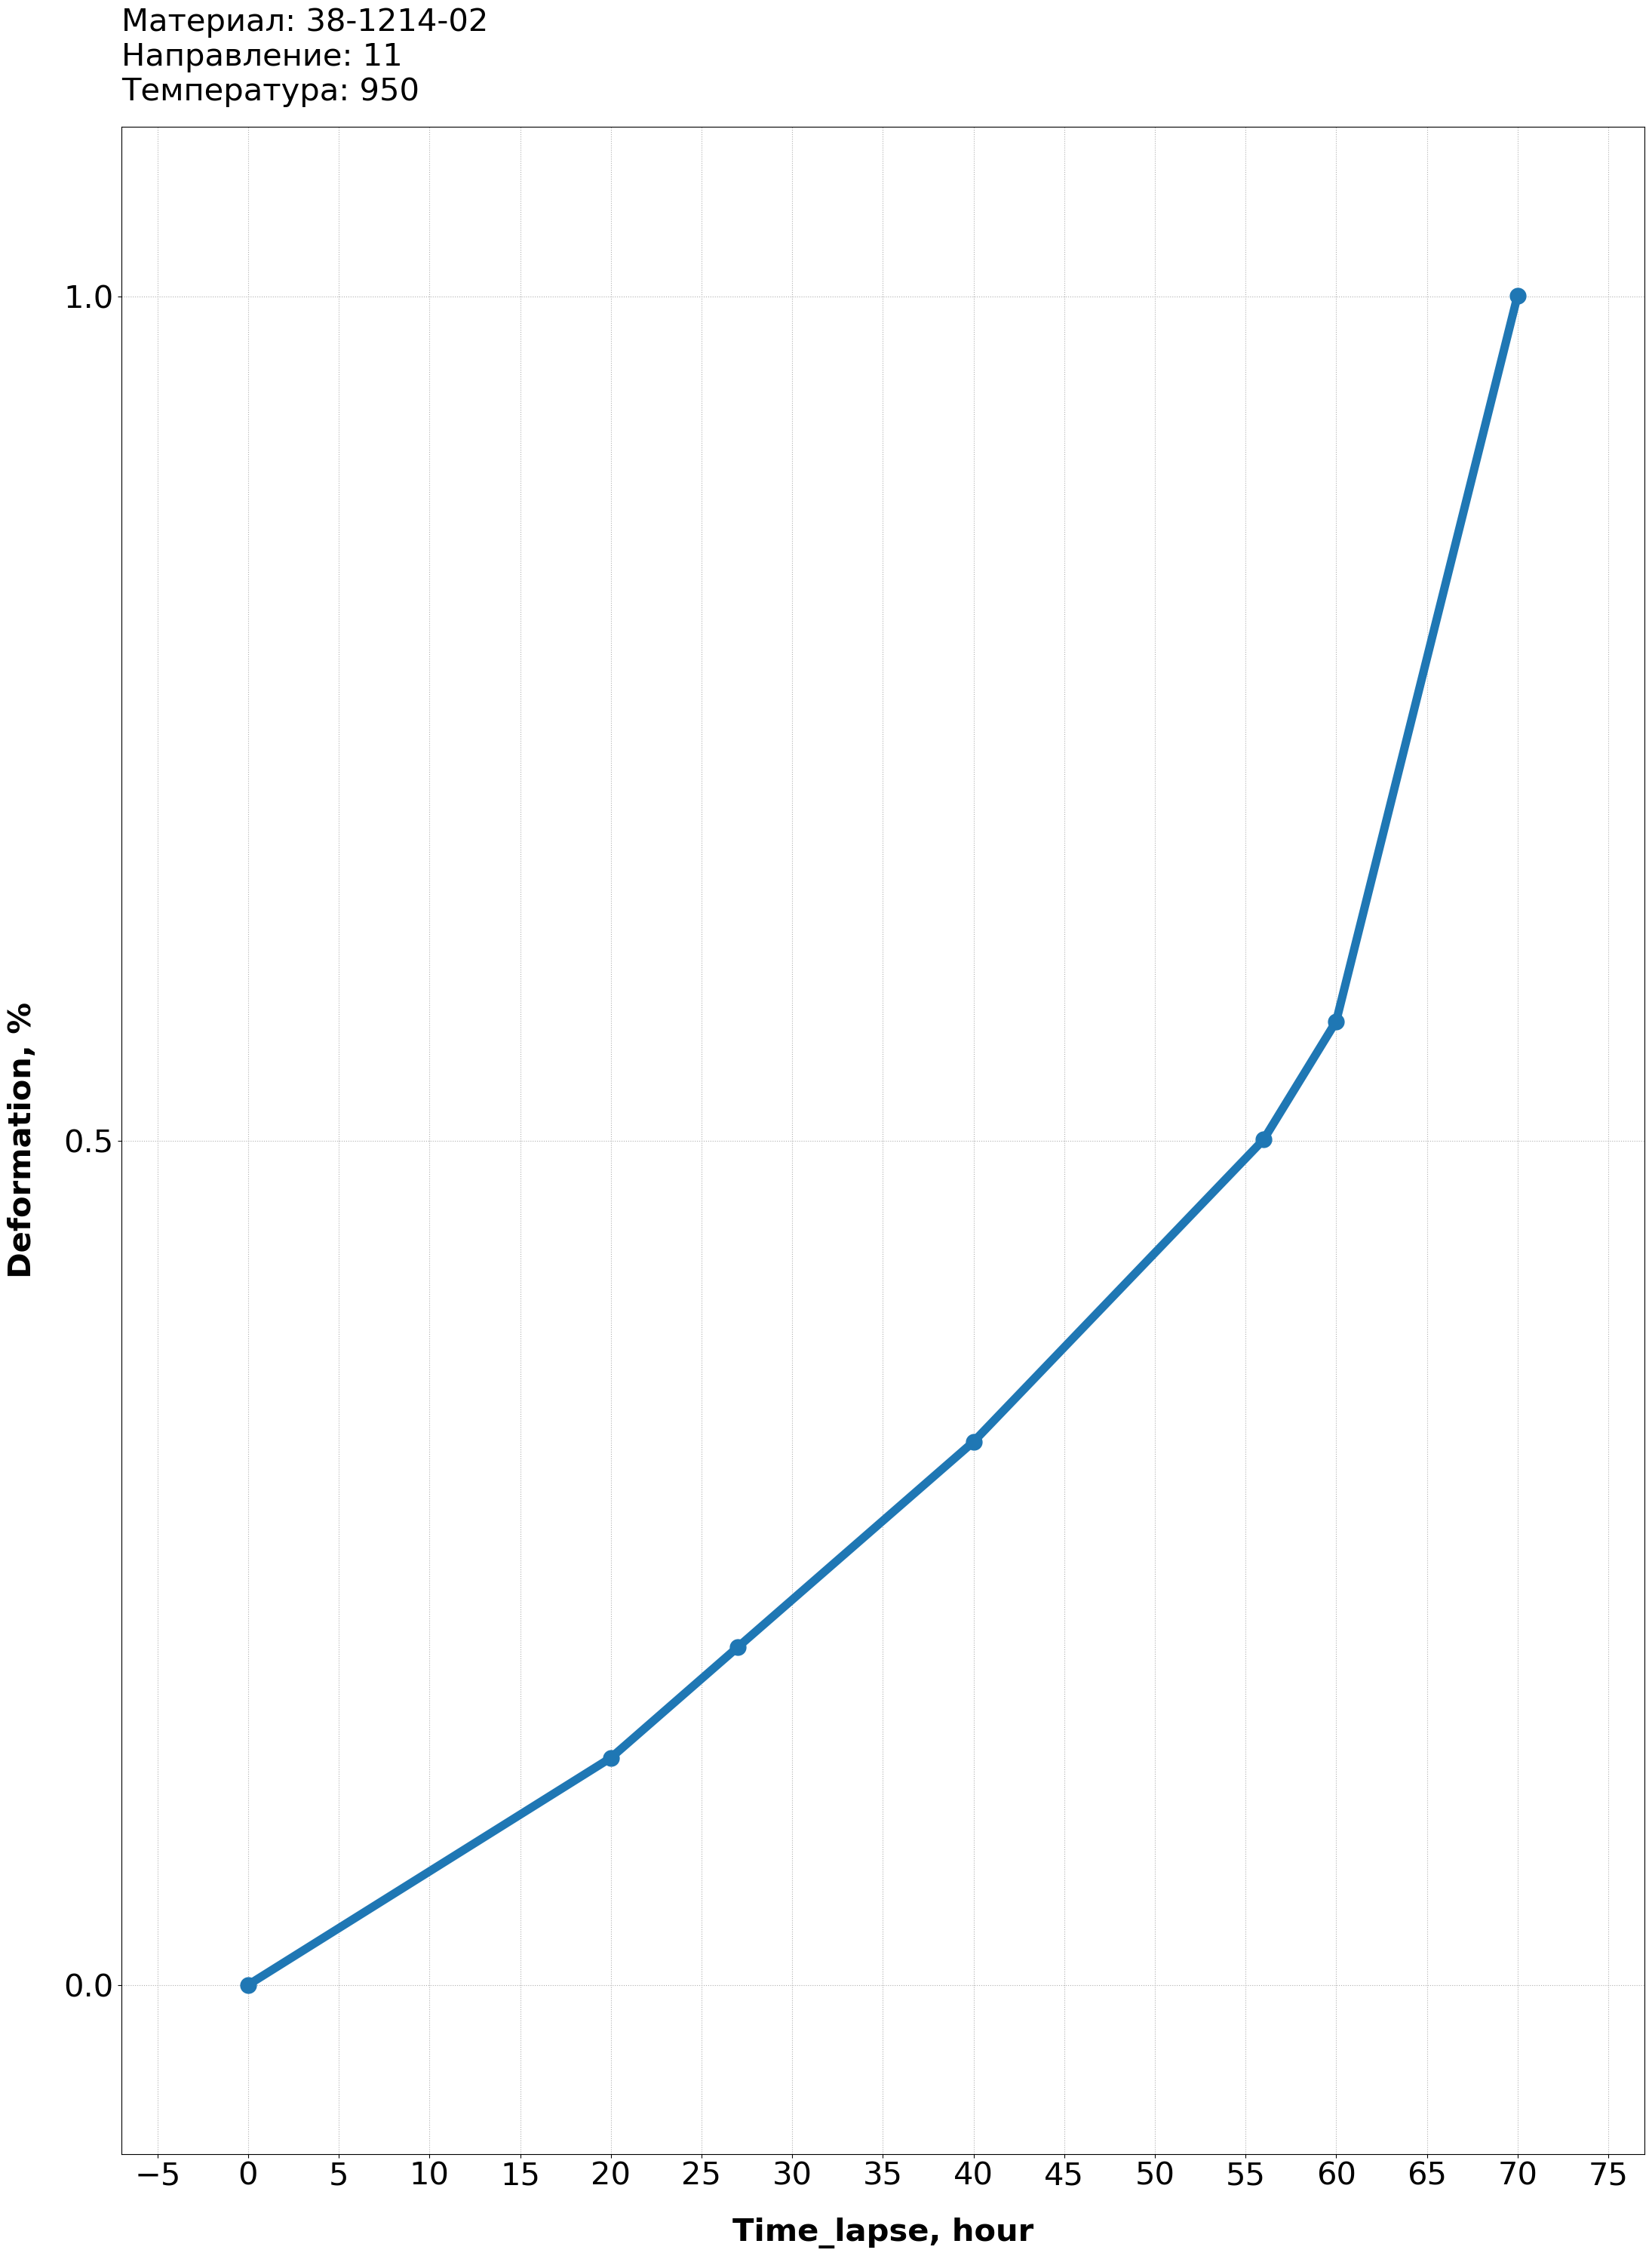

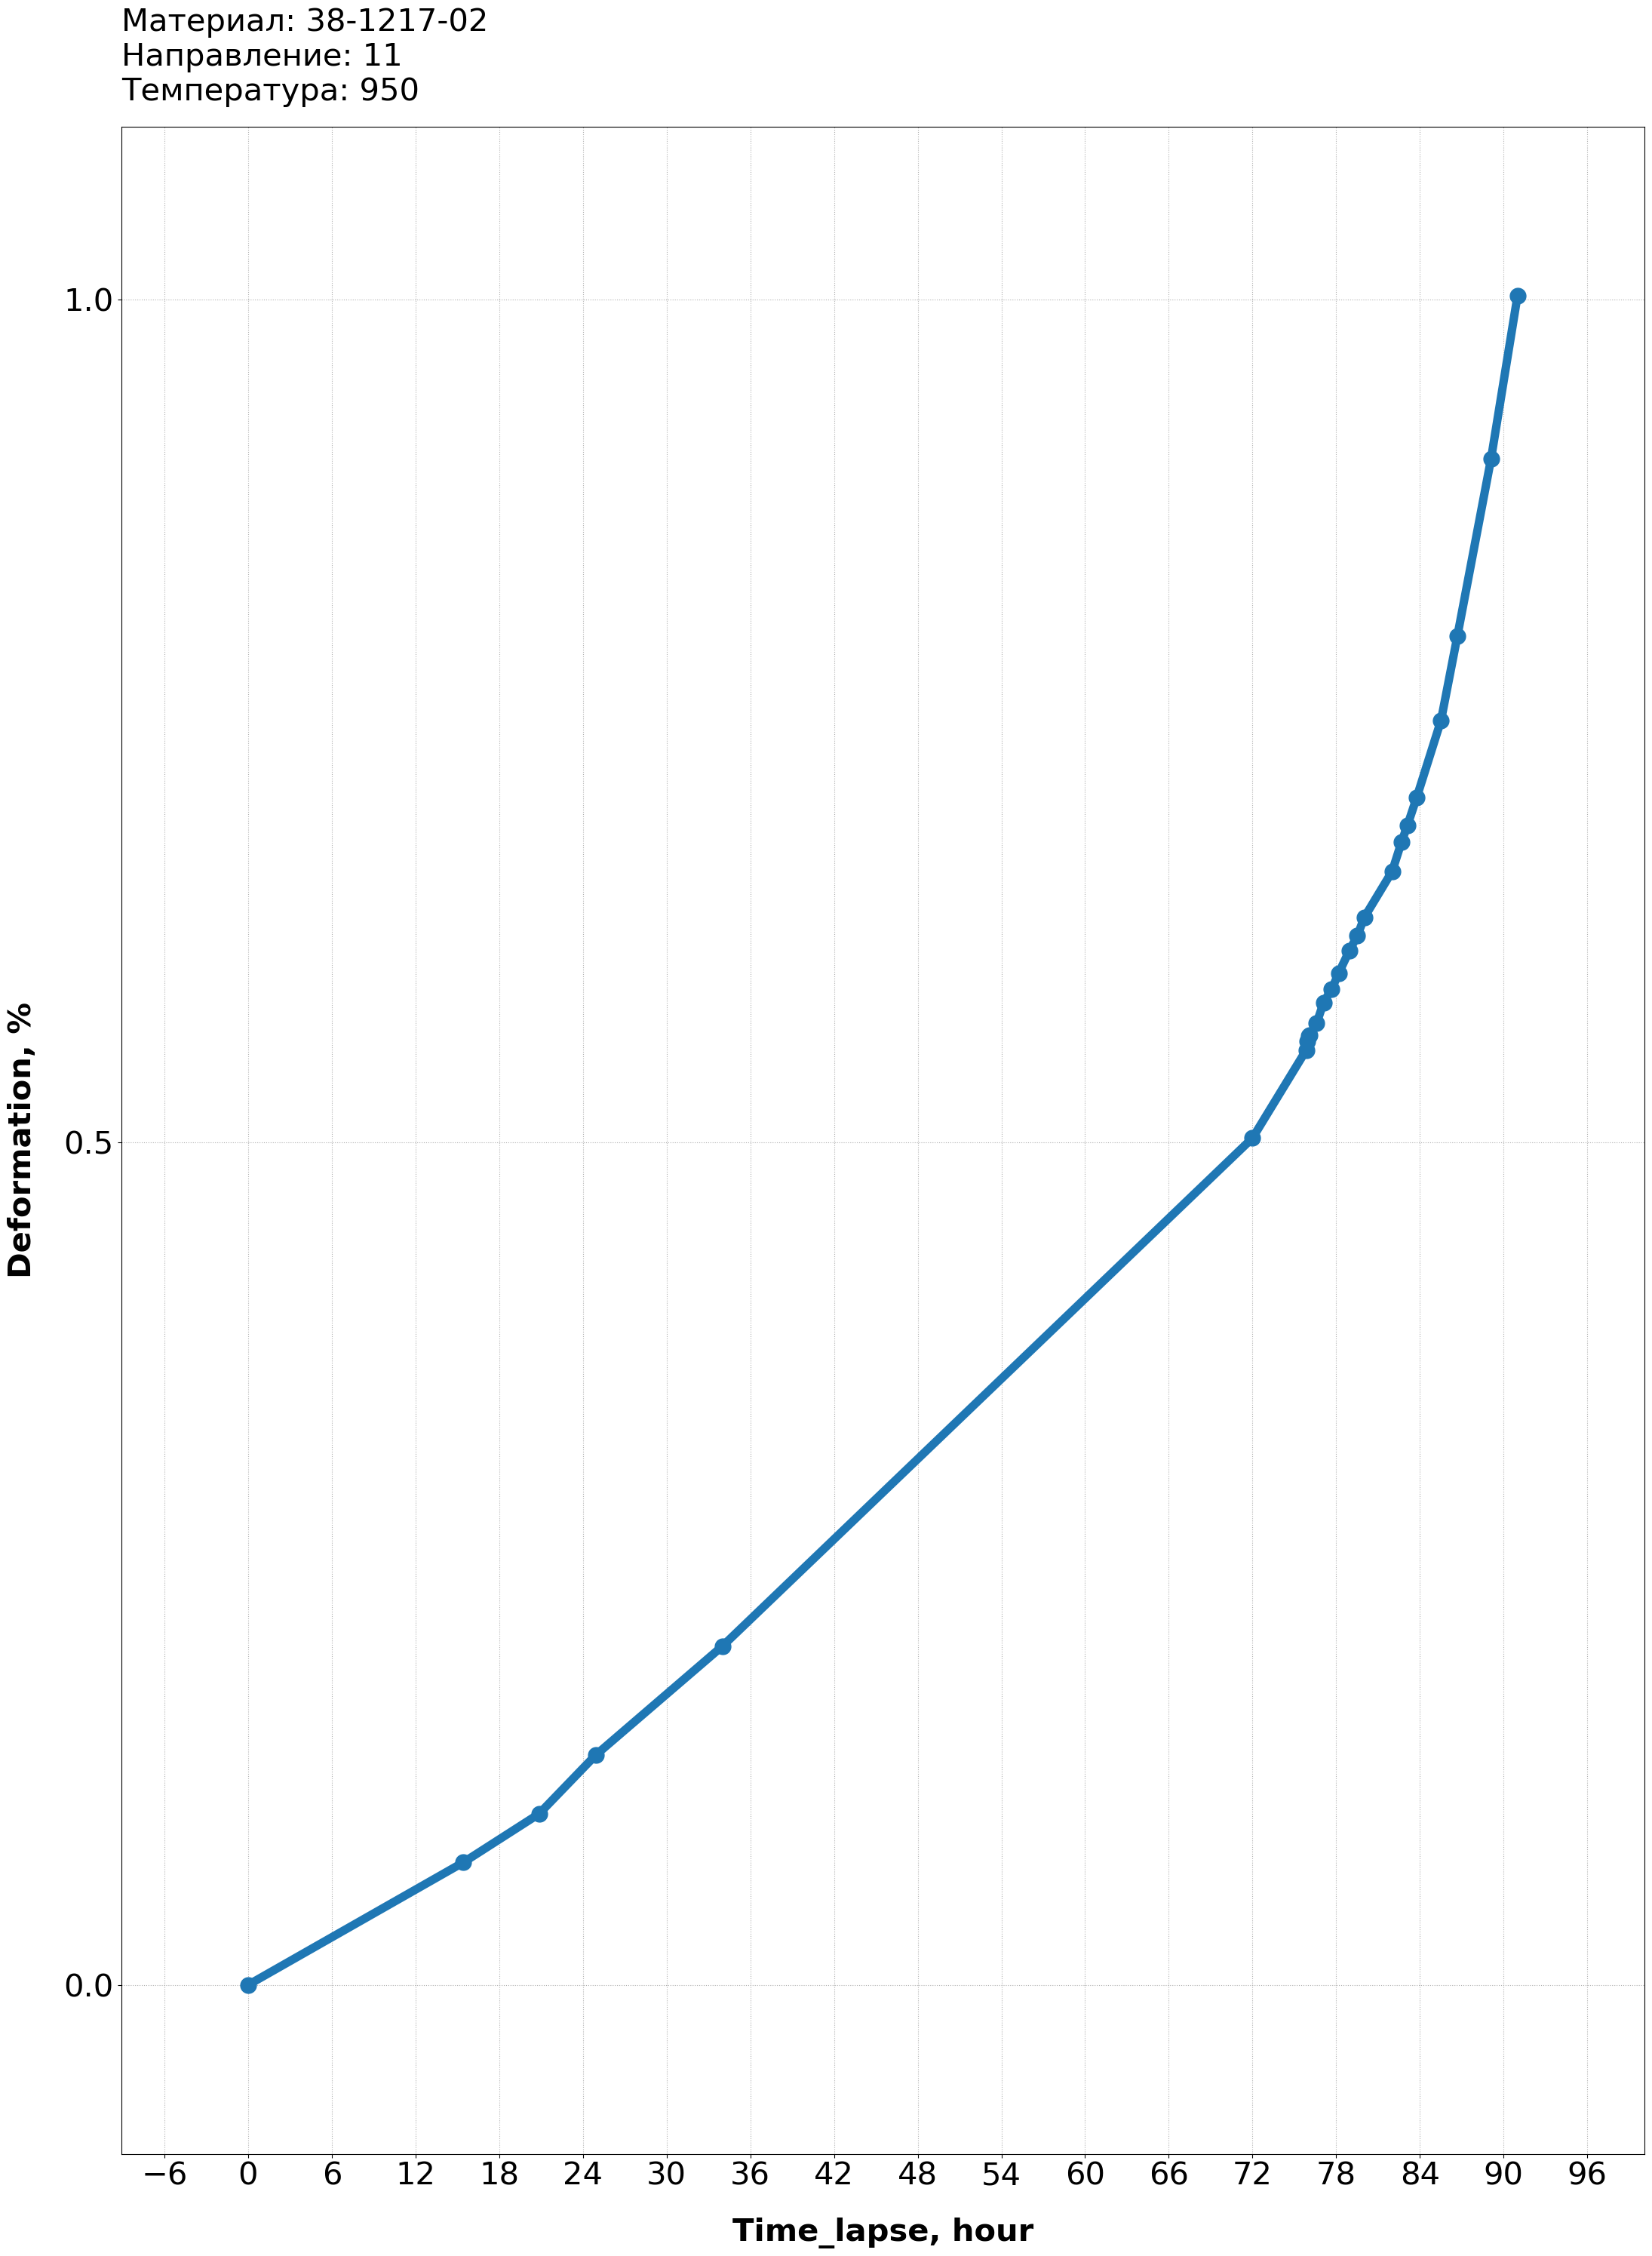

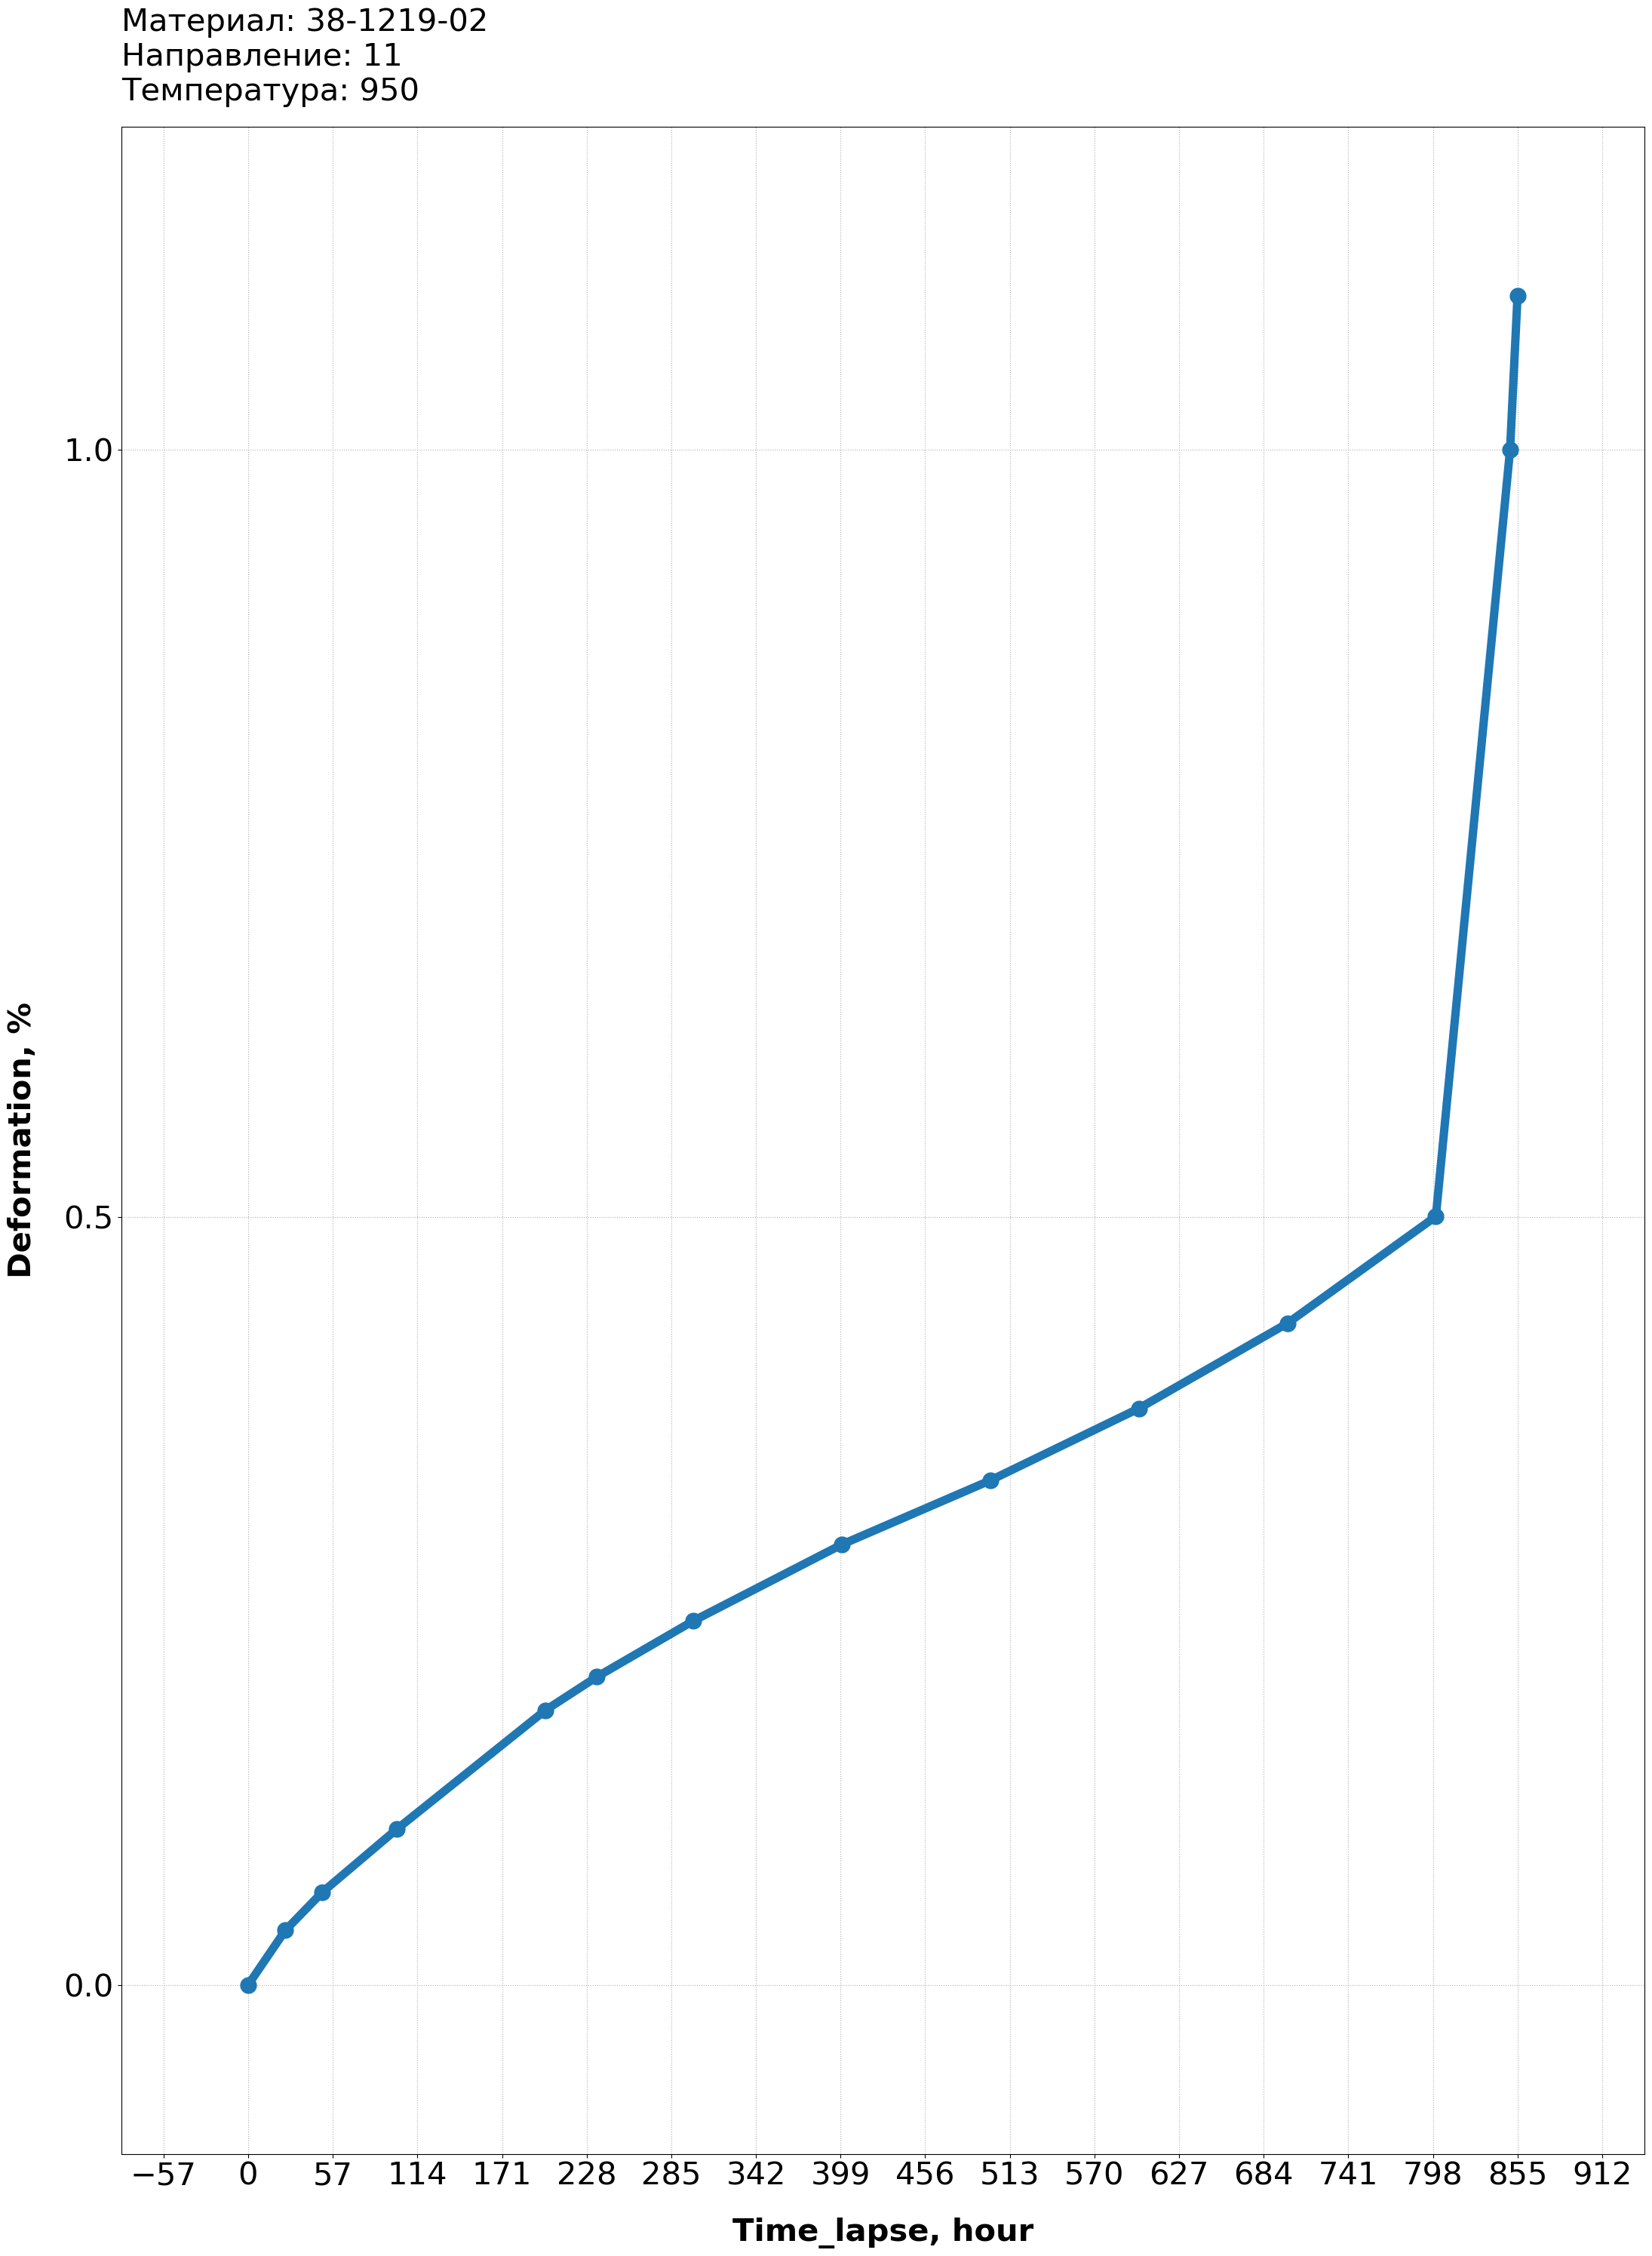

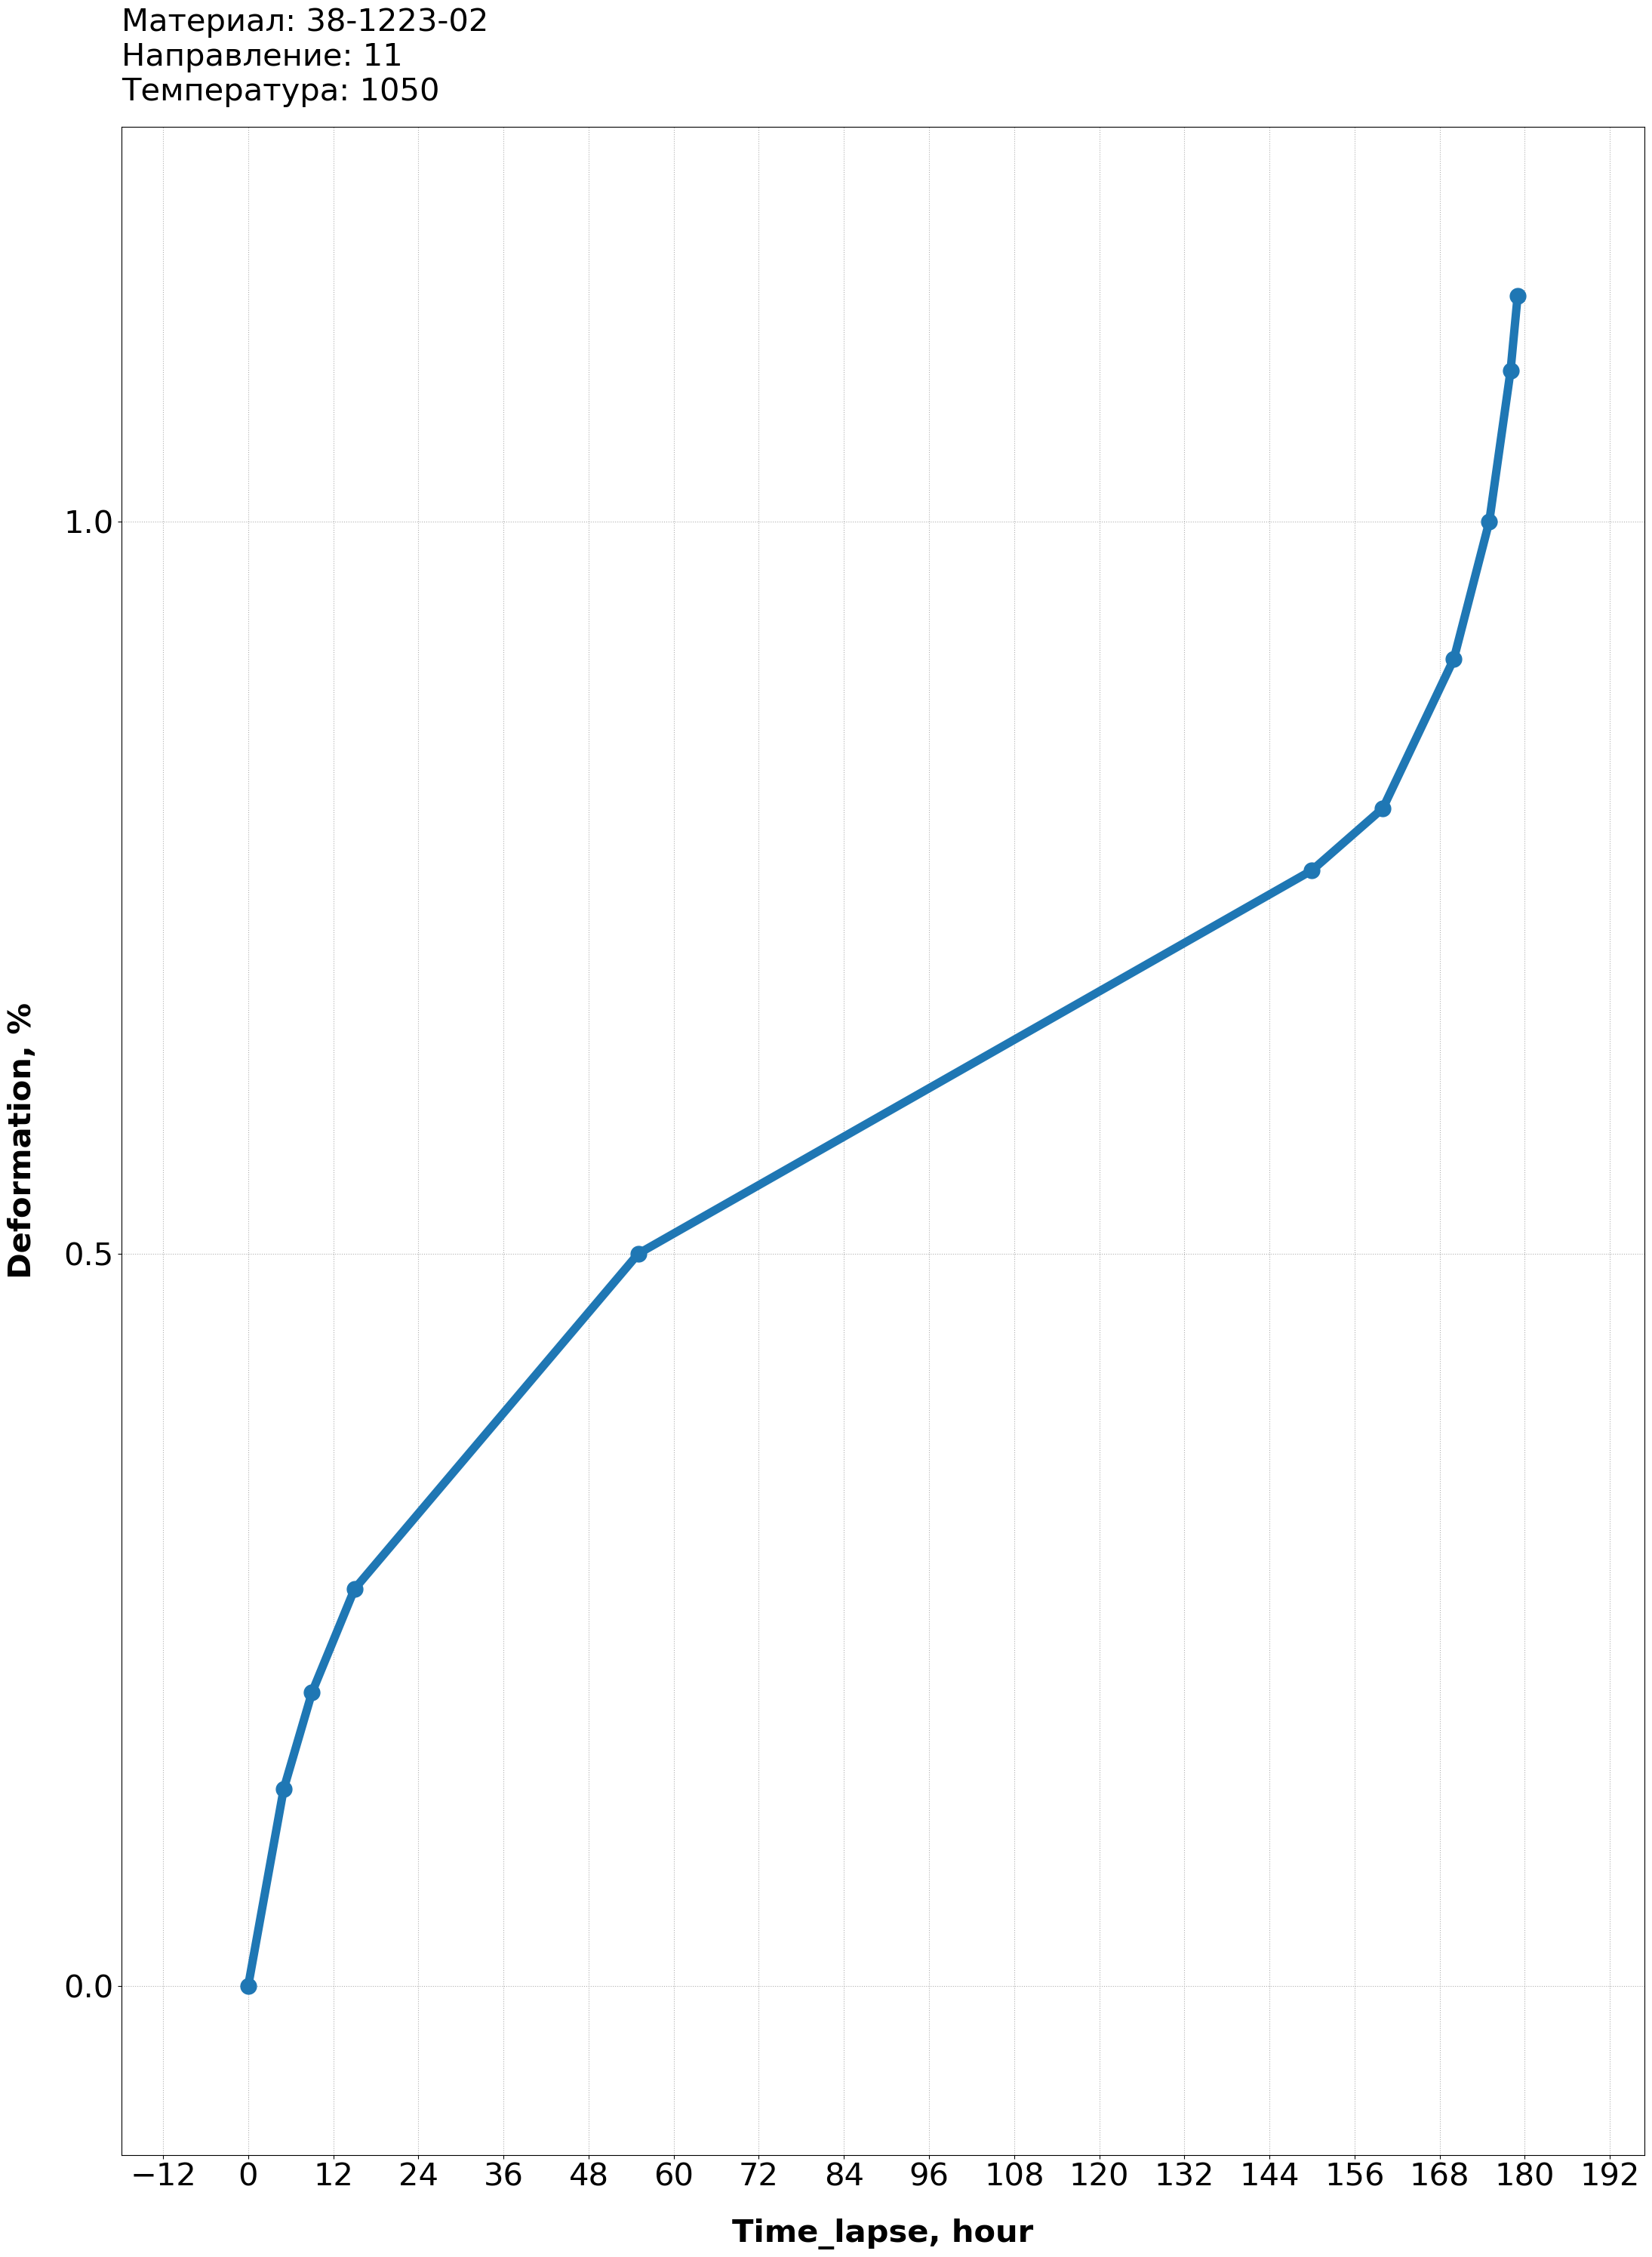

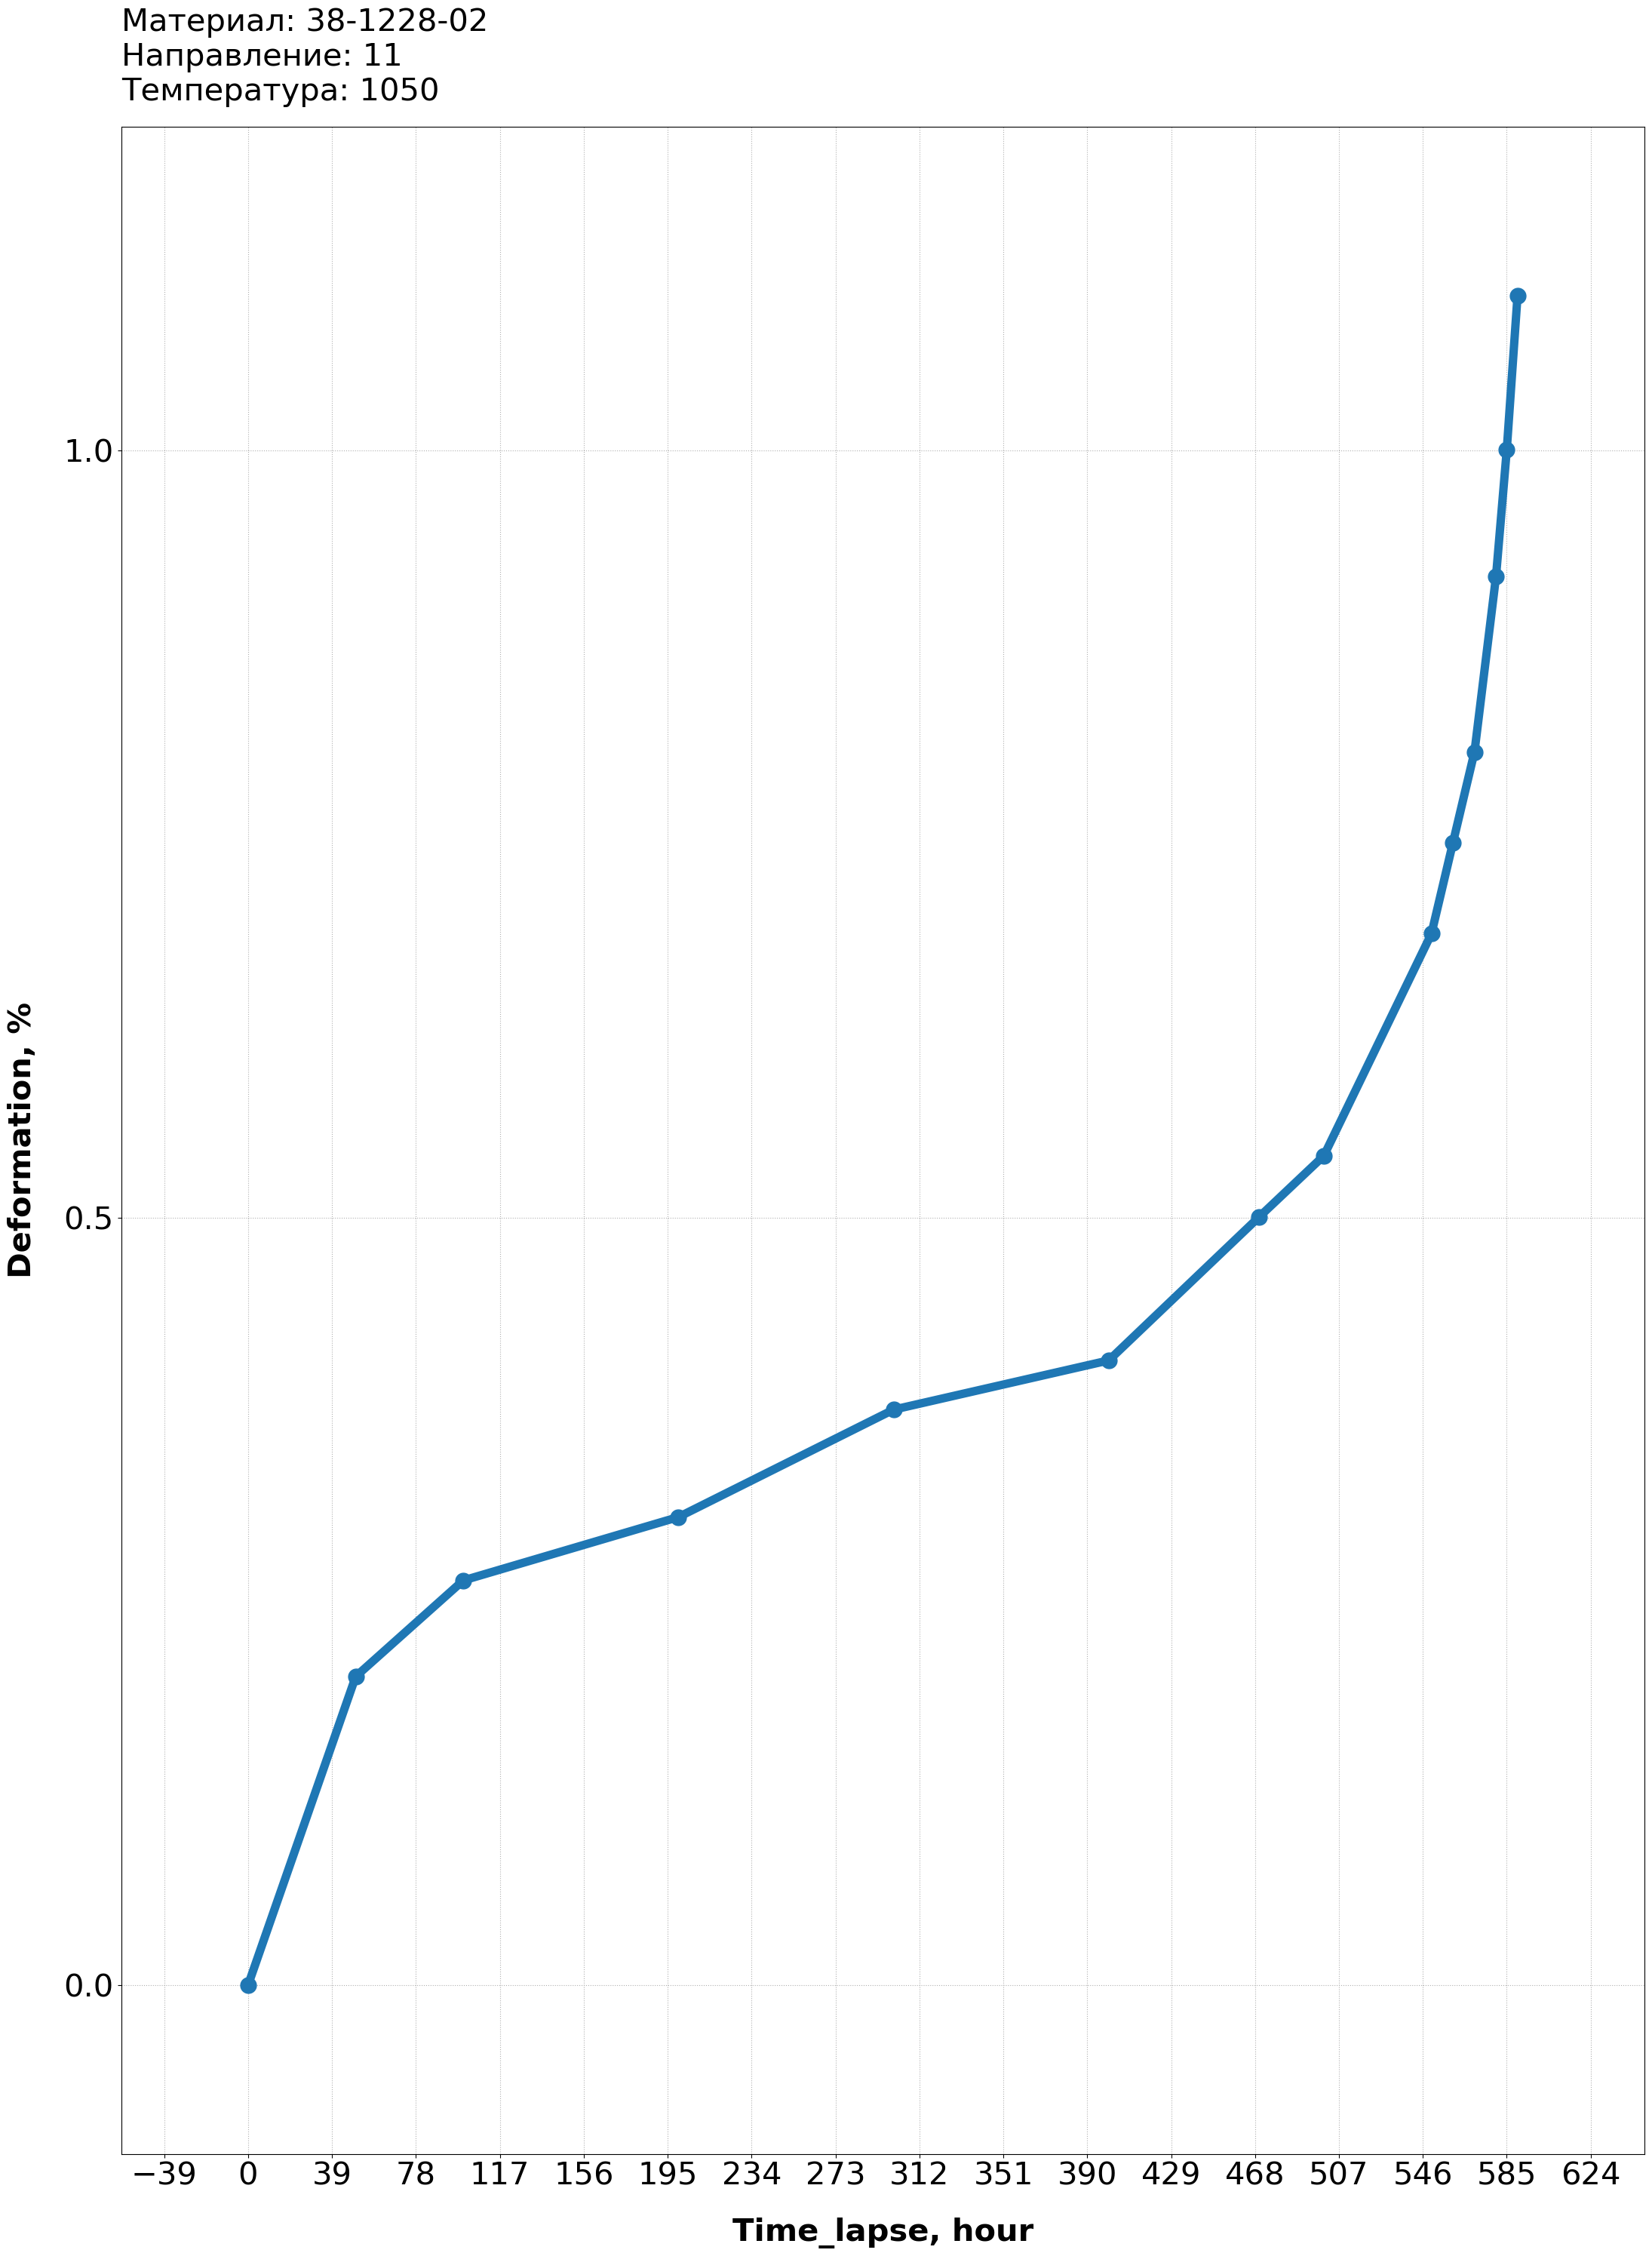

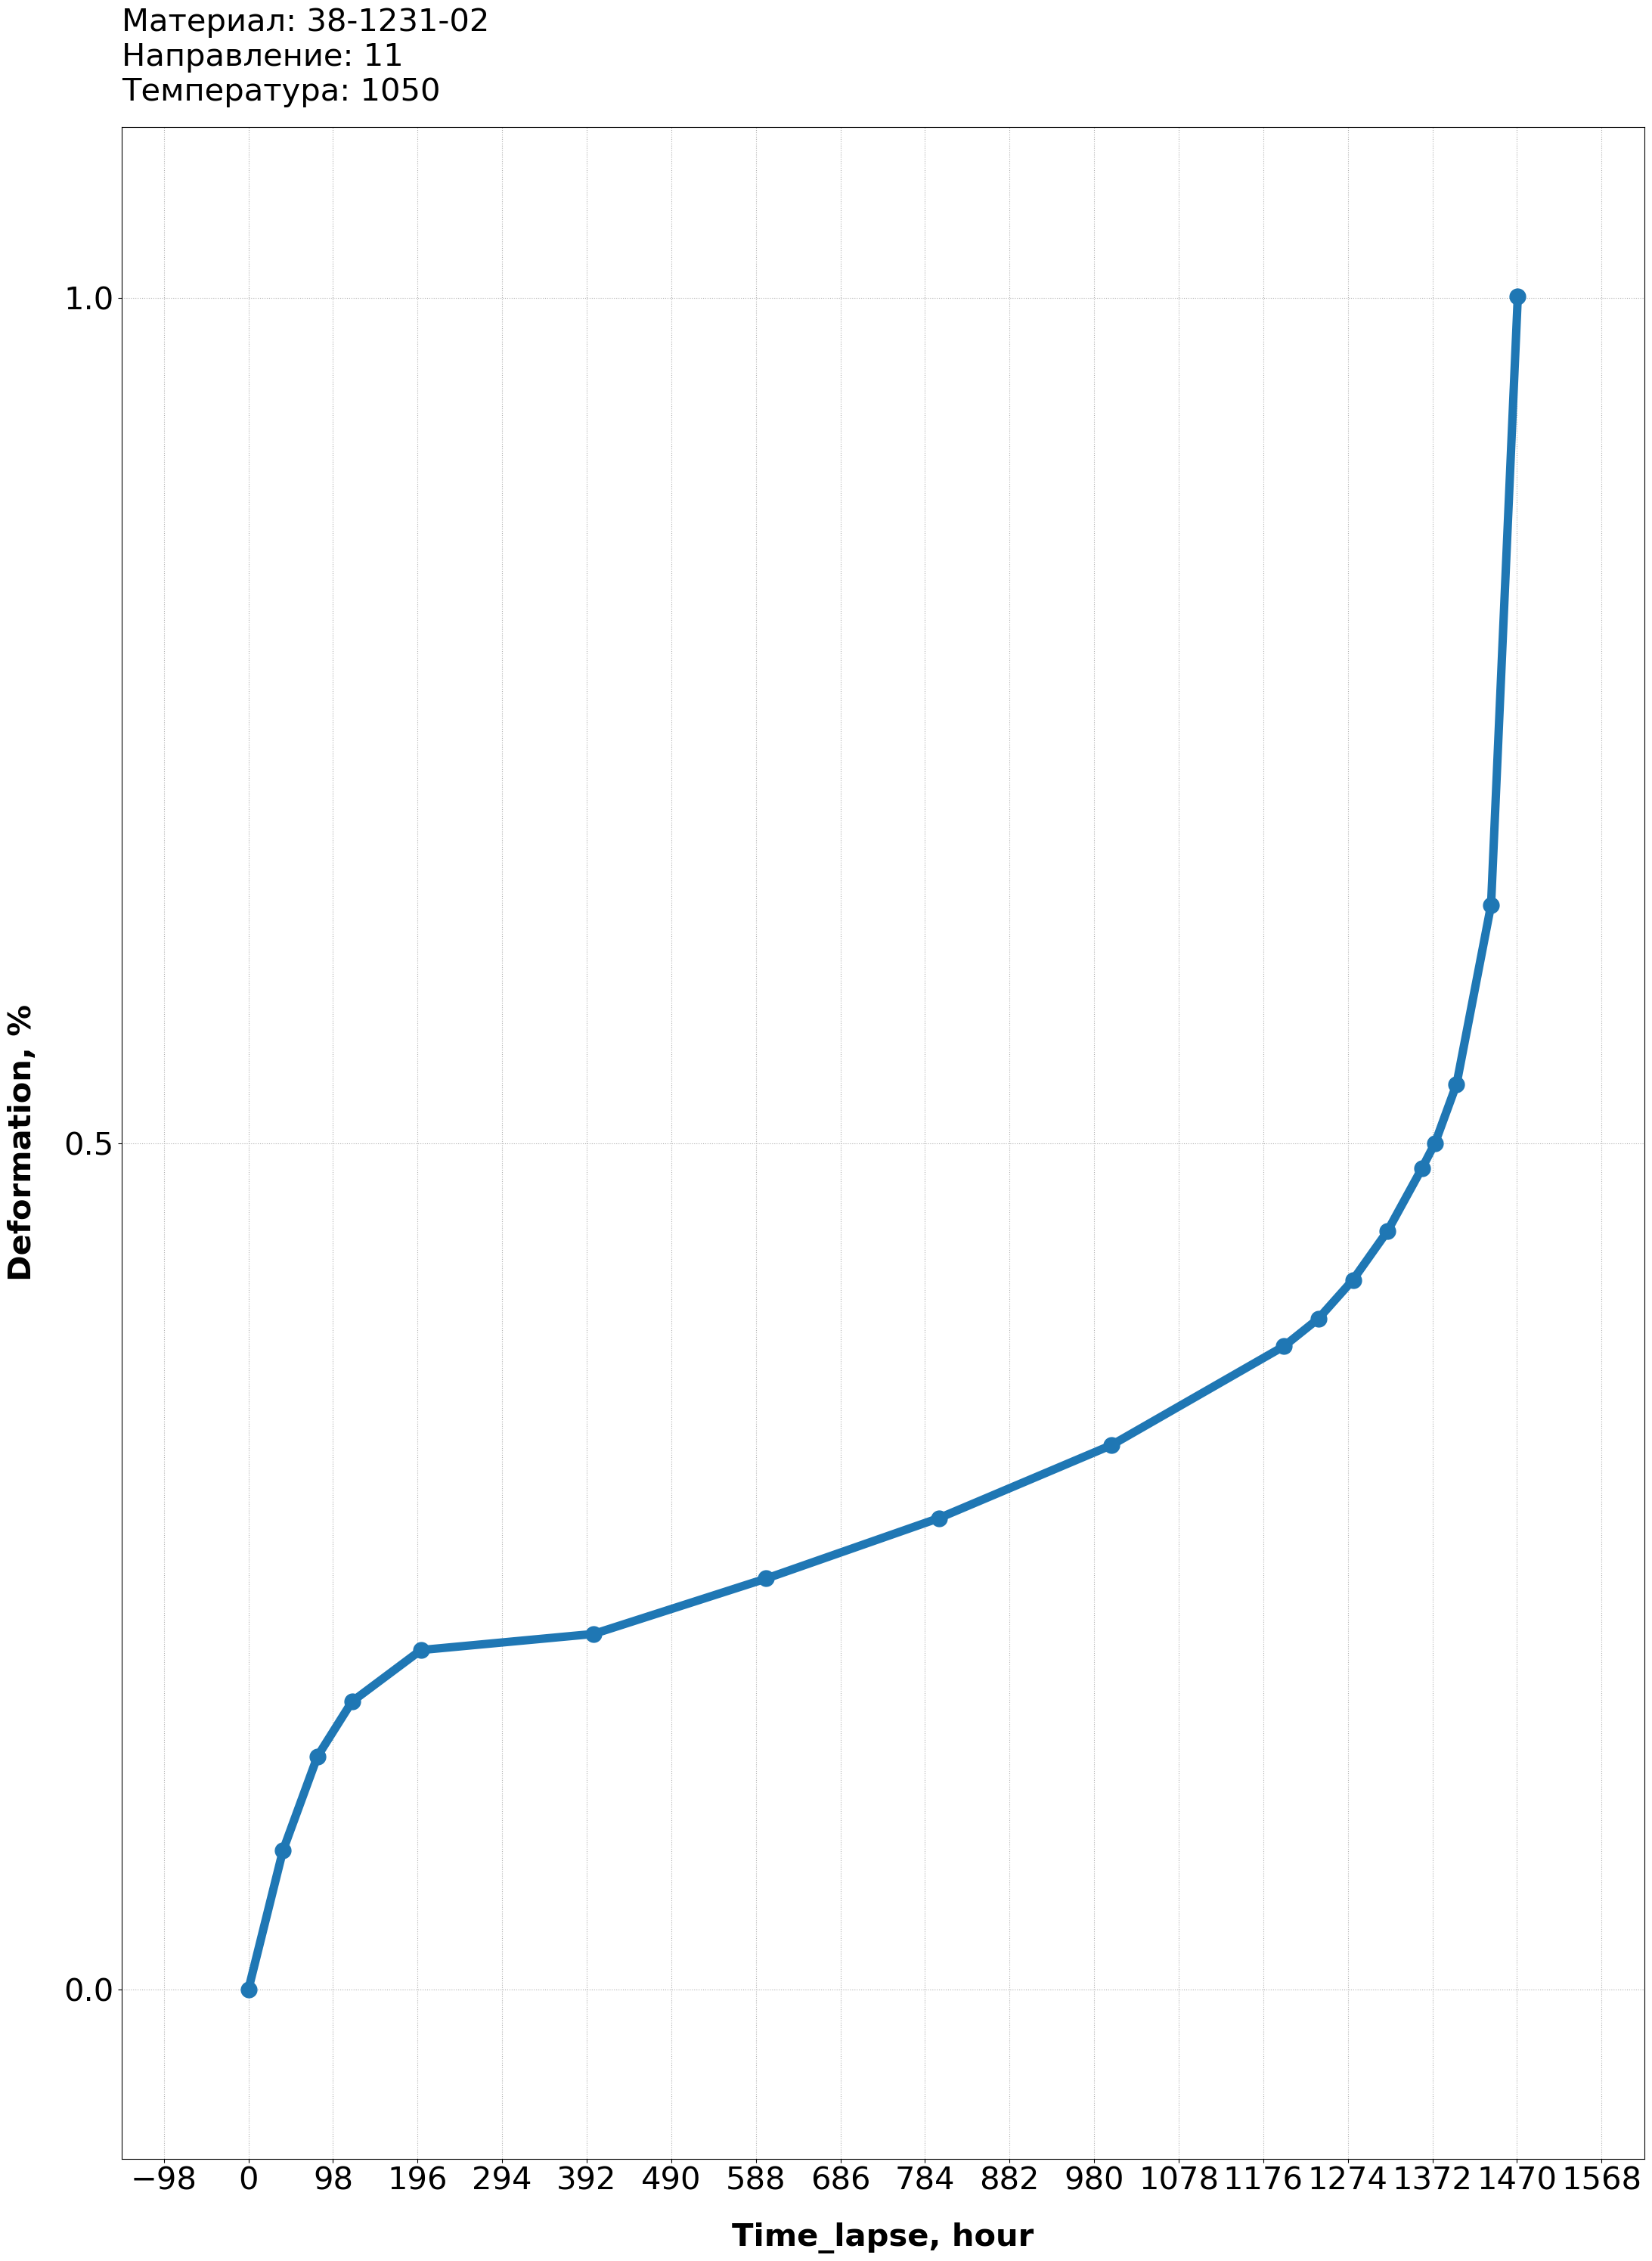

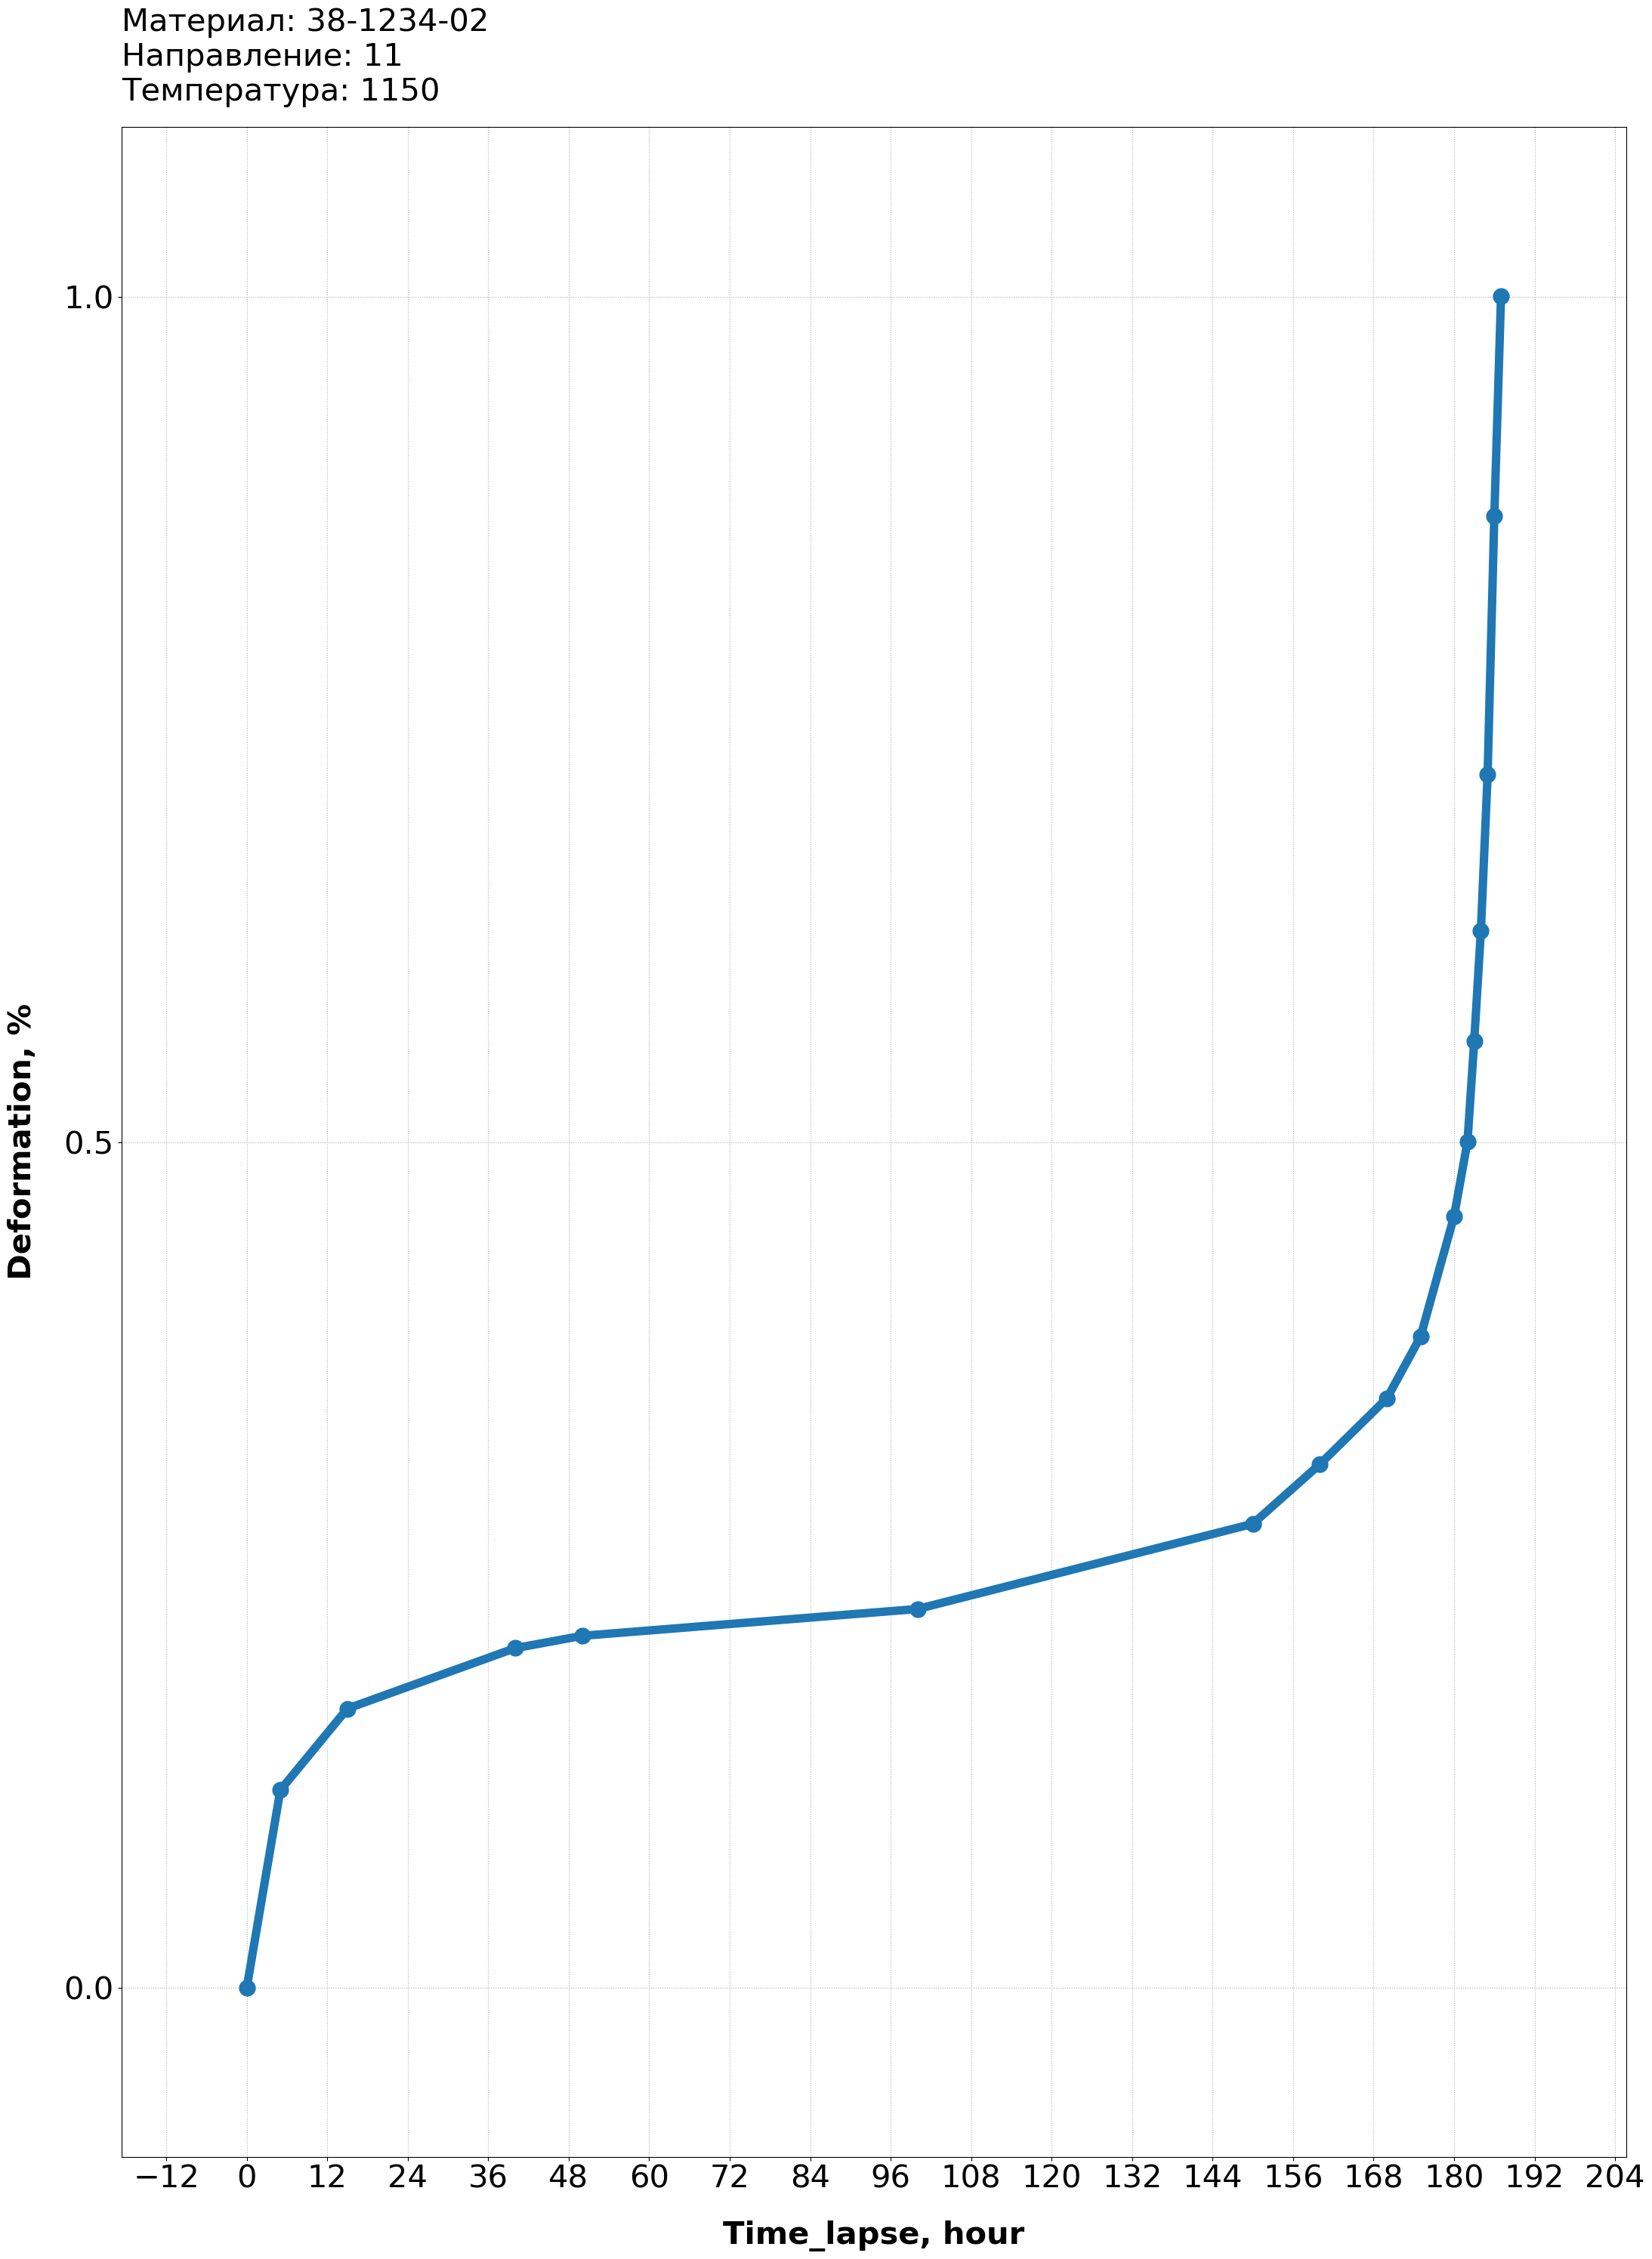

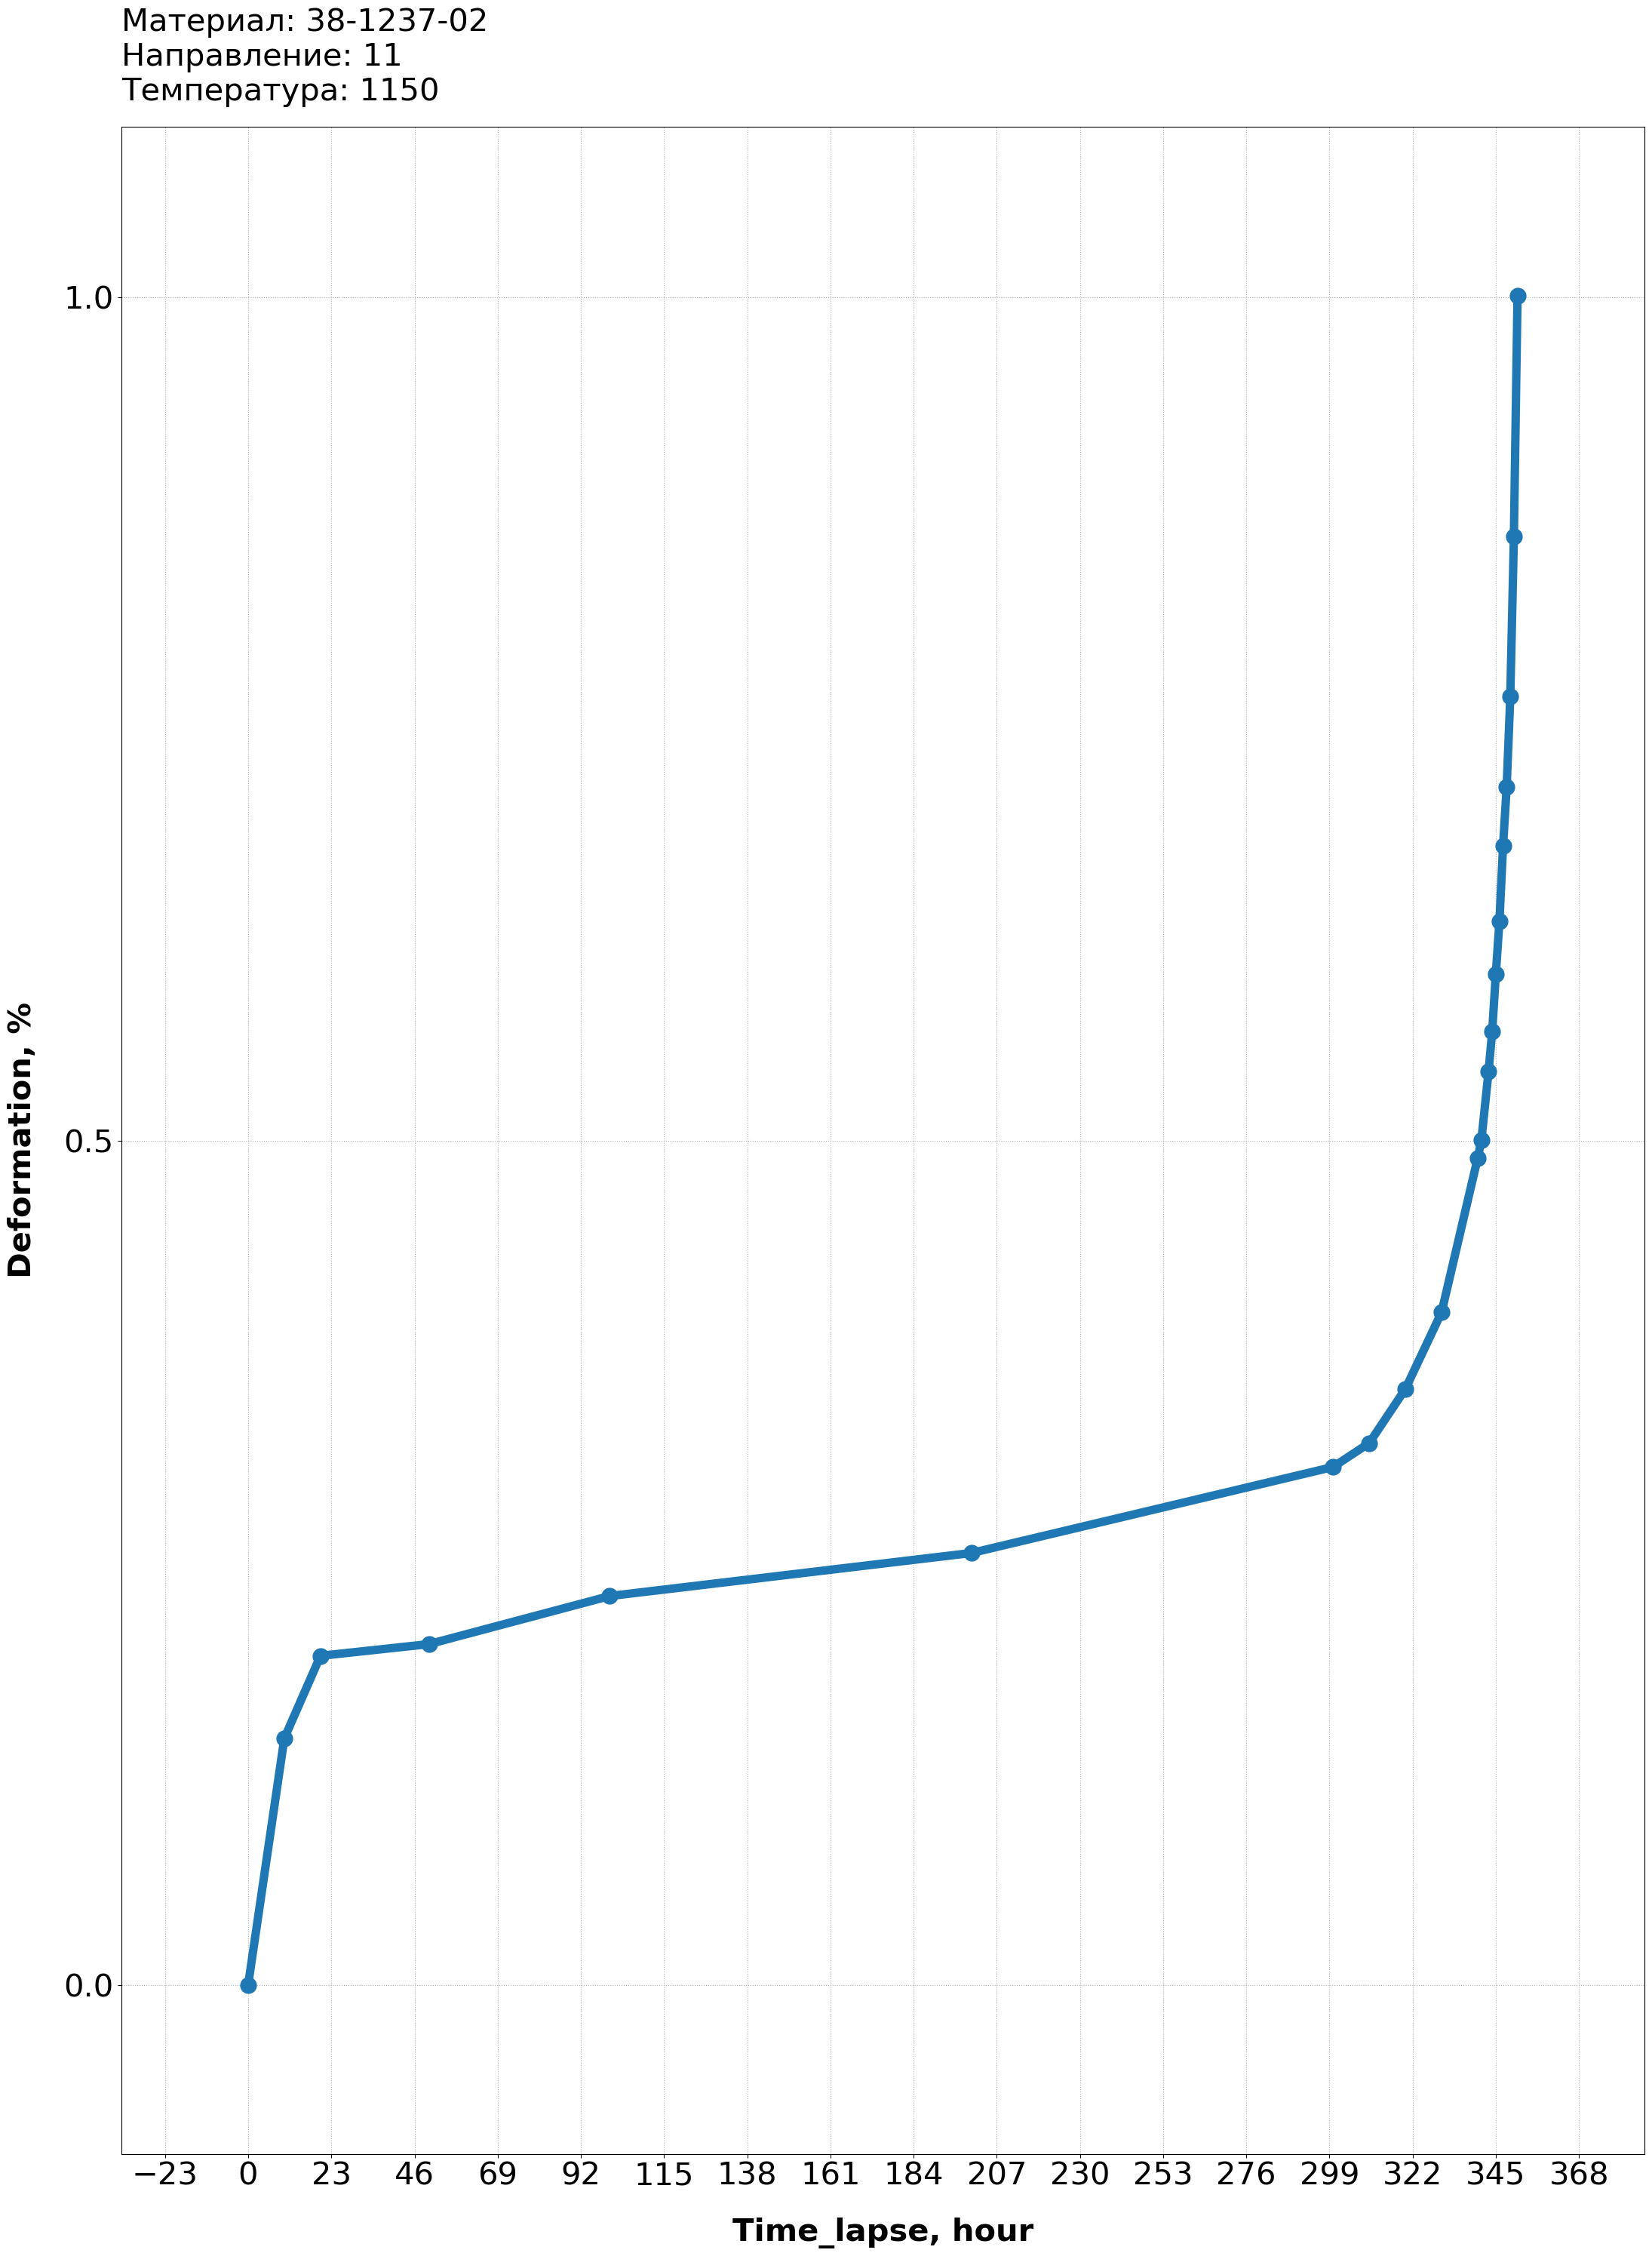

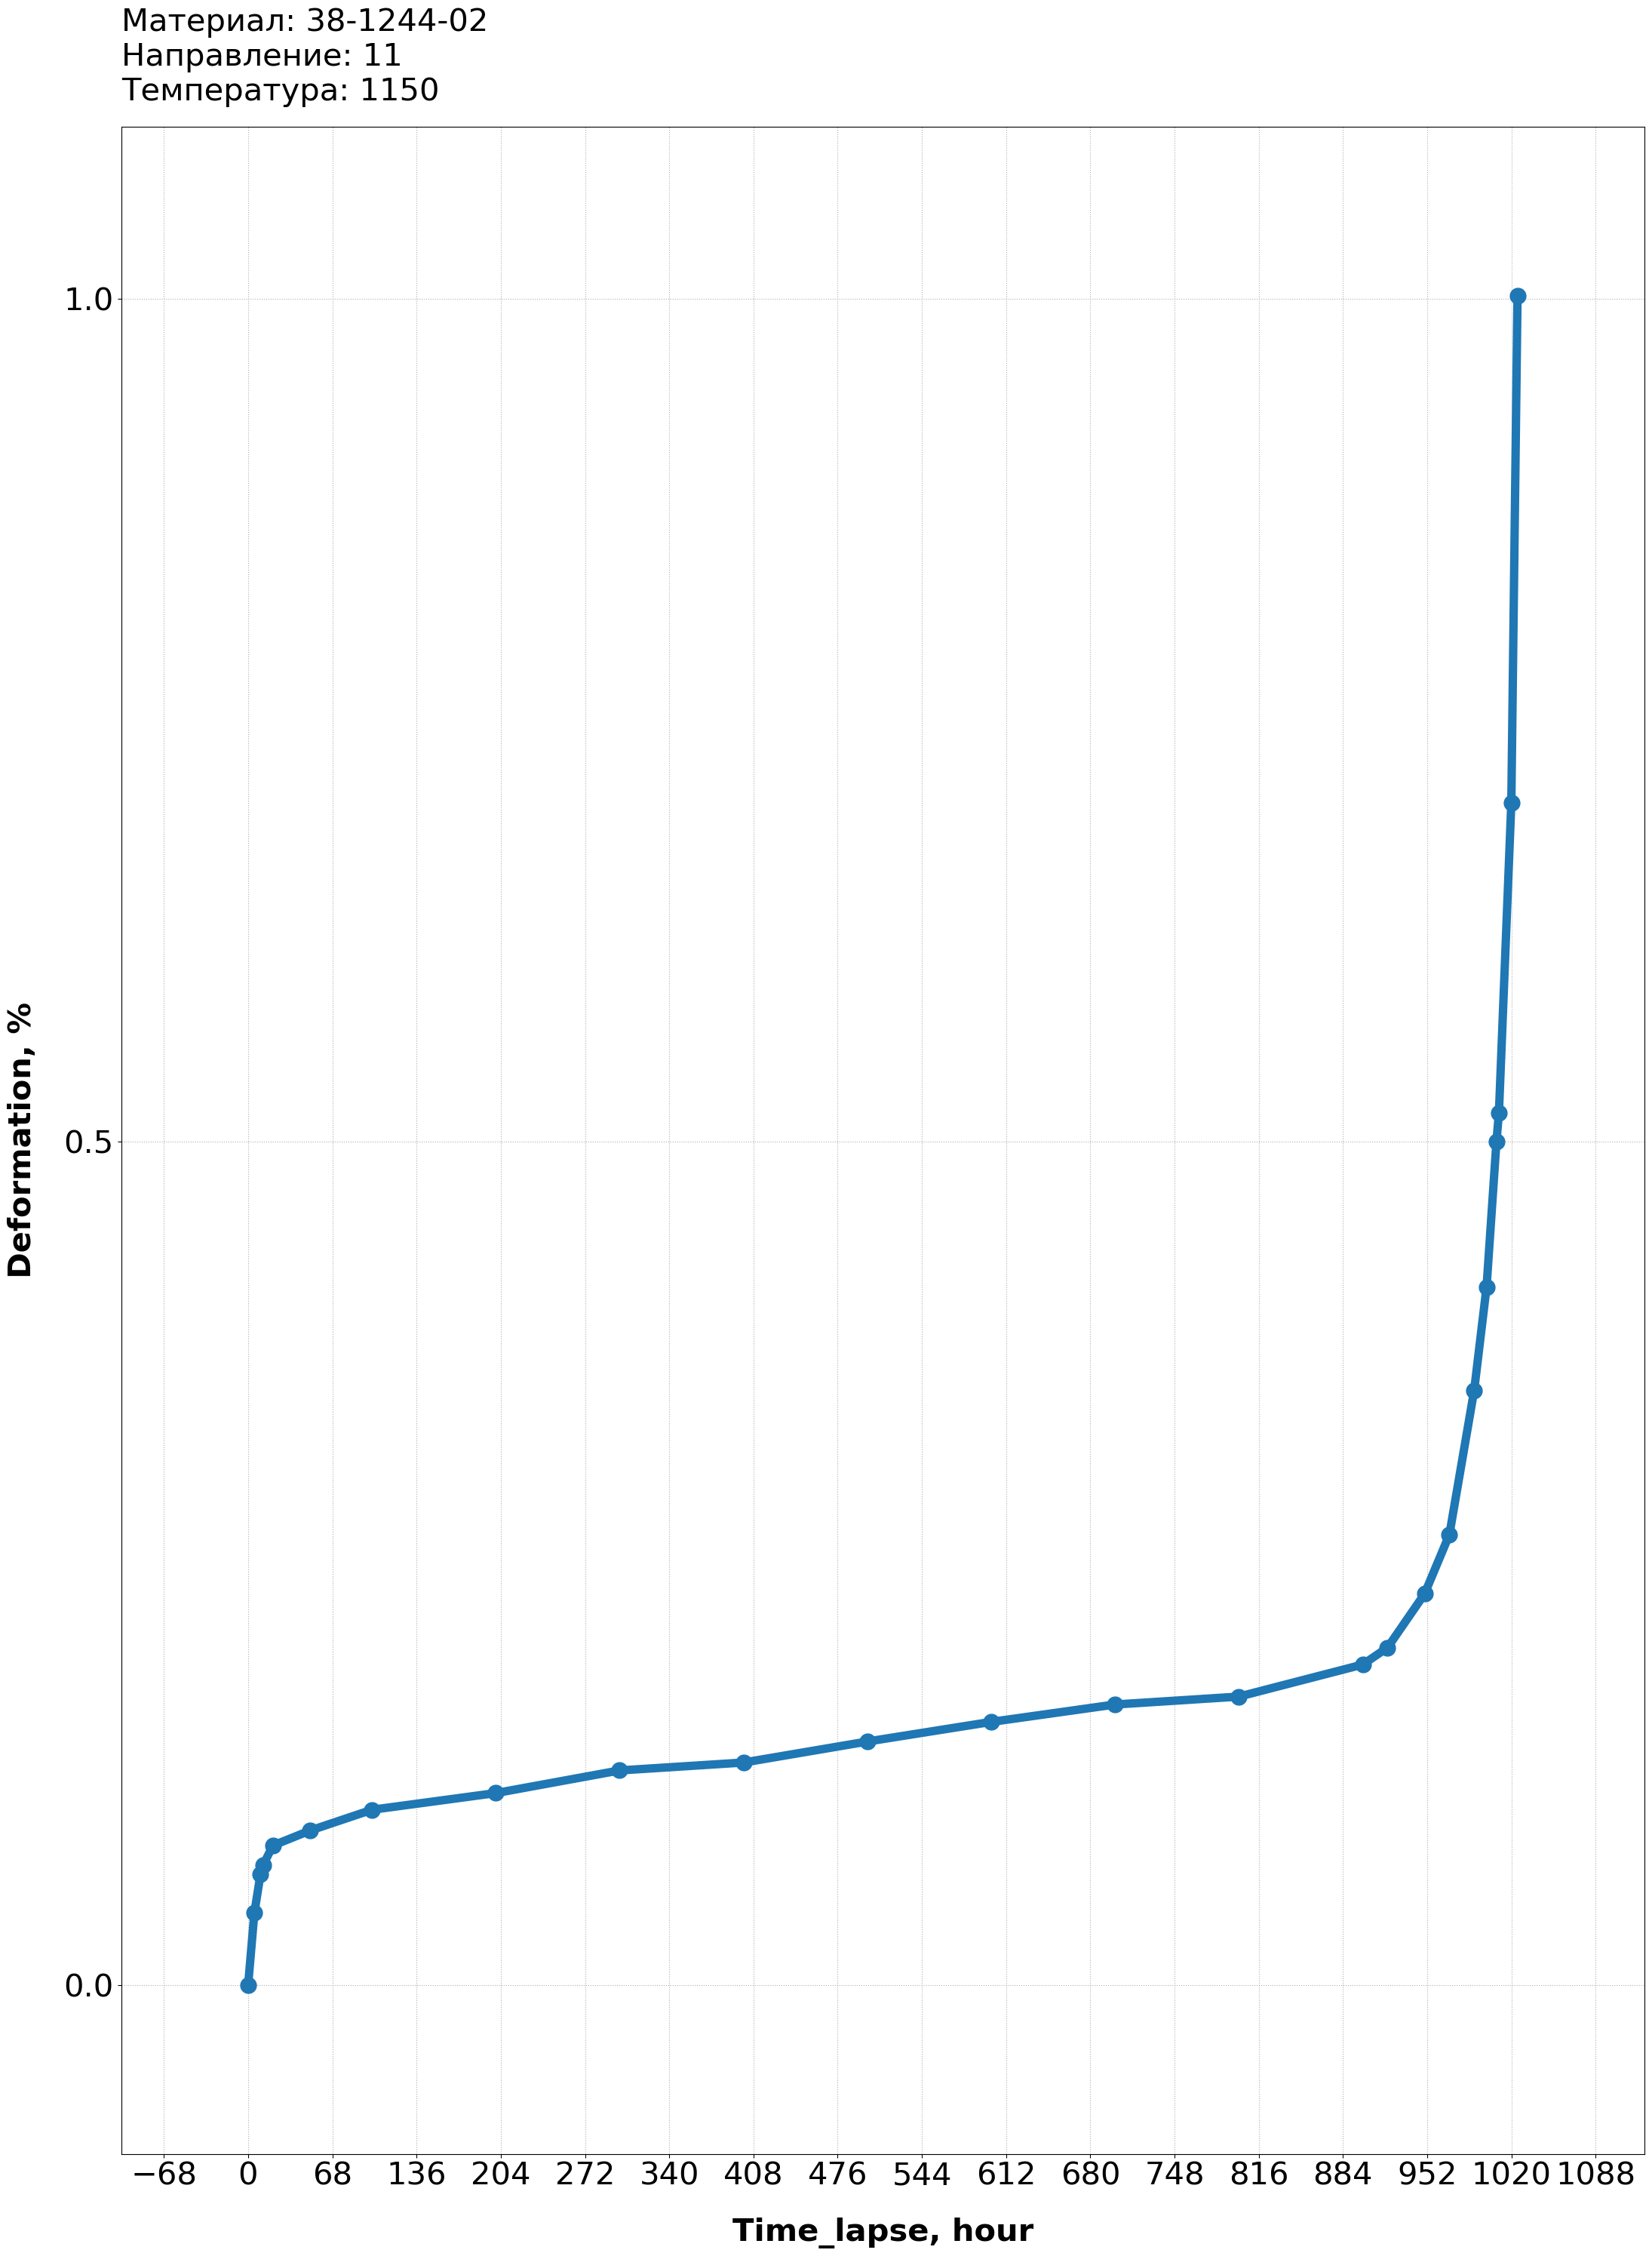

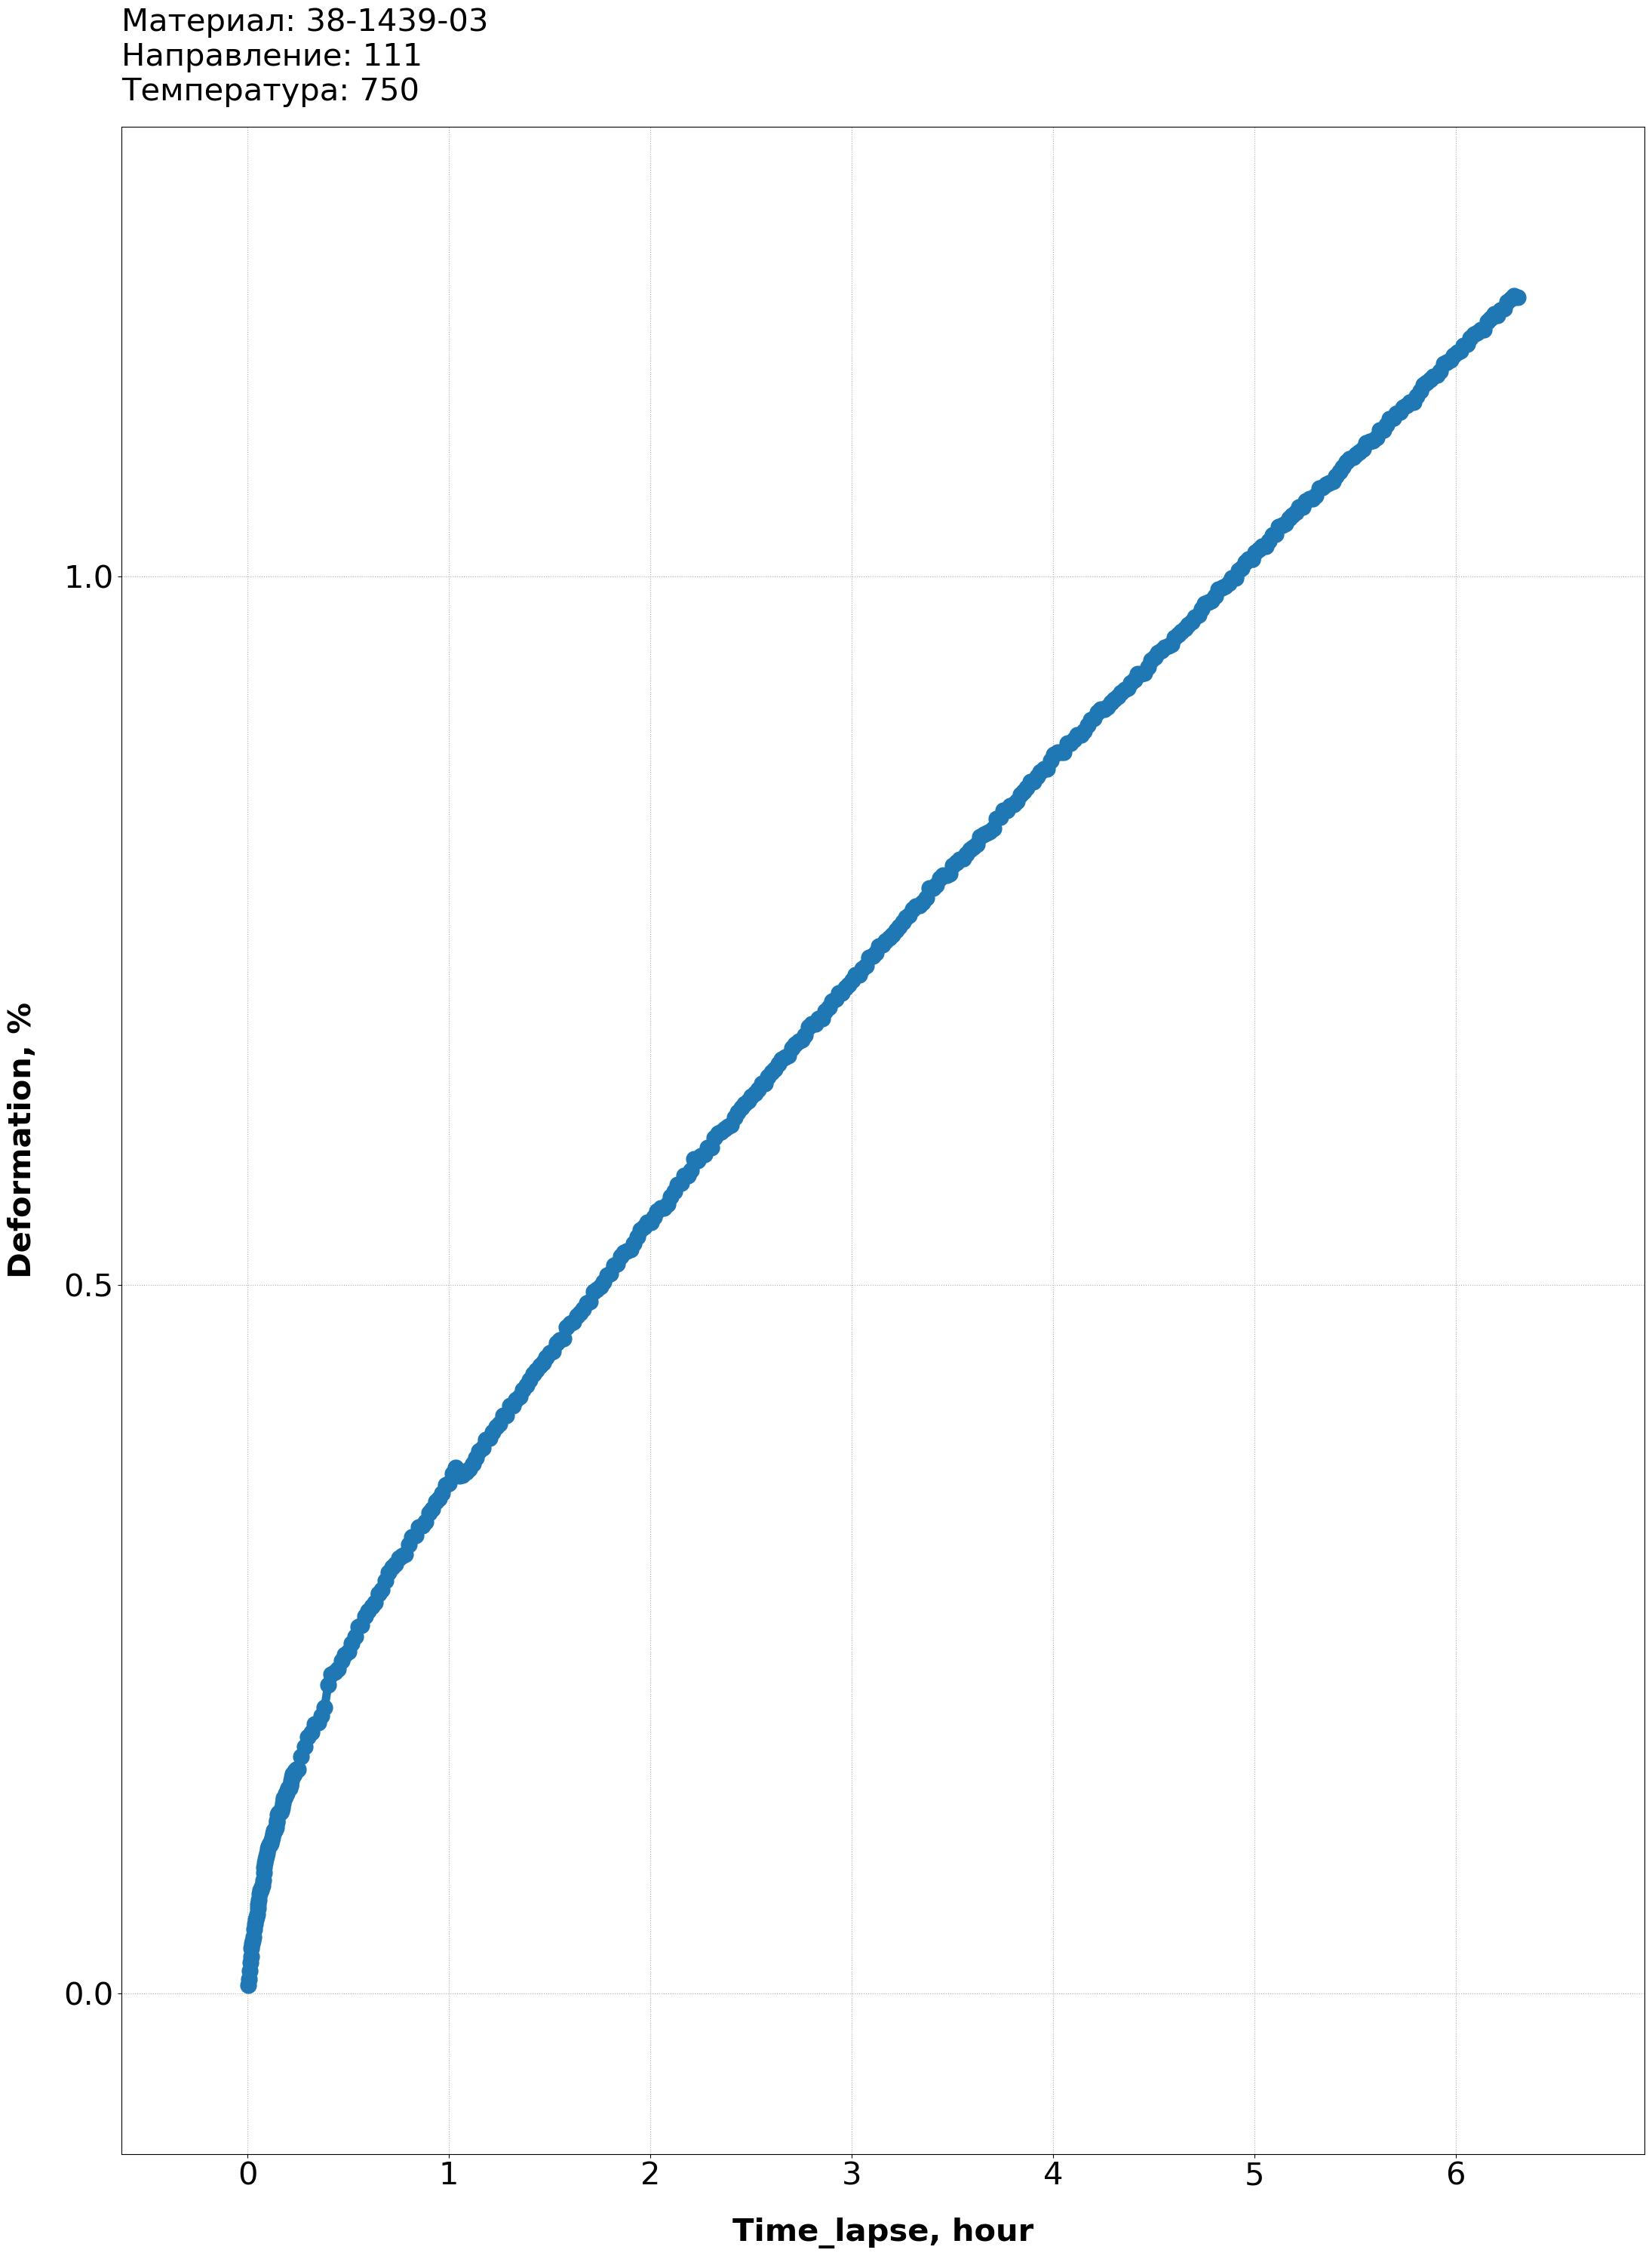

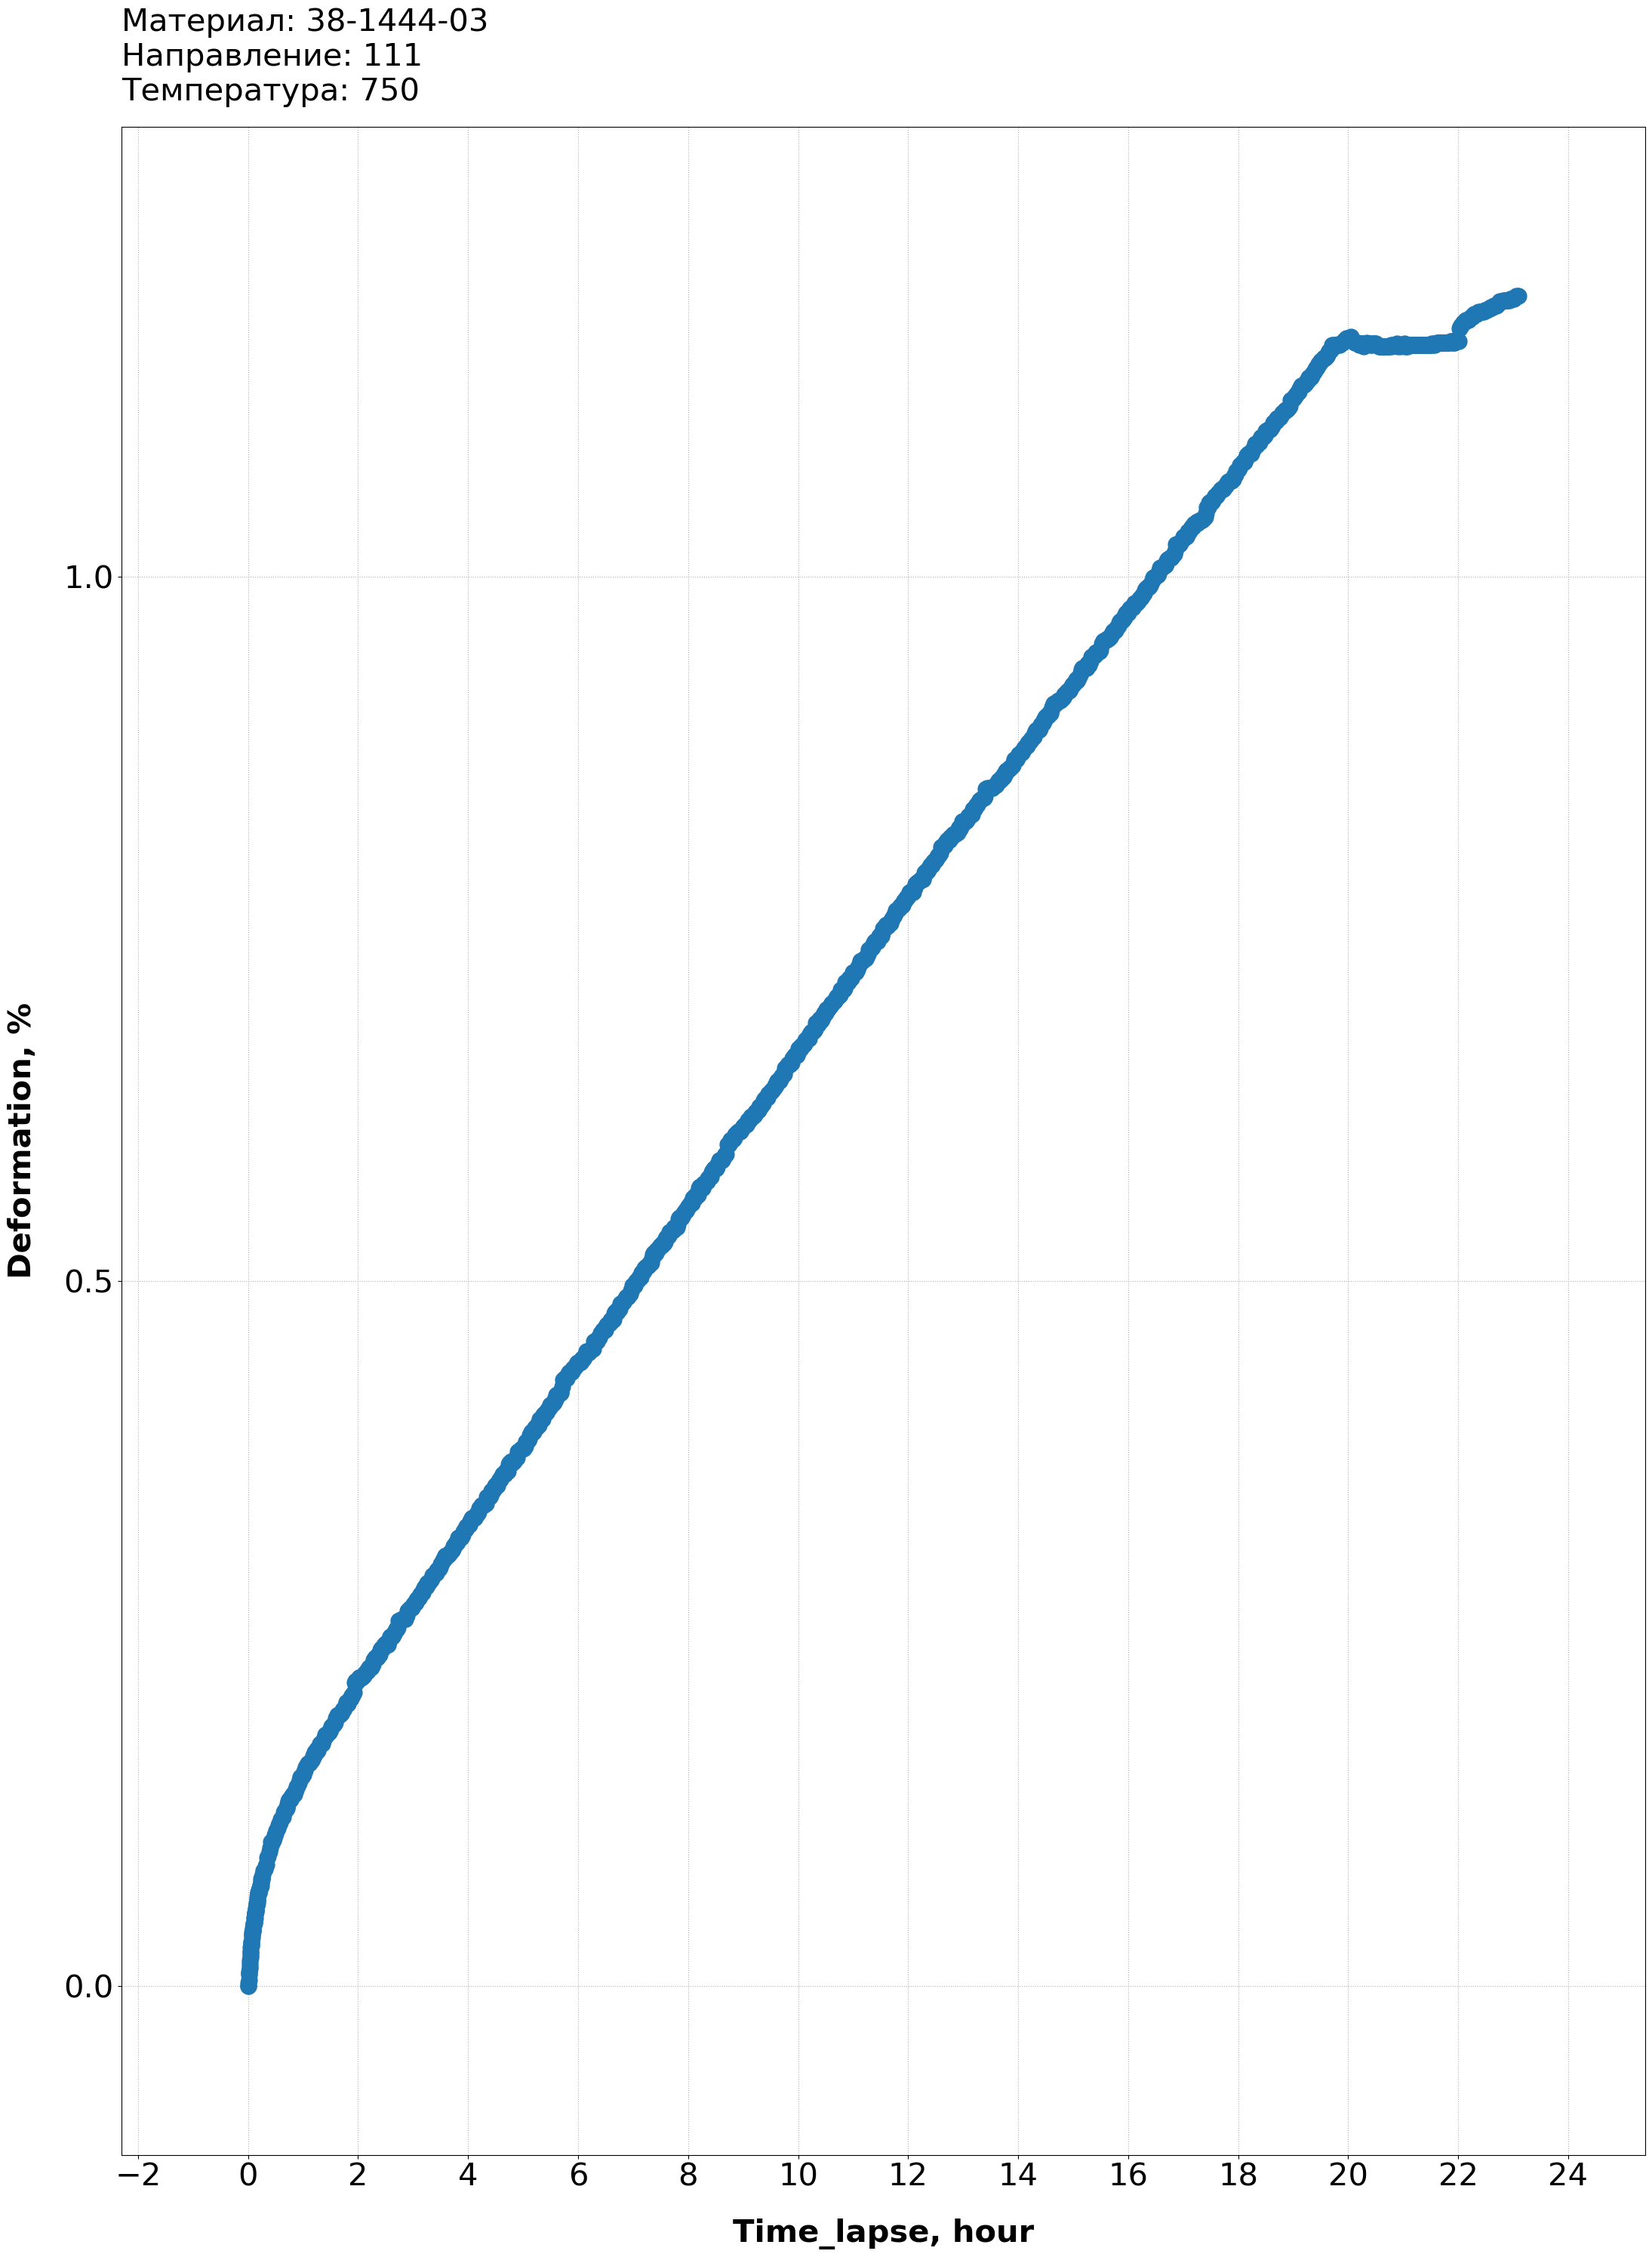

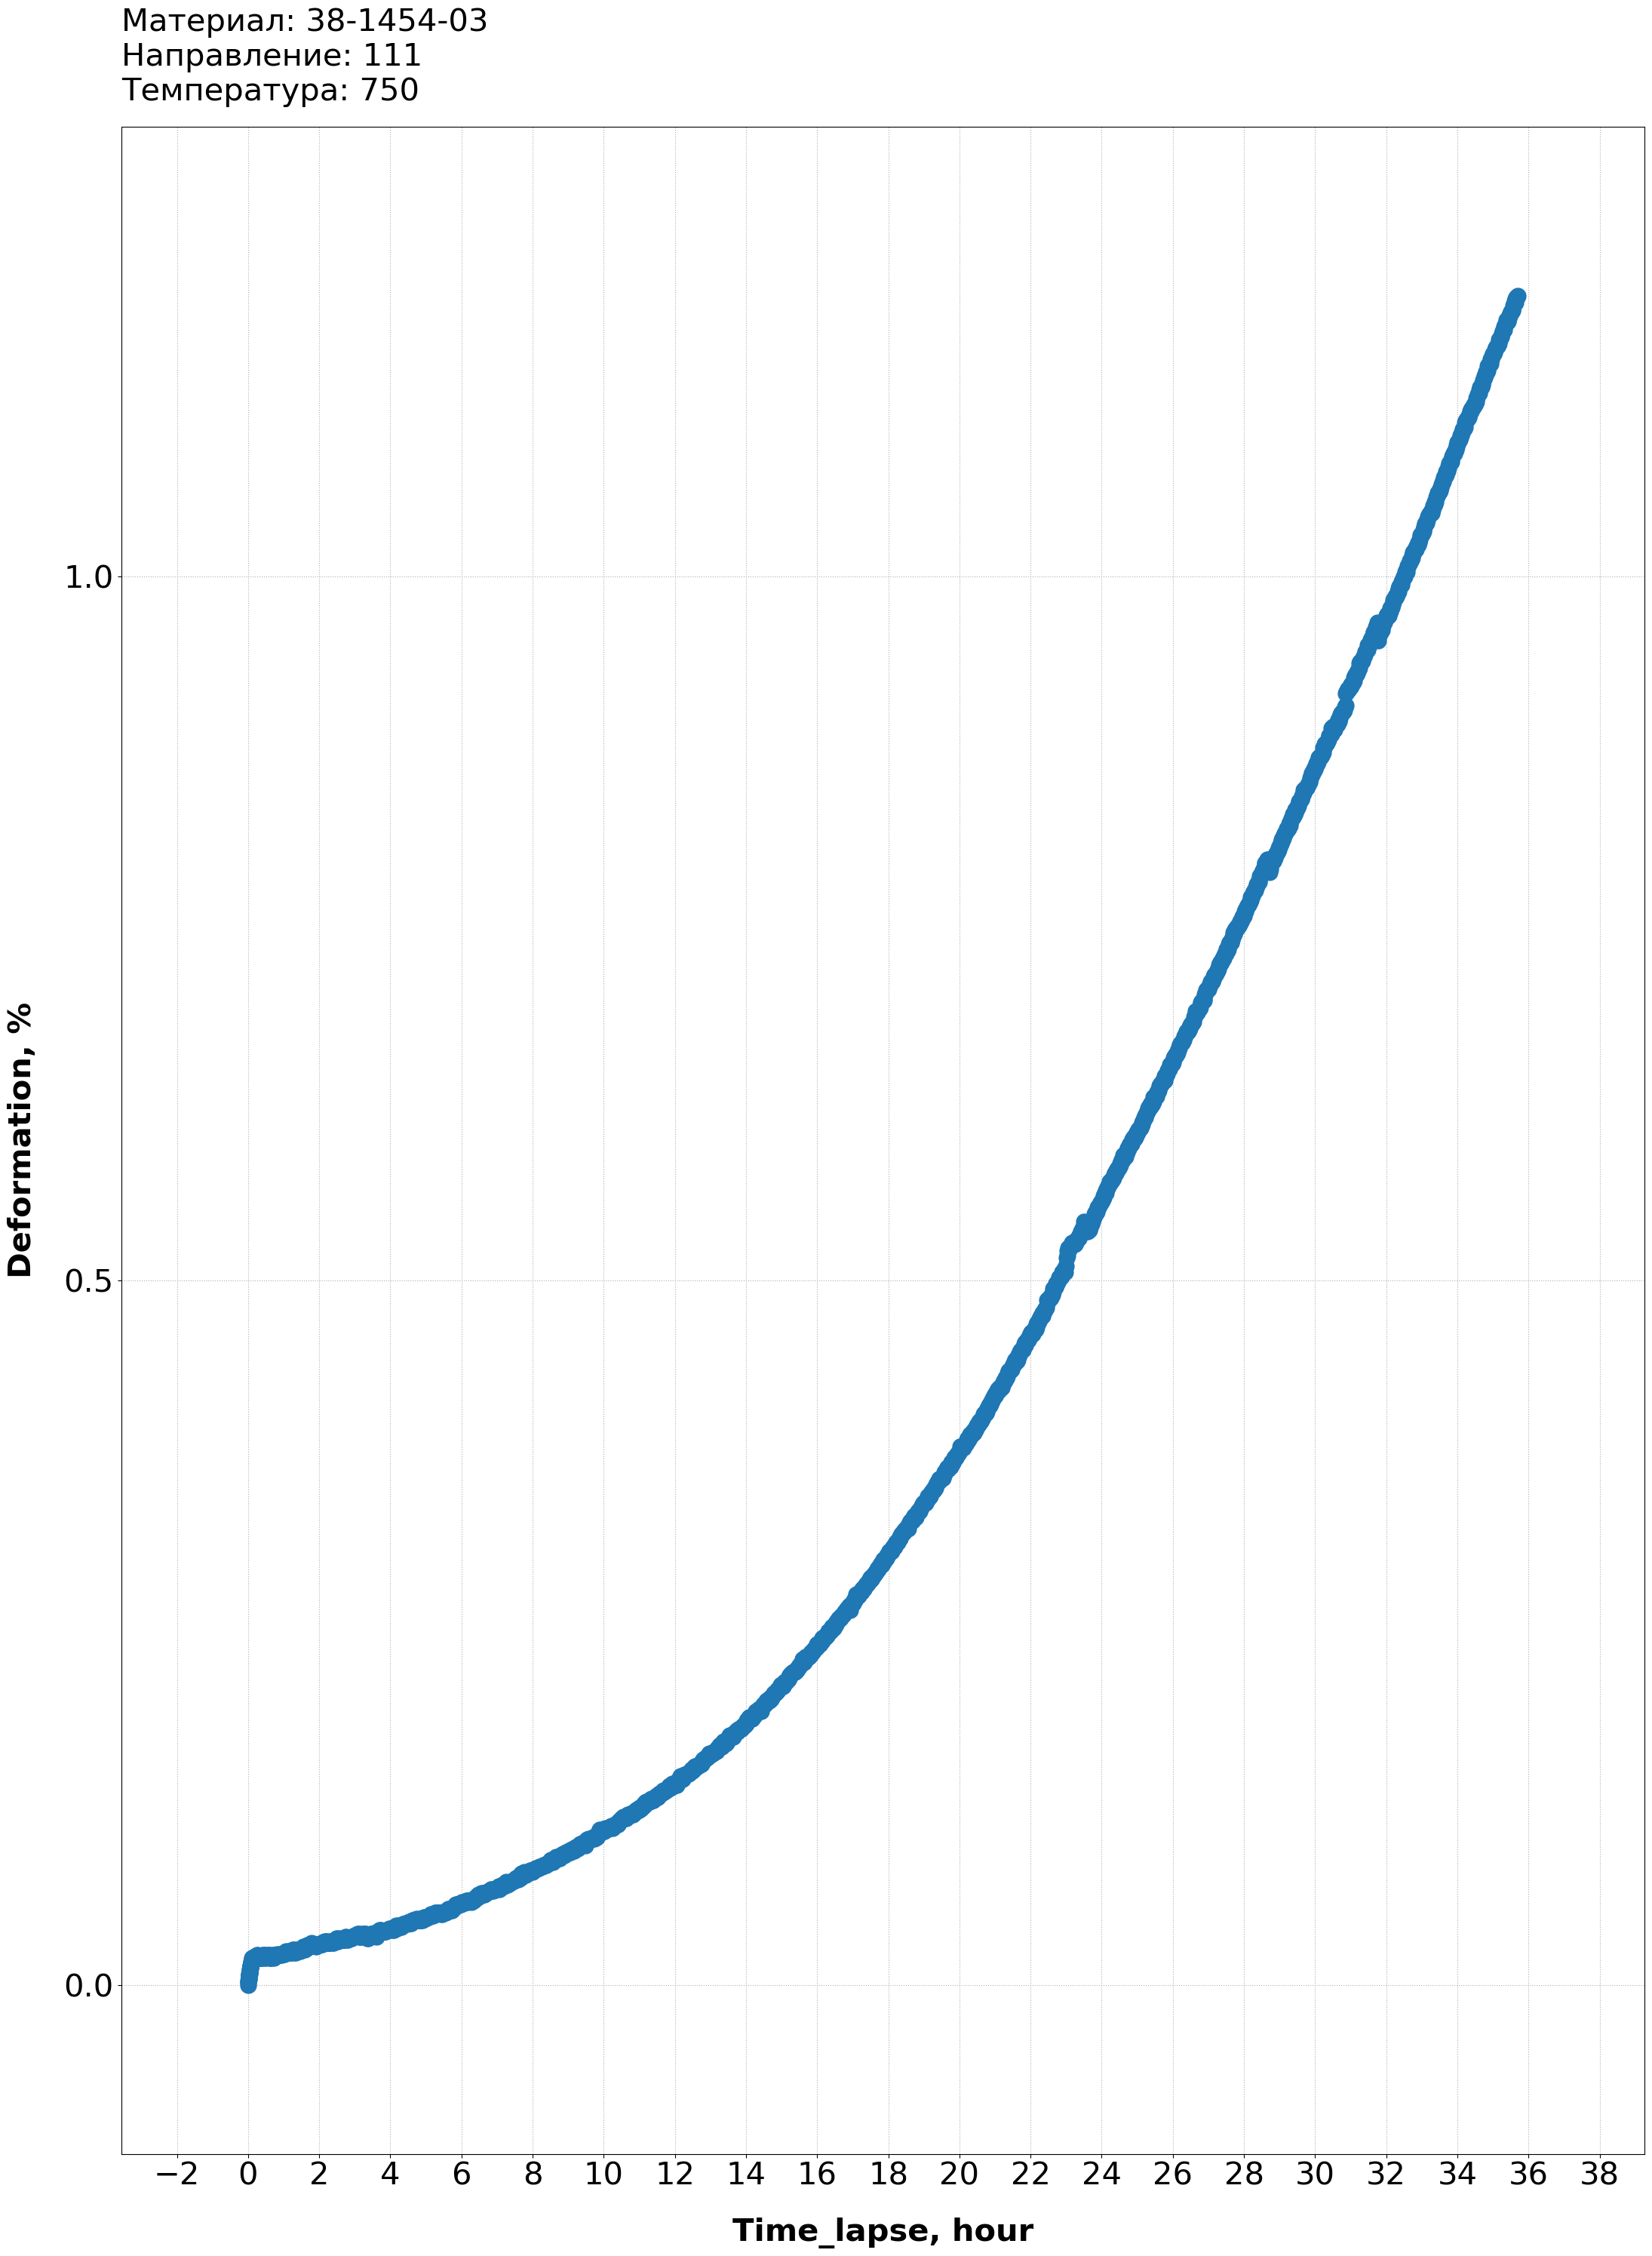

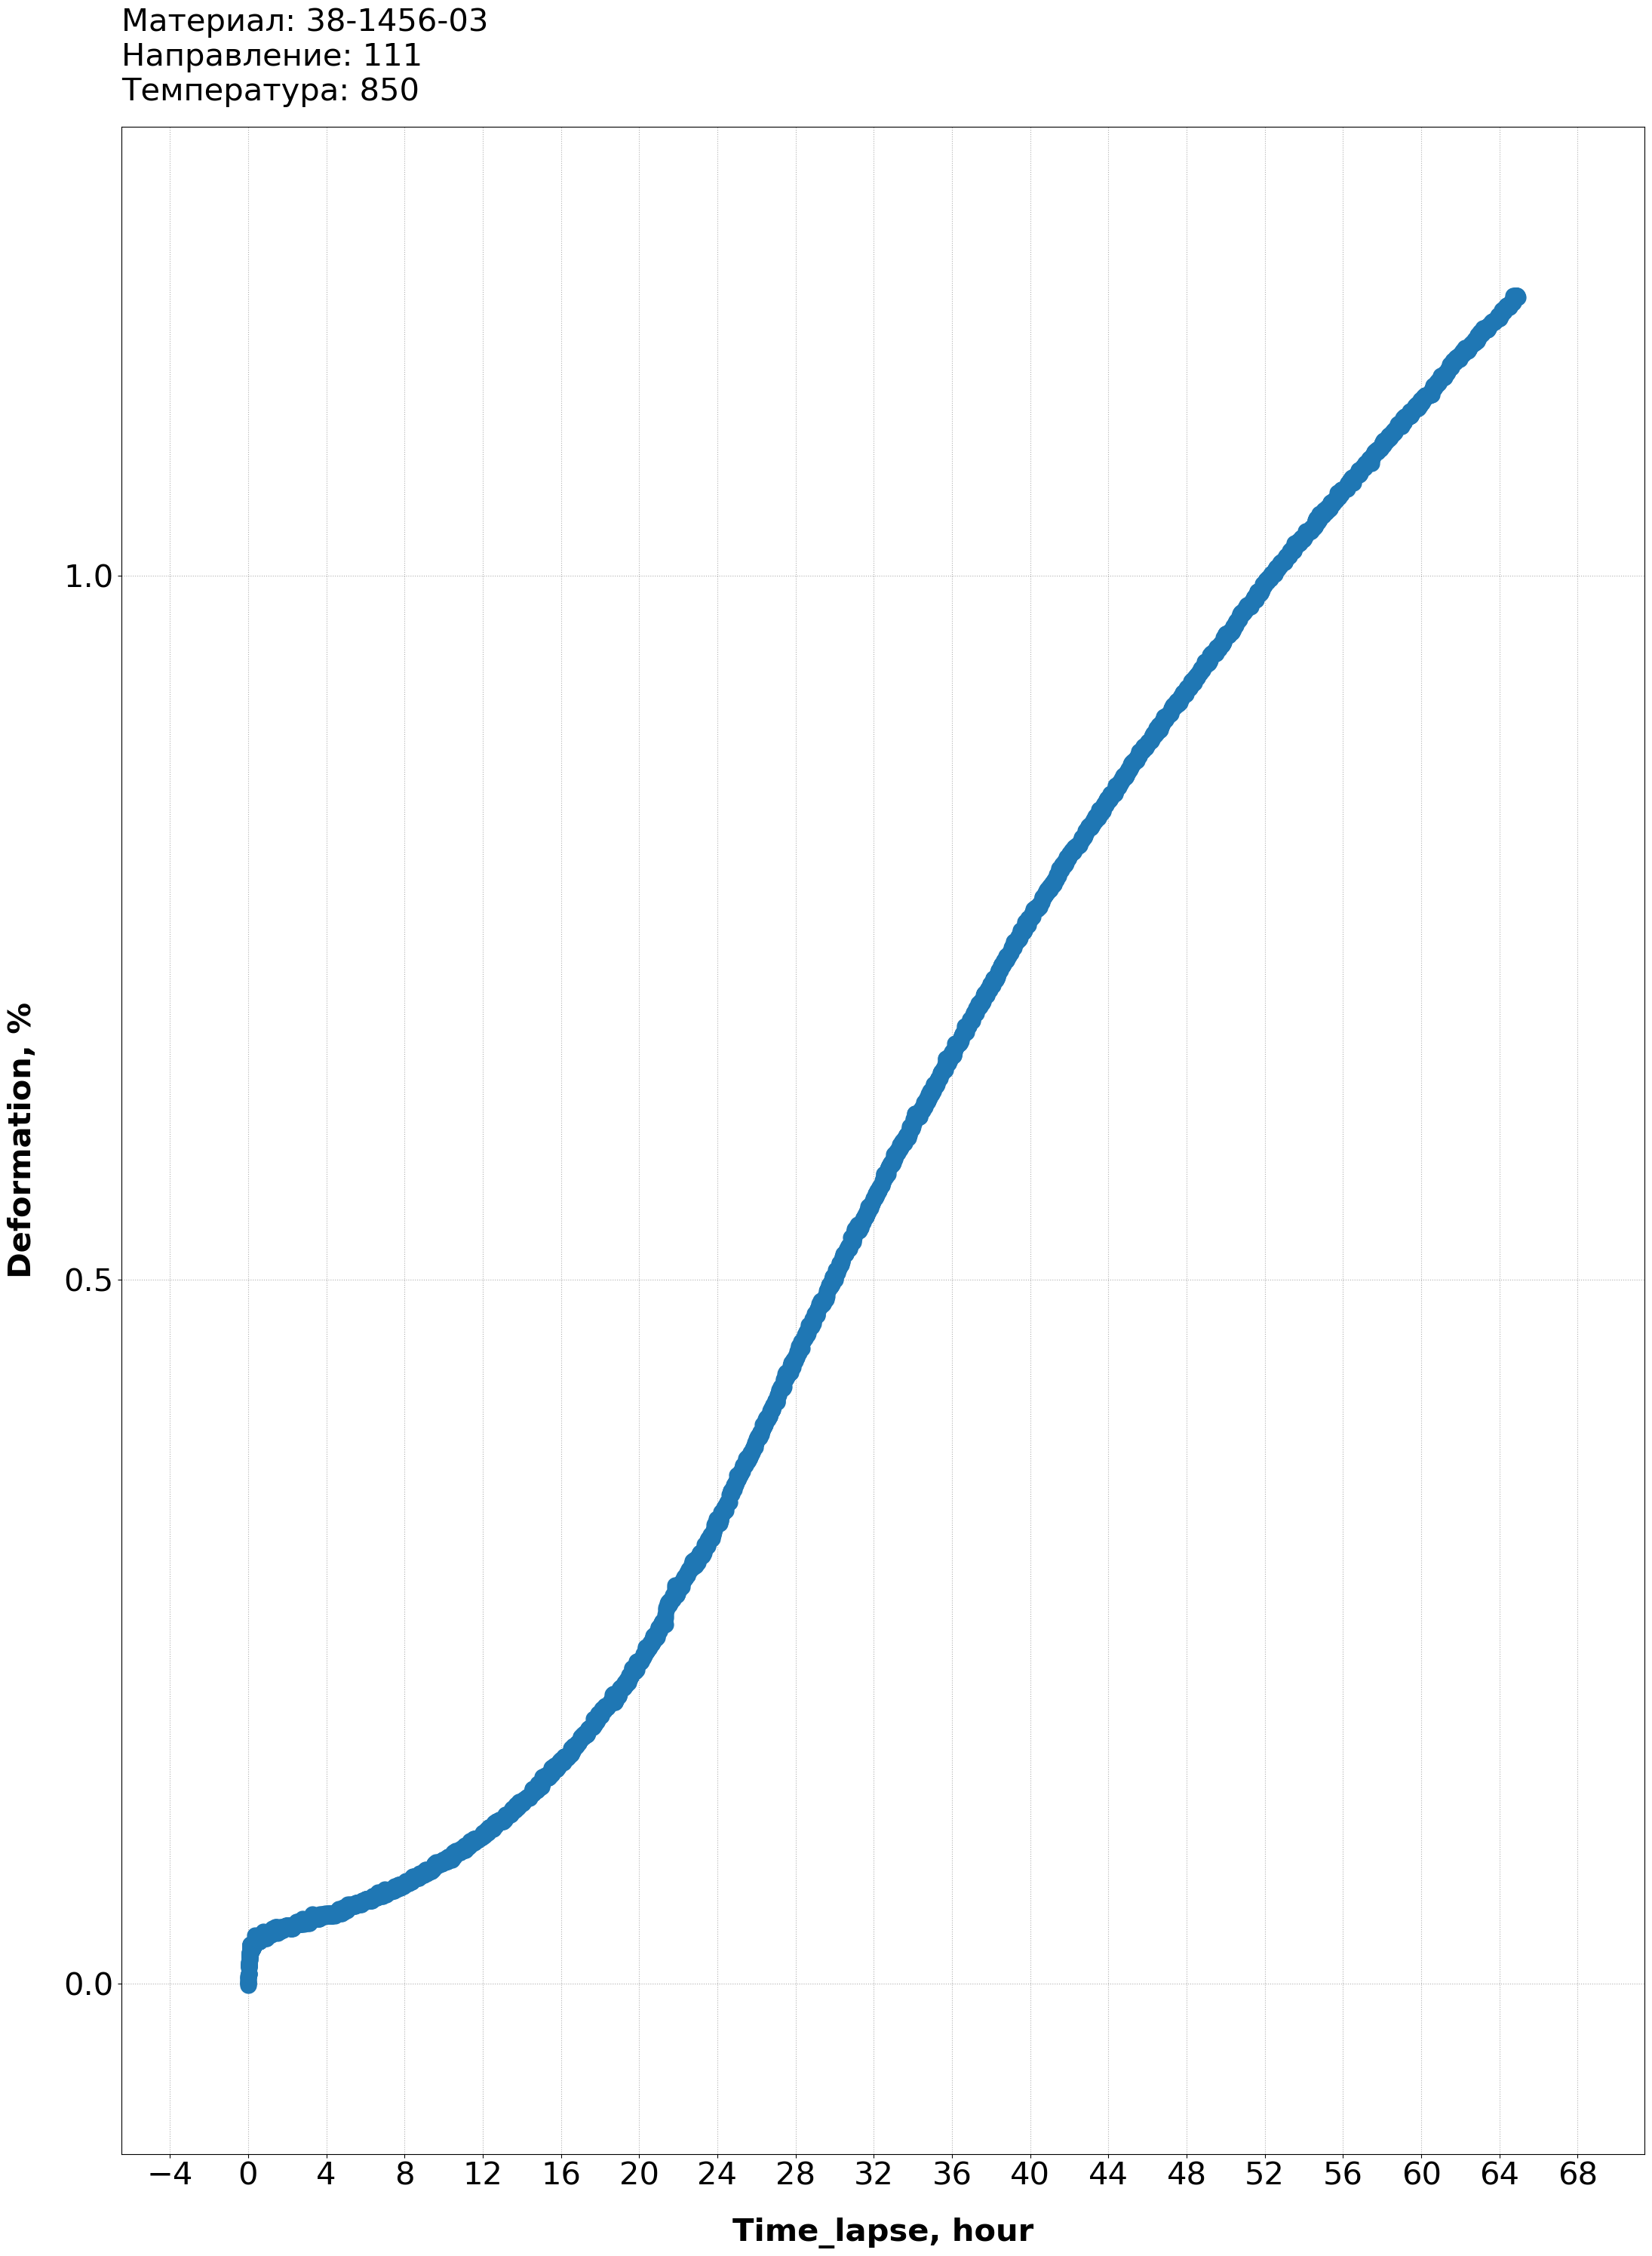

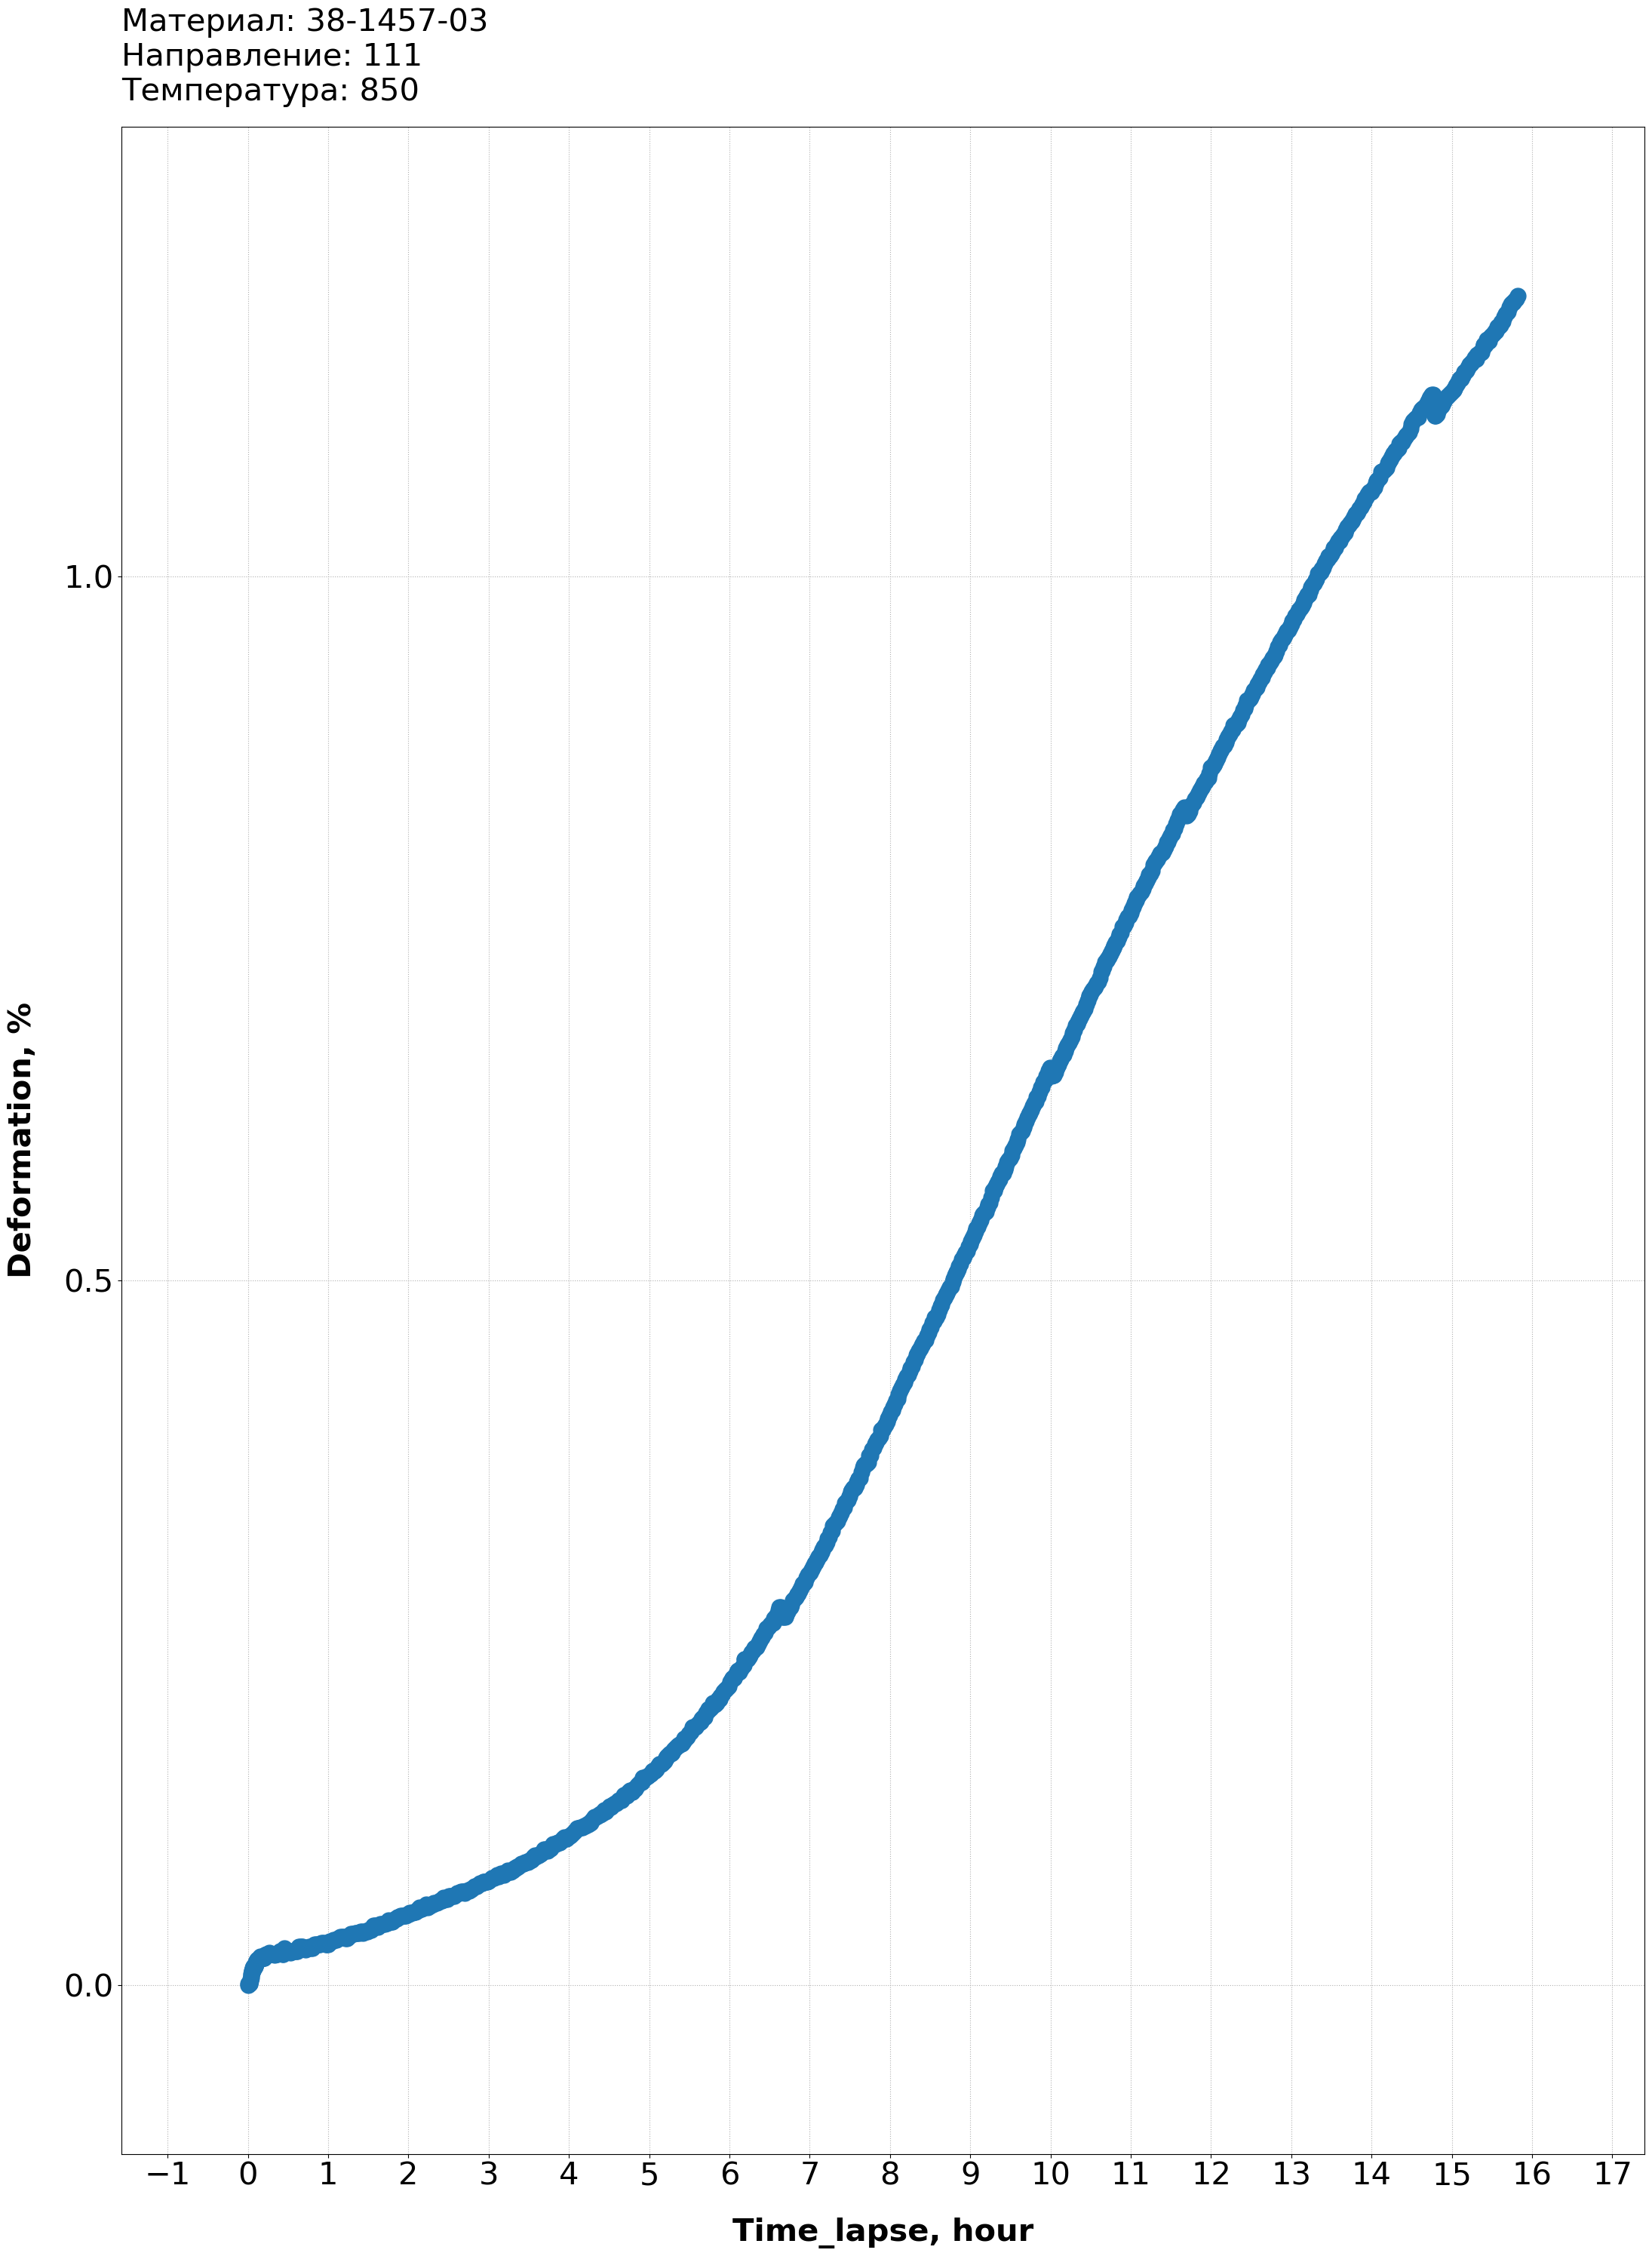

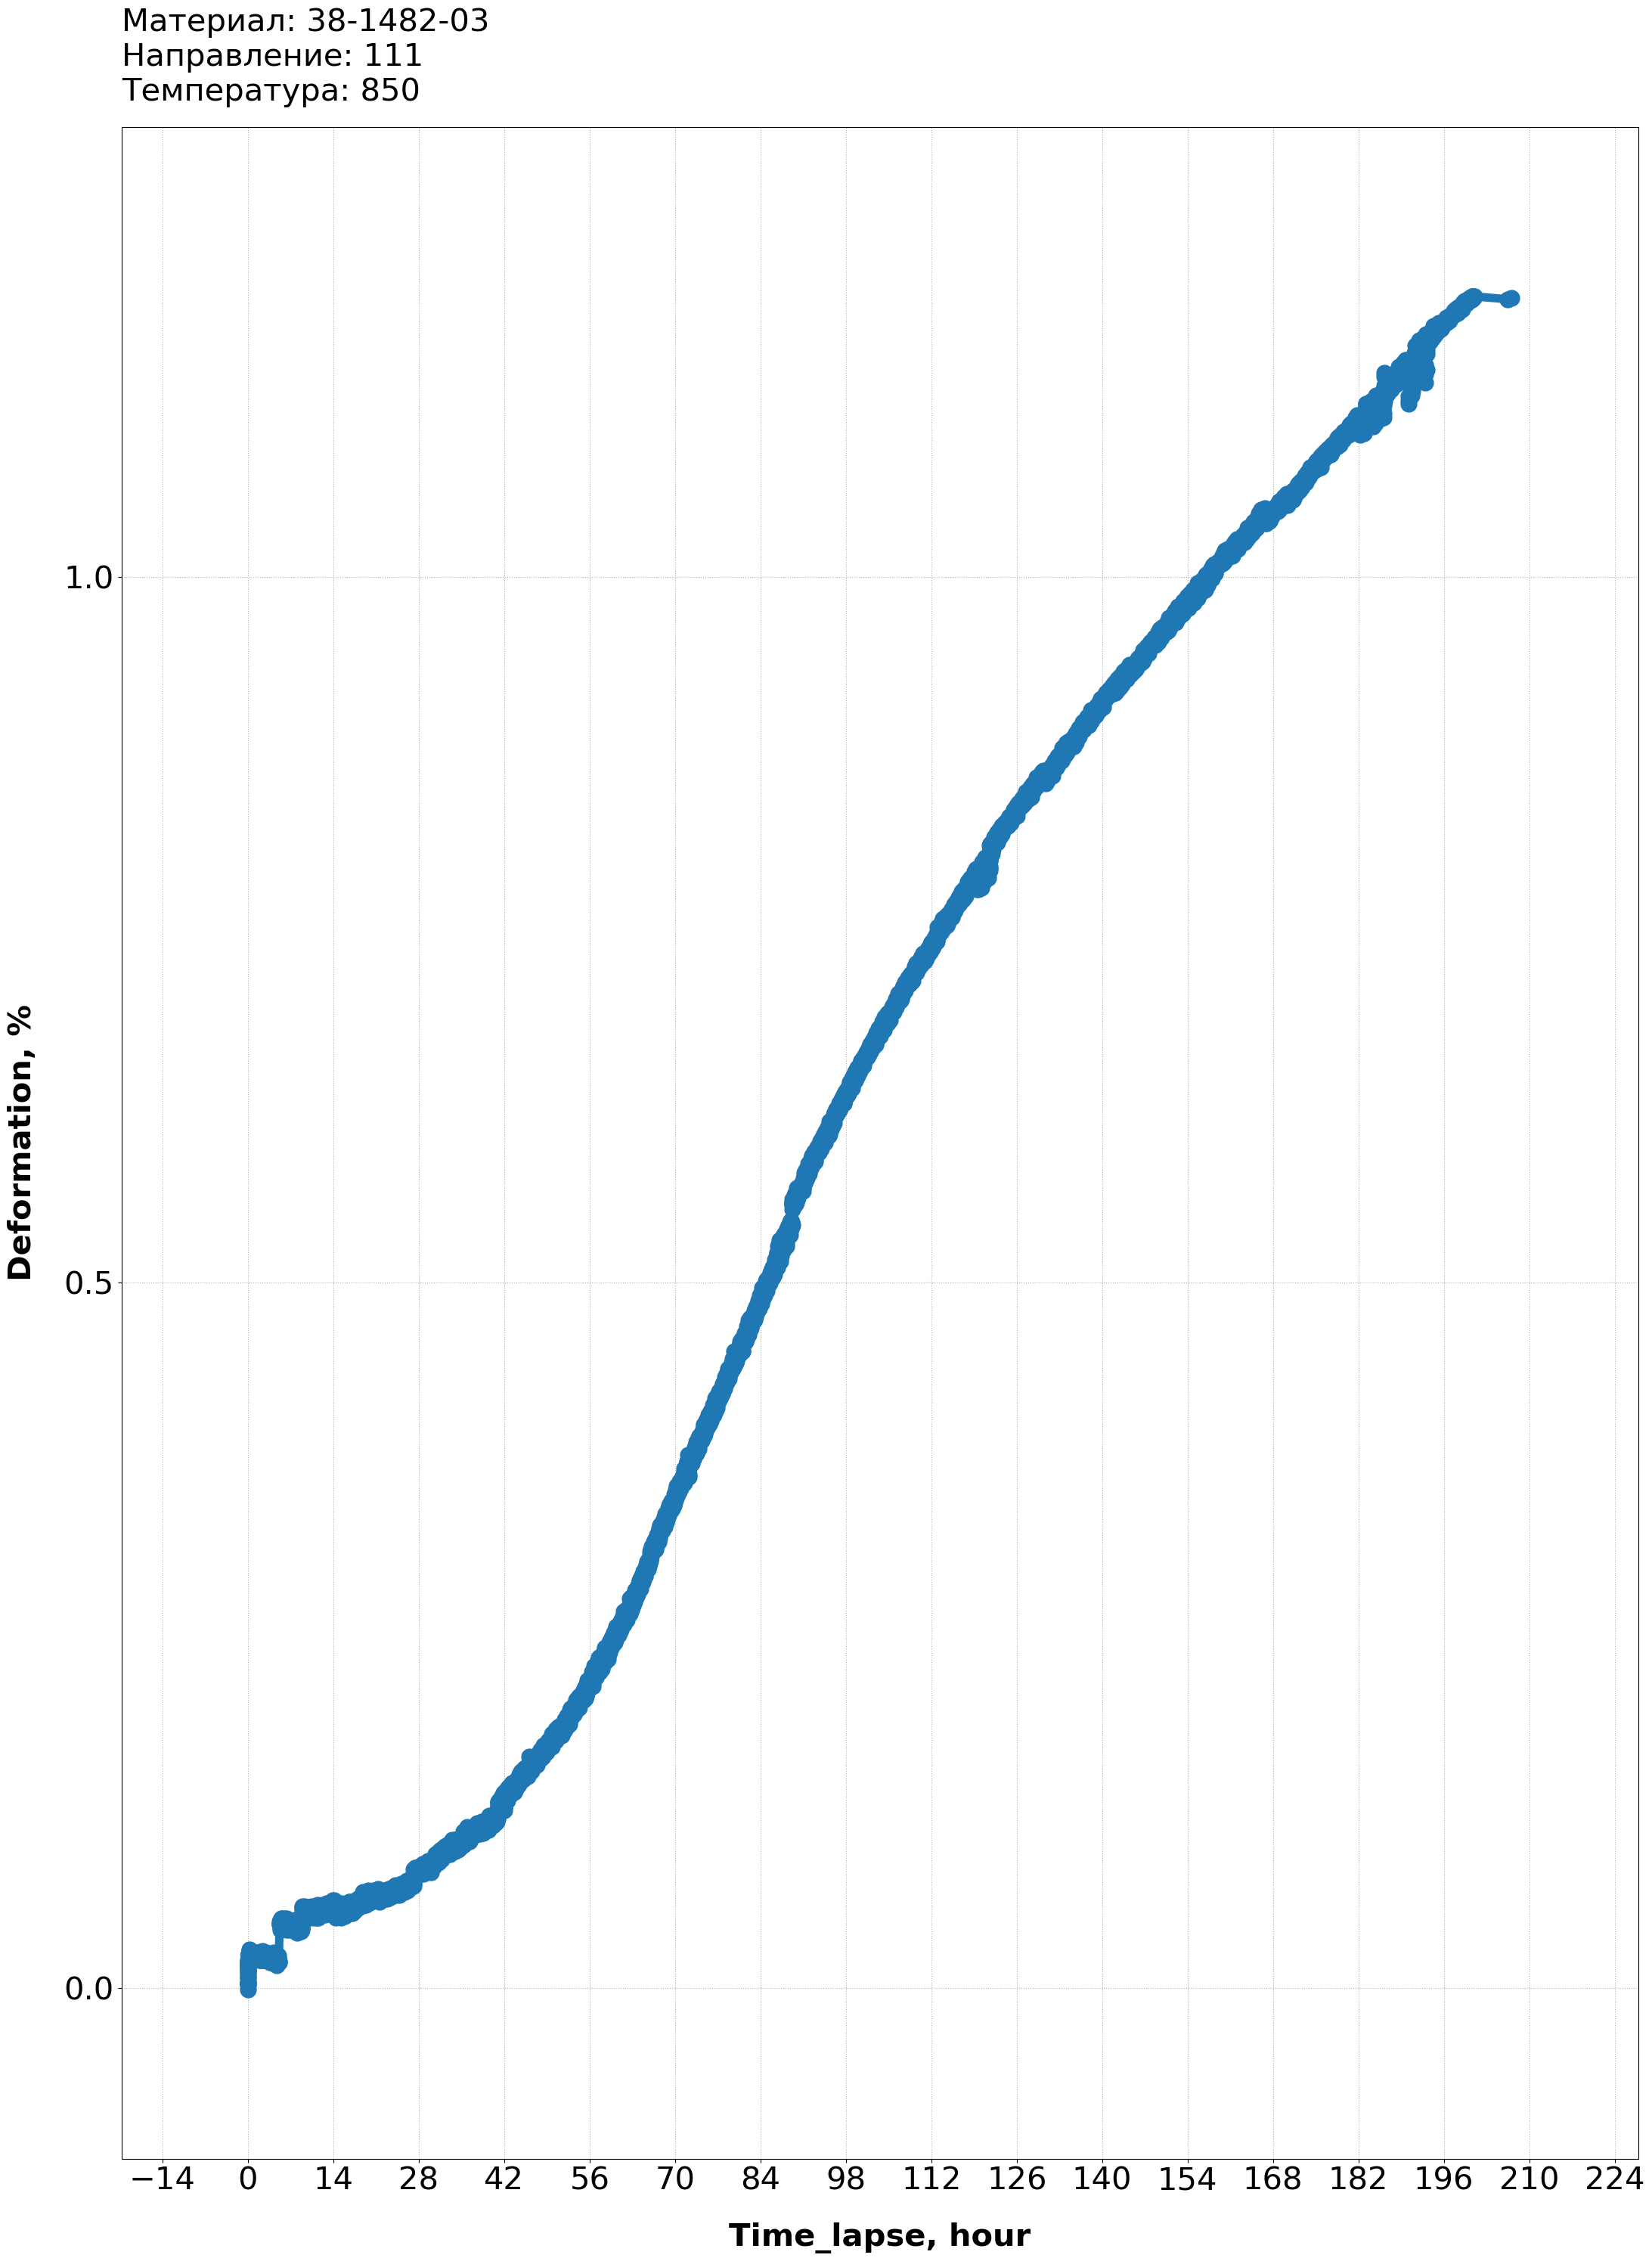

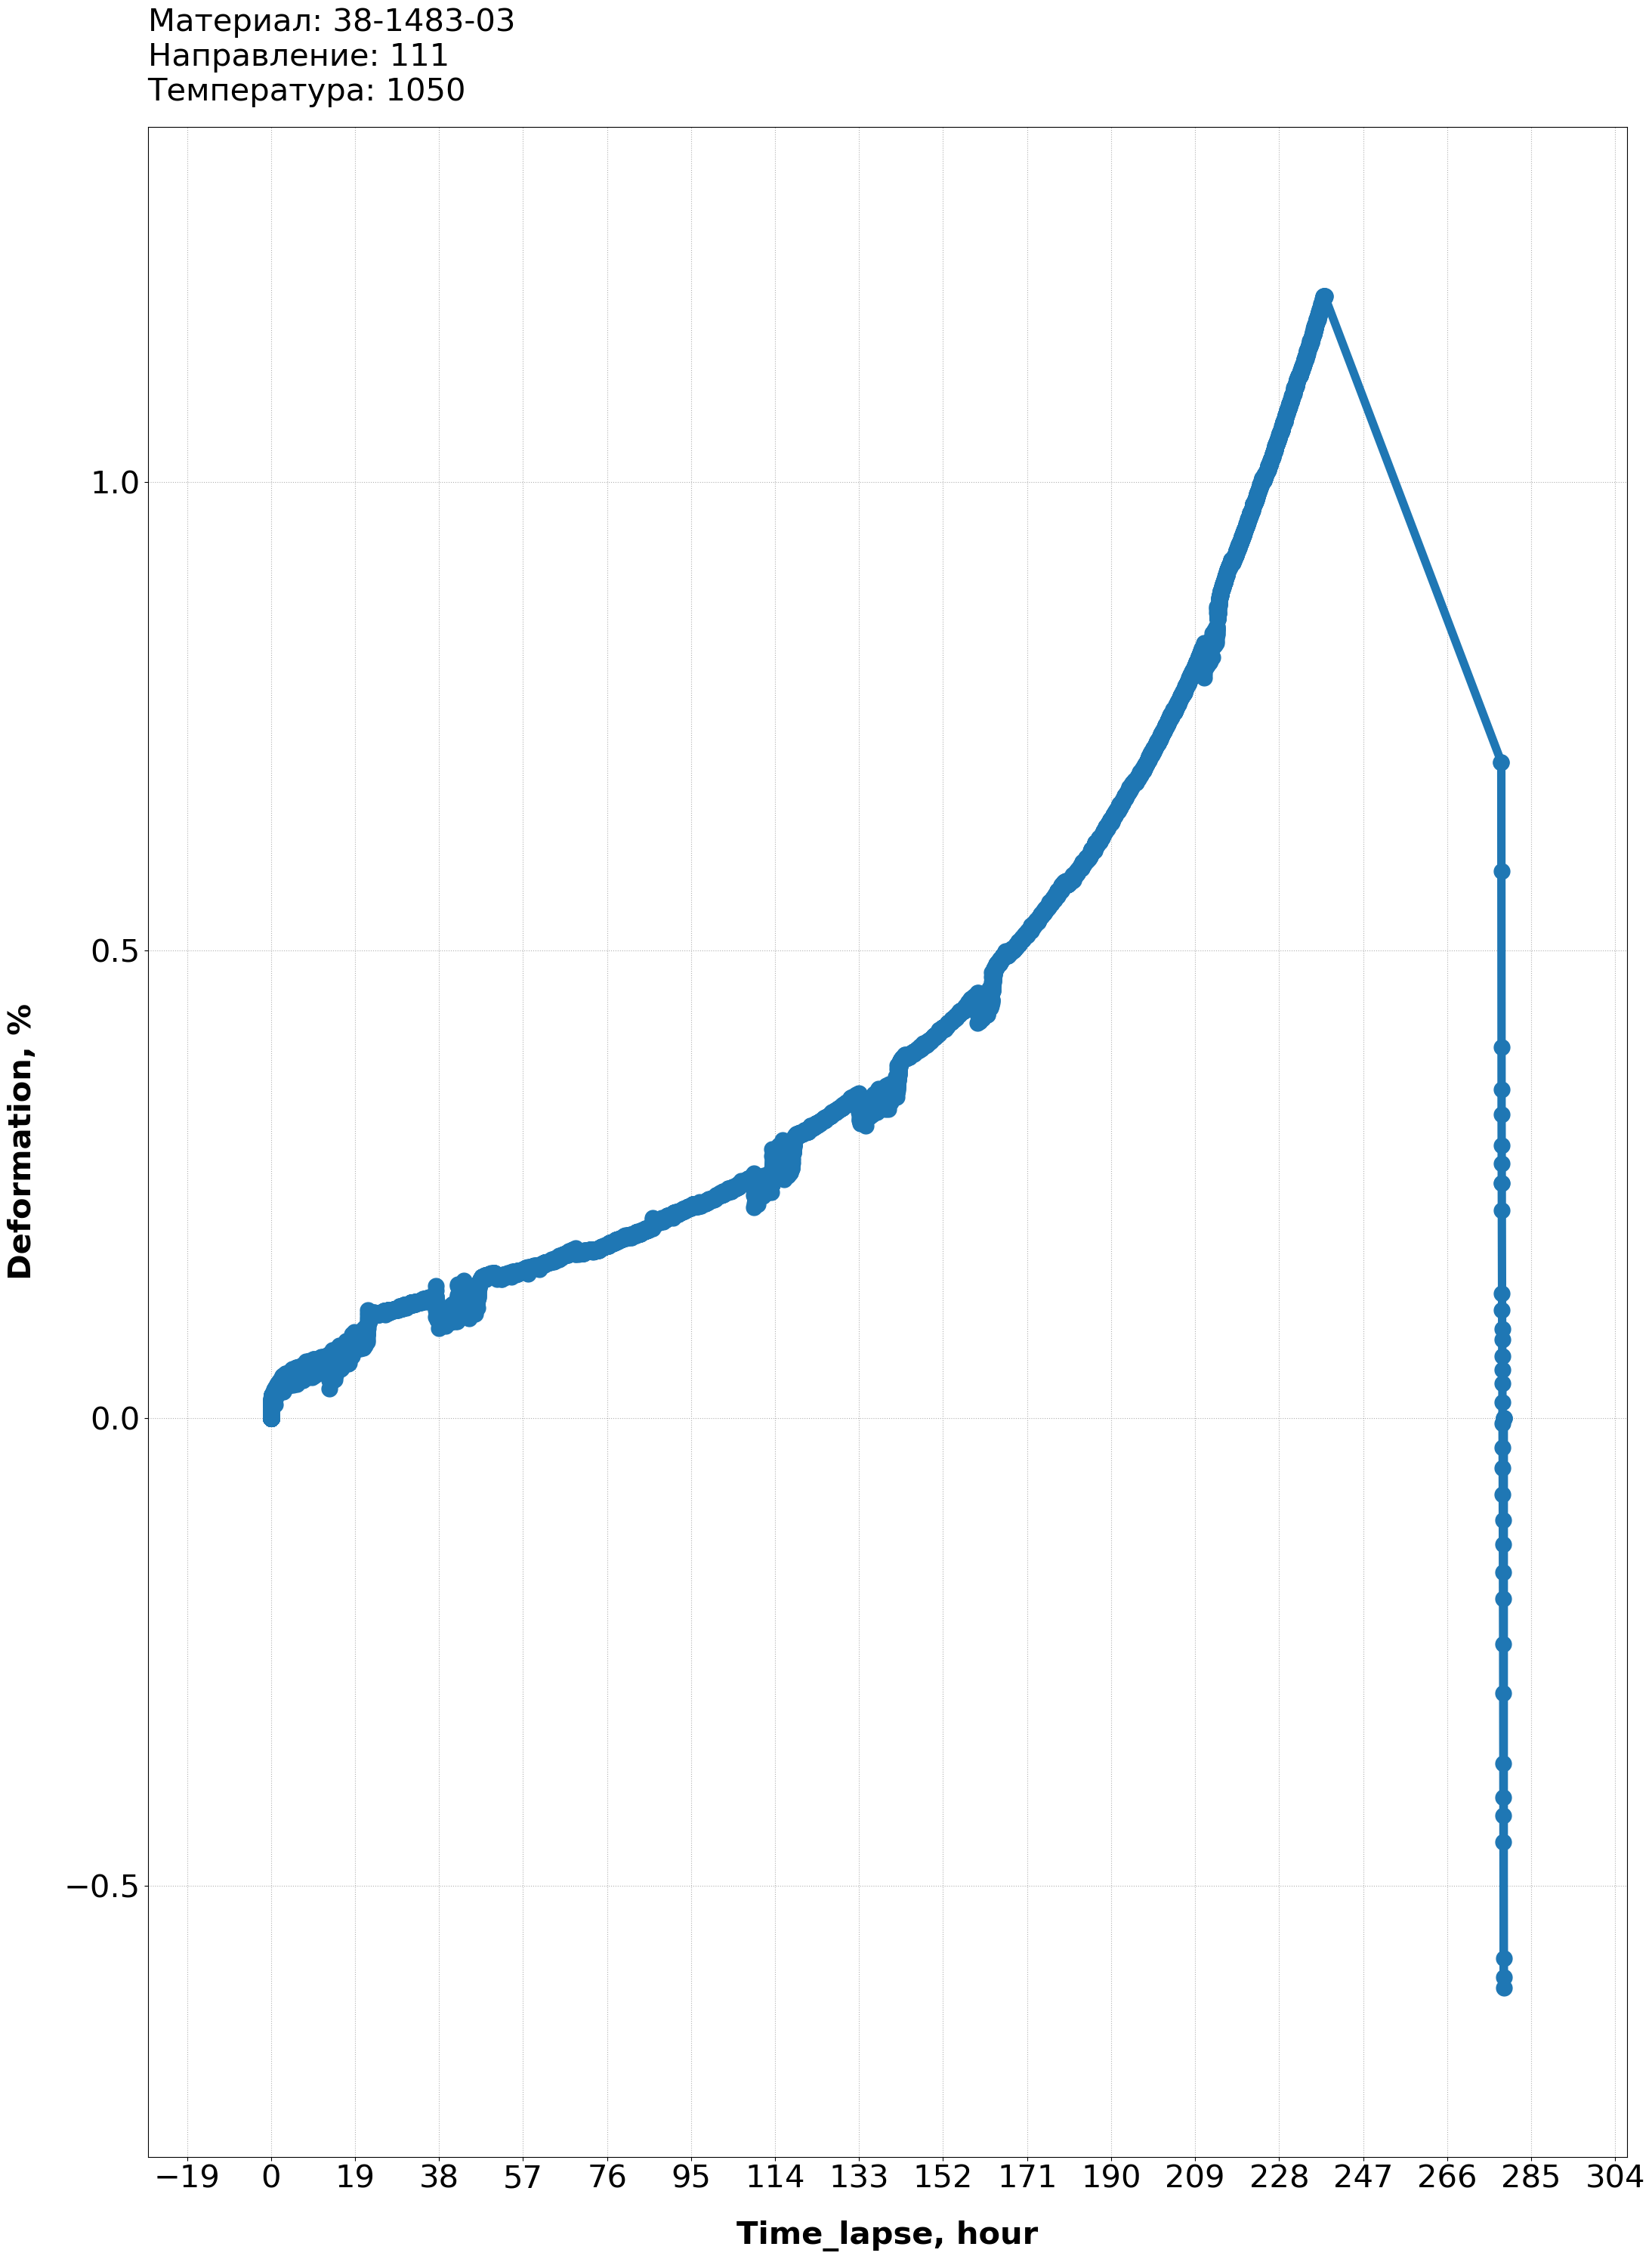

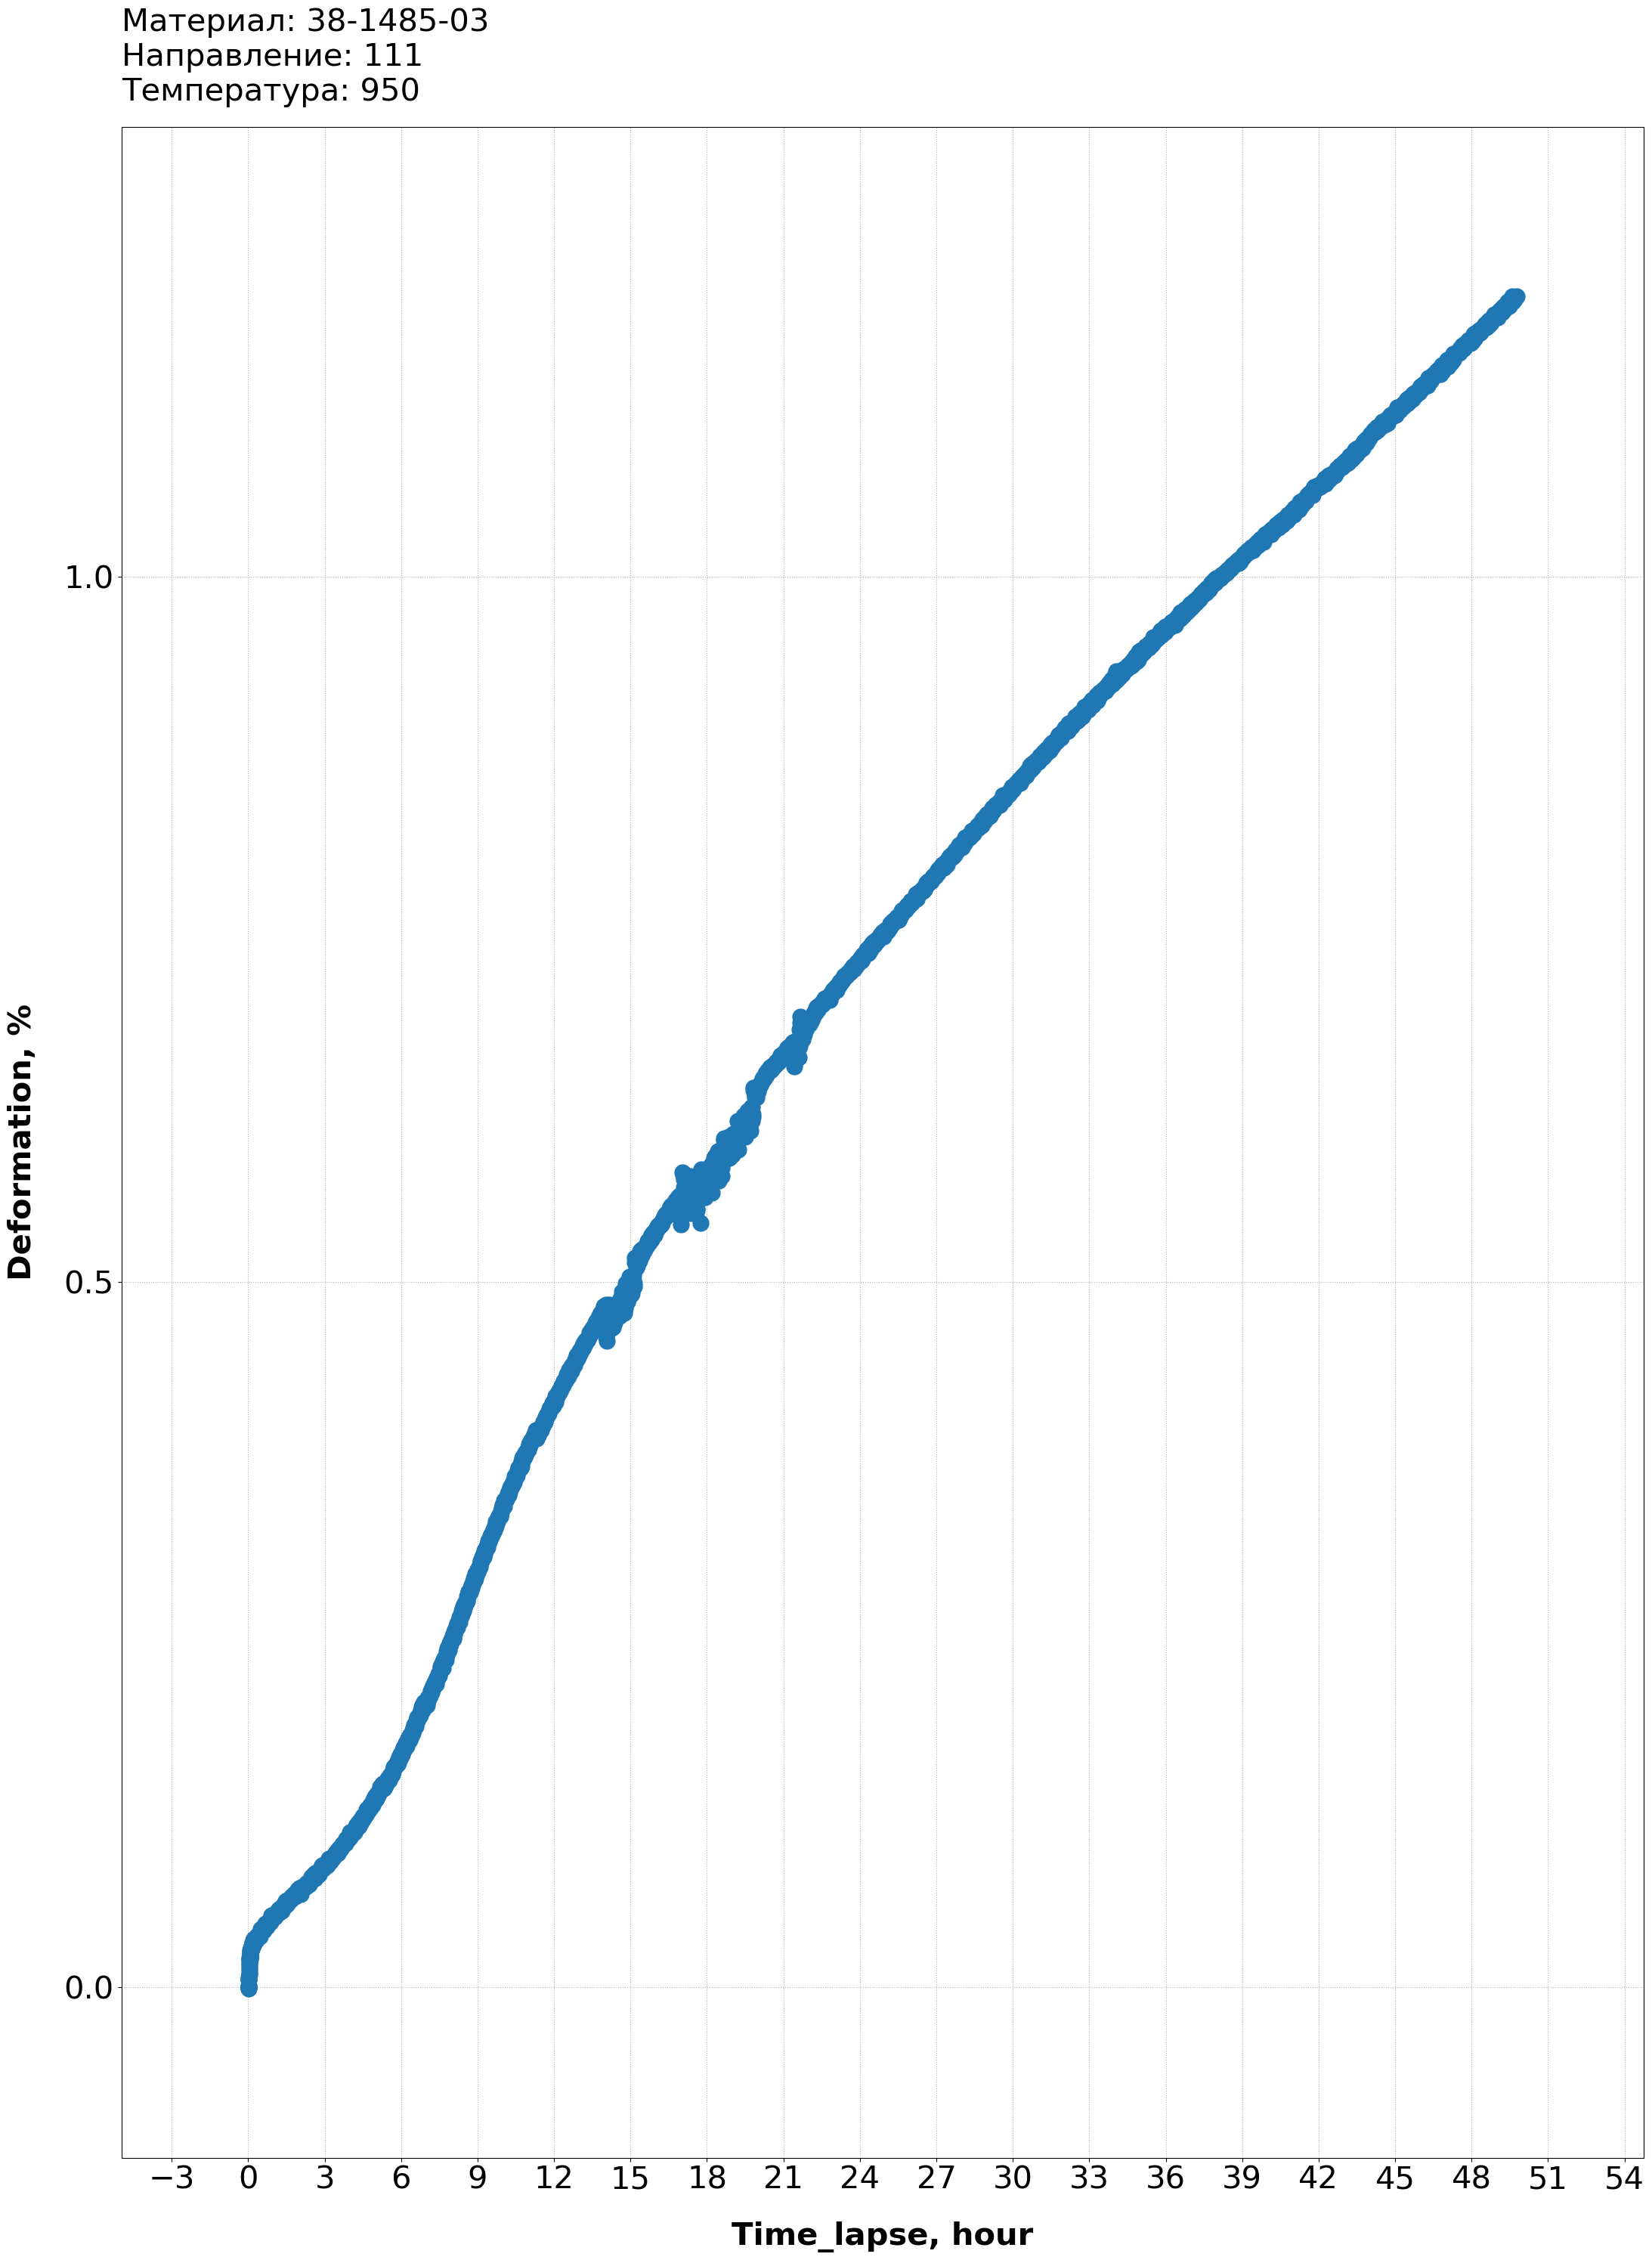

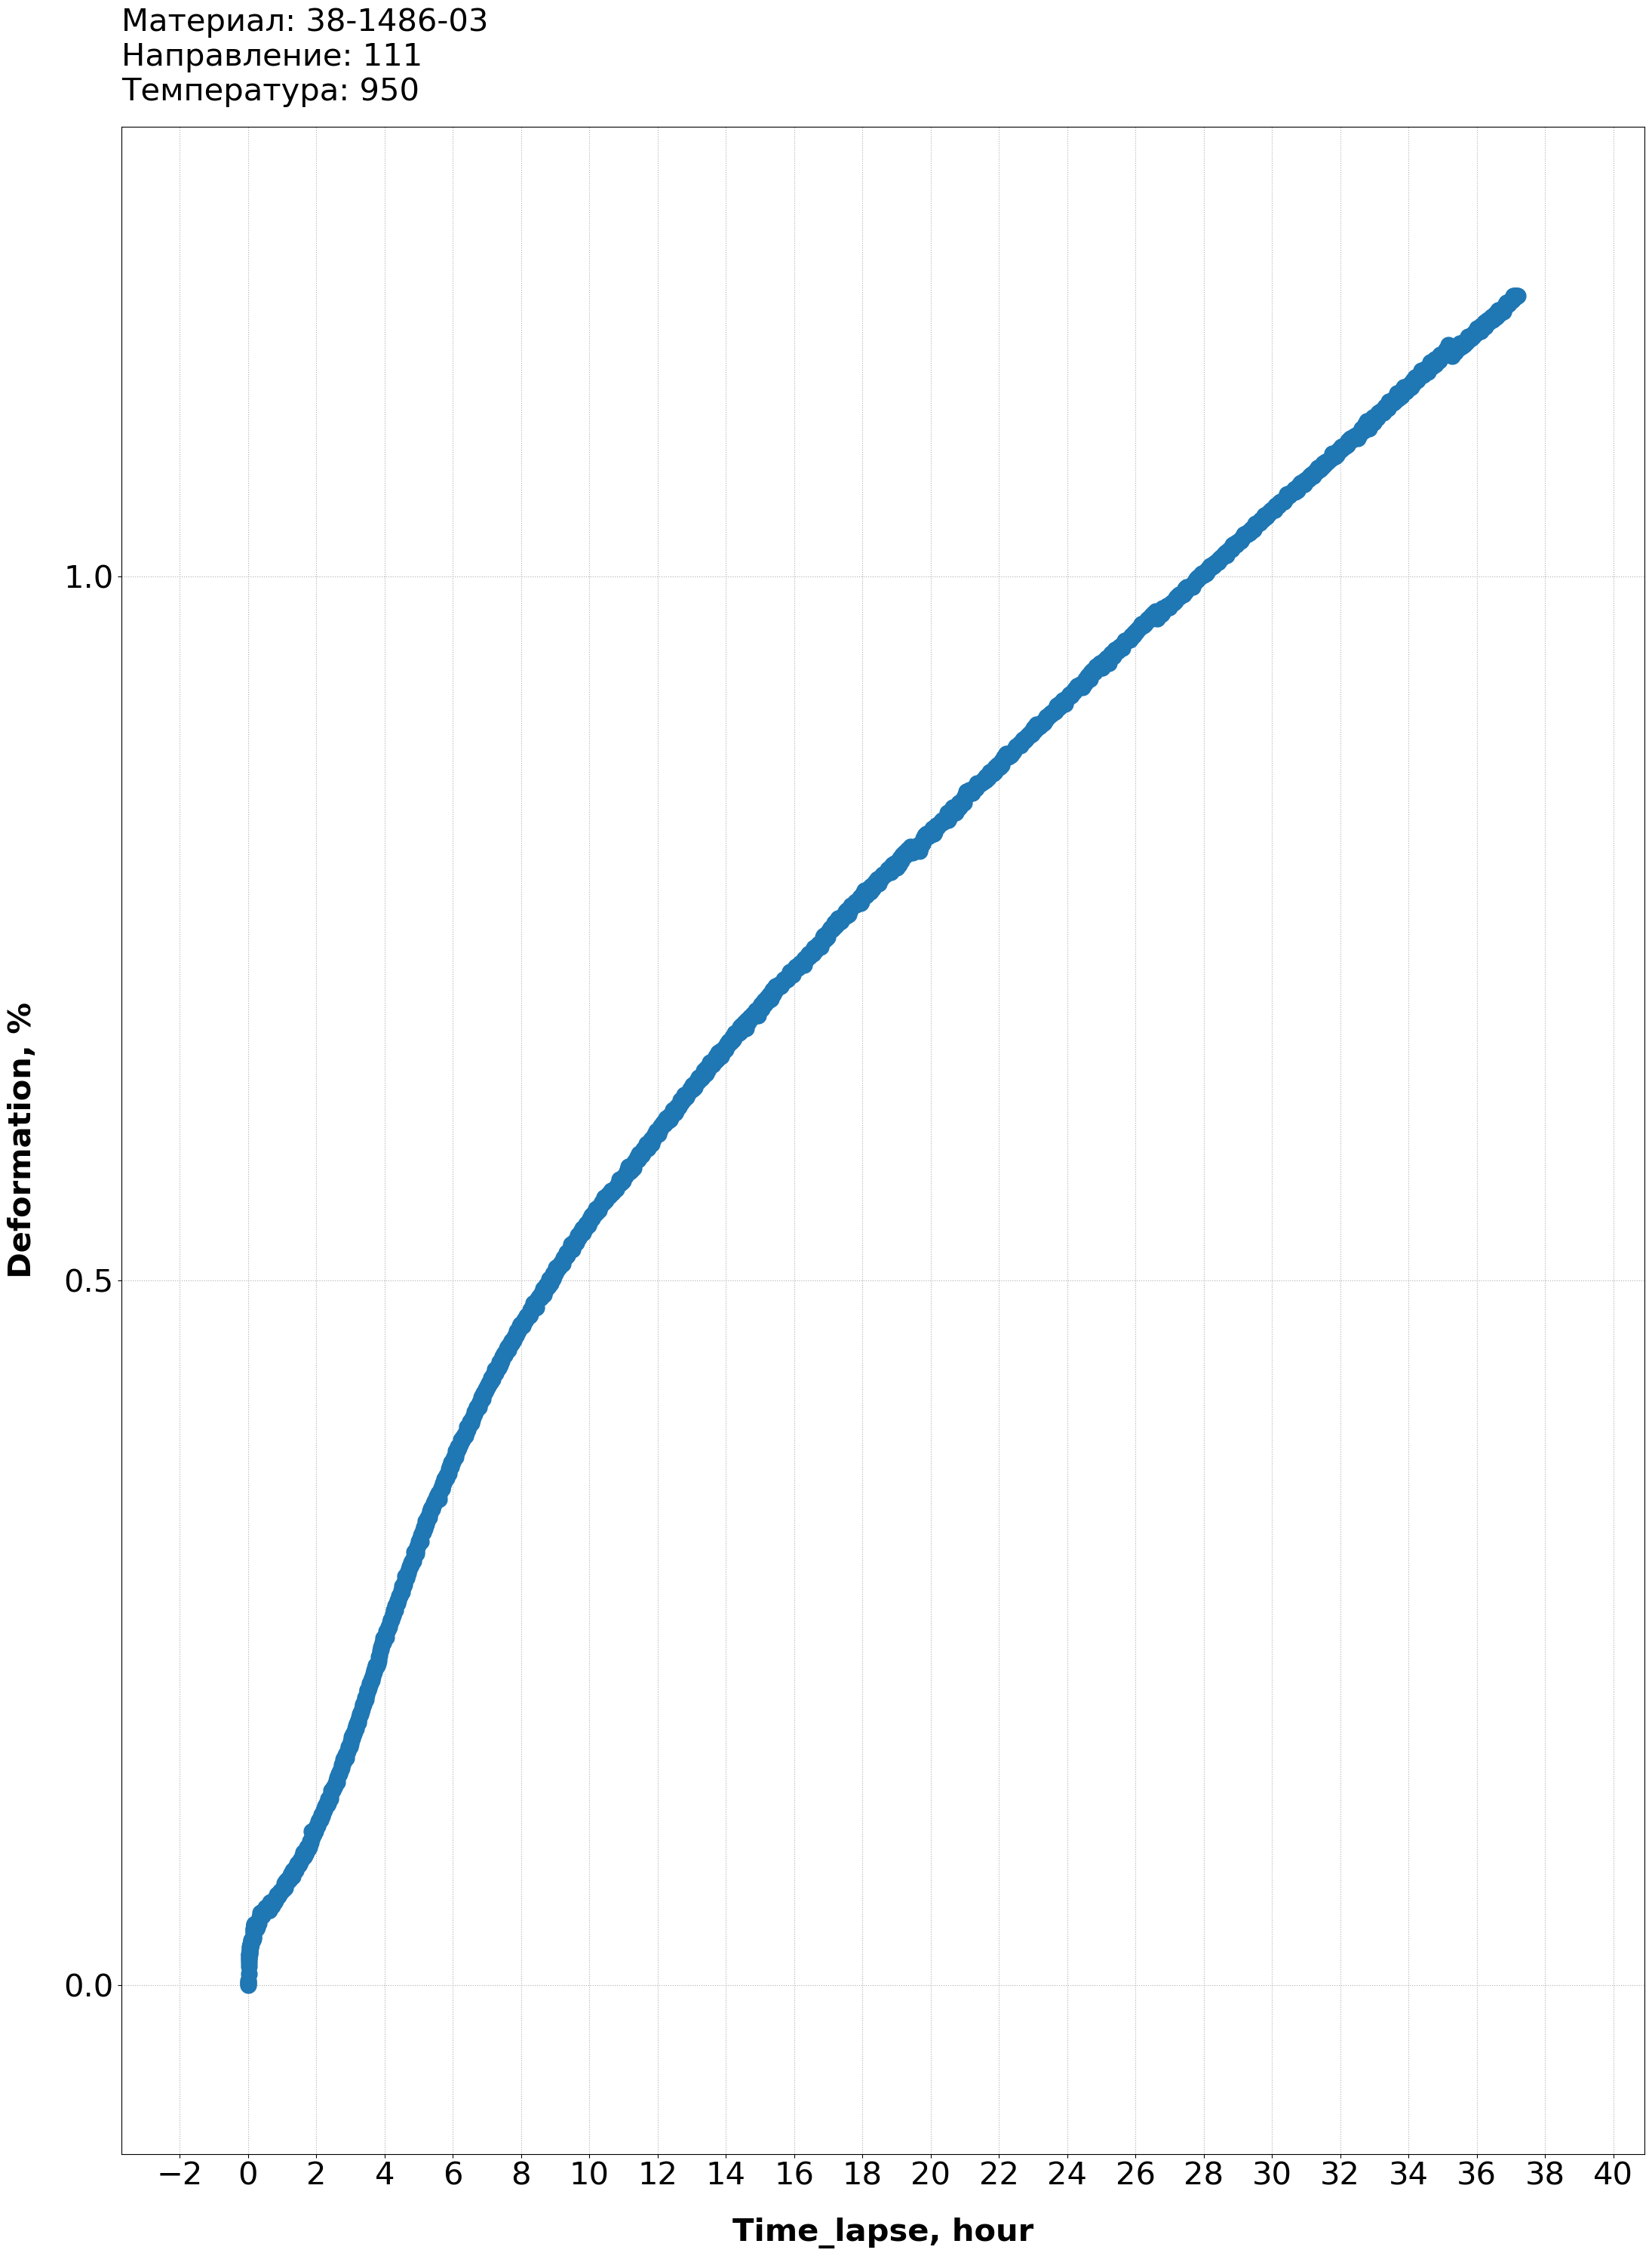

In [8]:
all_experiments_main()